In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 16,
    "font.size": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

from pathlib import Path

In [2]:
# -----------------------------
# Imports from your packages
# -----------------------------
from CuboidGravitationalField.potential import Gravitational_potential_cuboid
from CuboidGravitationalField.acceleration import (
    gravitational_gx_cuboid, gravitational_gy_cuboid, gravitational_gz_cuboid
)


In [3]:

from RectangleGravitationalField.rectangle_potential import gravitational_potential_rectangle
from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle, gravitational_gy_rectangle, gravitational_gz_rectangle
)

#### Test 01 Thin-cuboid limit versus rectangular surface mass

In [ ]:

# -----------------------------
# Test01 parameters
# -----------------------------
L = 1.0
B = 1.0
D = 1e-7          # half-thickness for cuboid
rho = 1.0         # volume density
G = 1.0

sigma = 2.0 * D * rho   # surface density equivalent

# -----------------------------
# Test points for rectangle (z=0 plane singularities included)
# -----------------------------
# Note: "vertex" and "edge" points on z=0 can produce ±inf in gx/gy for rectangle.
points = {
    "1) Vertex of rectangle (L,B,0)": ( L,  B, 0.0),
    "2) On edge (x=L, y=0, z=0)":     ( L,  0.0, 0.0),
    "3) Inside on plane (0,0,0)":     ( 0.0, 0.0, 0.0),
    "4) Exterior on plane (2,0,0)":   ( 2.0, 0.0, 0.0),
    "5) Extended edge line (L,2,0)":  ( L,  2.0, 0.0),
    "6) Above (0,0,+h)":              ( 0.0, 0.0, 1.0),
    "7) Below (0,0,-h)":              ( 0.0, 0.0,-1.0),
}

# -----------------------------
# Computation helpers
# -----------------------------
def cuboid_eval(x, y, z):
    V = Gravitational_potential_cuboid(x, y, z, L, B, D, rho, G)
    gx = gravitational_gx_cuboid(x, y, z, L, B, D, rho, G)
    gy = gravitational_gy_cuboid(x, y, z, L, B, D, rho, G)
    gz = gravitational_gz_cuboid(x, y, z, L, B, D, rho, G)
    return V, gx, gy, gz

def rect_eval(x, y, z):
    V = gravitational_potential_rectangle(x, y, z, L, B, sigma, G=G)
    gx = gravitational_gx_rectangle(x, y, z, L, B, sigma, G=G)
    gy = gravitational_gy_rectangle(x, y, z, L, B, sigma, G=G)
    gz = gravitational_gz_rectangle(x, y, z, L, B, sigma, G=G, eps=1e-15)
    return V, gx, gy, gz

def fmt(v):
    # nice formatting incl inf/nan
    if isinstance(v, (float, np.floating)):
        if np.isnan(v): return "nan"
        if np.isposinf(v): return "+inf"
        if np.isneginf(v): return "-inf"
        return f"{v:.16e}"
    return str(v)

# -----------------------------
# Run and write to txt
# -----------------------------
out_path = Path("Test01_ThinCuboid_vs_Rectangle.txt")

lines = []
lines.append("Test01: Thin cuboid vs rectangle\n")
lines.append(f"Parameters:\n  L=B={L}\n  D={D} (half-thickness)\n  rho={rho}\n  sigma=2*D*rho={sigma}\n  G={G}\n")
lines.append("-" * 78 + "\n")

for name, (x, y, z) in points.items():
    Vc, gxc, gyc, gzc = cuboid_eval(x, y, z)
    Vr, gxr, gyr, gzr = rect_eval(x, y, z)

    # Differences (Cuboid - Rectangle)
    dV  = Vc  - Vr
    dgx = gxc - gxr
    dgy = gyc - gyr
    dgz = gzc - gzr

    lines.append(f"{name}\n")
    lines.append(f"  Point (x,y,z) = ({x}, {y}, {z})\n\n")

    lines.append("  Cuboid (rho=1):\n")
    lines.append(f"    V  = {fmt(Vc)}\n")
    lines.append(f"    gx = {fmt(gxc)}\n")
    lines.append(f"    gy = {fmt(gyc)}\n")
    lines.append(f"    gz = {fmt(gzc)}\n\n")

    lines.append("  Rectangle (sigma=2D*rho):\n")
    lines.append(f"    V  = {fmt(Vr)}\n")
    lines.append(f"    gx = {fmt(gxr)}\n")
    lines.append(f"    gy = {fmt(gyr)}\n")
    lines.append(f"    gz = {fmt(gzr)}\n\n")

    lines.append("  Difference (Cuboid - Rectangle):\n")
    lines.append(f"    dV  = {fmt(dV)}\n")
    lines.append(f"    dgx = {fmt(dgx)}\n")
    lines.append(f"    dgy = {fmt(dgy)}\n")
    lines.append(f"    dgz = {fmt(dgz)}\n")
    lines.append("-" * 78 + "\n")

out_path.write_text("".join(lines))
print(f"Saved: {out_path.resolve()}")


Saved: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test01_ThinCuboid_vs_Rectangle.txt


#### Test 02

###### Manuscript version

Center (0,0,0)
Cuboid:    U=1.4101914560682438e-04, gx=-0.0000000000000000e+00, gy=-0.0000000000000000e+00, gz=-0.0000000000000000e+00
Rectangle: U=1.4101977392312674e-04, gx=-2.2204460492503133e-21, gy=-0.0000000000000000e+00, gz(0+)=-1.2566370614359163e-04, gz(0-)=1.2566370614359163e-04


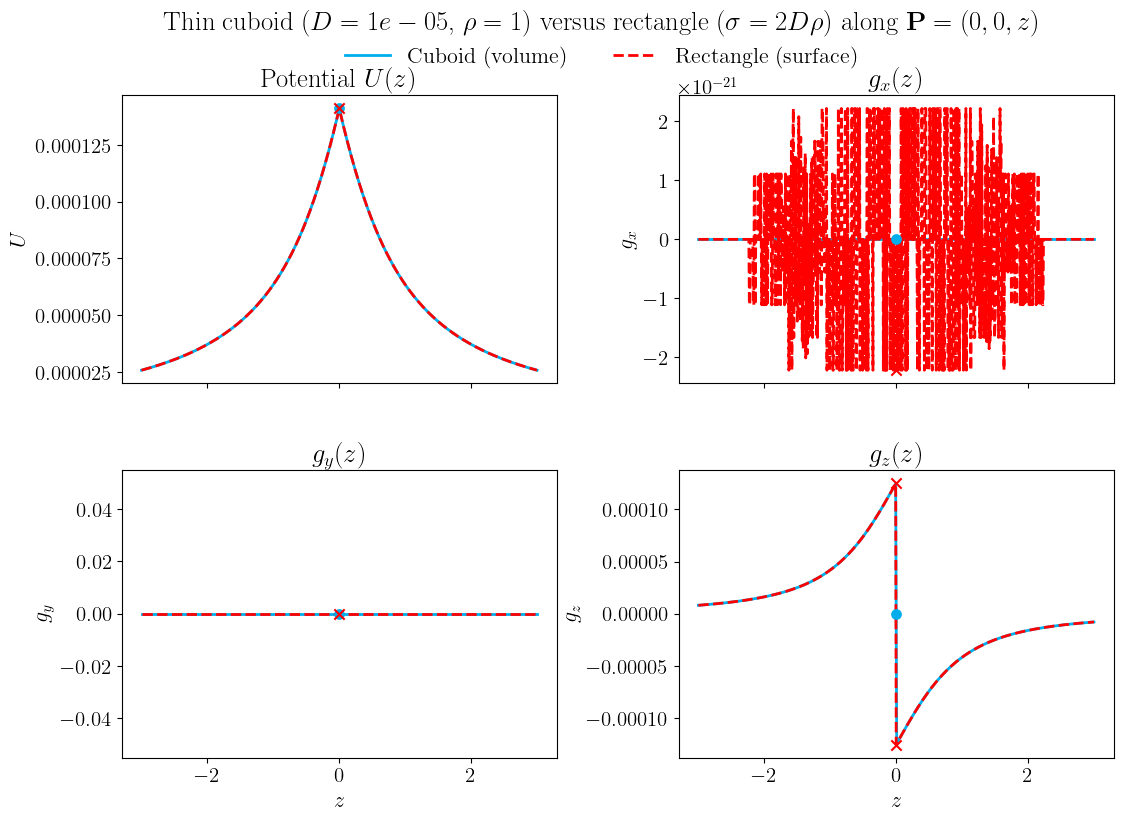

Saved figure: Validation_II_ThinCuboid_vs_Rectangle_Axis.pdf


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- parameters ----
L = 1.0
B = 1.0
D = 1e-5
rho = 1.0
G = 1.0
sigma = 2.0 * D * rho

eps_gz = 1e-15  # for rectangle gz one-sided evaluation

# ---- imports ----
from CuboidGravitationalField.potential import Gravitational_potential_cuboid
from CuboidGravitationalField.acceleration import (
    gravitational_gx_cuboid, gravitational_gy_cuboid, gravitational_gz_cuboid
)

from RectangleGravitationalField.rectangle_potential import gravitational_potential_rectangle
from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle, gravitational_gy_rectangle, gravitational_gz_rectangle
)

# ---- sampling along z through center ----
x0, y0 = 0.0, 0.0
zmax = 3.0 * max(L, B)
N = 801
z = np.linspace(-zmax, zmax, N)

# For rectangle gz: avoid exactly zero (jump ambiguity)
z_for_gz = z.copy()
z_for_gz[np.isclose(z_for_gz, 0.0)] = eps_gz

# ---- evaluate arrays ----
Vc  = np.empty_like(z); gxc = np.empty_like(z); gyc = np.empty_like(z); gzc = np.empty_like(z)
Vr  = np.empty_like(z); gxr = np.empty_like(z); gyr = np.empty_like(z); gzr = np.empty_like(z)

for i, zi in enumerate(z):
    # Cuboid
    Vc[i]  = Gravitational_potential_cuboid(x0, y0, zi, L, B, D, rho, G)
    gxc[i] = gravitational_gx_cuboid(x0, y0, zi, L, B, D, rho, G)
    gyc[i] = gravitational_gy_cuboid(x0, y0, zi, L, B, D, rho, G)
    gzc[i] = gravitational_gz_cuboid(x0, y0, zi, L, B, D, rho, G)

    # Rectangle
    Vr[i]  = gravitational_potential_rectangle(x0, y0, zi, L, B, sigma, G=G)
    gxr[i] = gravitational_gx_rectangle(x0, y0, zi, L, B, sigma, G=G)
    gyr[i] = gravitational_gy_rectangle(x0, y0, zi, L, B, sigma, G=G)
    gzr[i] = gravitational_gz_rectangle(x0, y0, z_for_gz[i], L, B, sigma, G=G, eps=eps_gz)

# ---- center values ----
V0c  = Gravitational_potential_cuboid(x0, y0, 0.0, L, B, D, rho, G)
gx0c = gravitational_gx_cuboid(x0, y0, 0.0, L, B, D, rho, G)
gy0c = gravitational_gy_cuboid(x0, y0, 0.0, L, B, D, rho, G)
gz0c = gravitational_gz_cuboid(x0, y0, 0.0, L, B, D, rho, G)

V0r  = gravitational_potential_rectangle(x0, y0, 0.0, L, B, sigma, G=G)
gx0r = gravitational_gx_rectangle(x0, y0, 0.0, L, B, sigma, G=G)
gy0r = gravitational_gy_rectangle(x0, y0, 0.0, L, B, sigma, G=G)
gz0r_p = gravitational_gz_rectangle(x0, y0, +eps_gz, L, B, sigma, G=G, eps=eps_gz)
gz0r_m = gravitational_gz_rectangle(x0, y0, -eps_gz, L, B, sigma, G=G, eps=eps_gz)

print("Center (0,0,0)")
print(f"Cuboid:    U={V0c:.16e}, gx={gx0c:.16e}, gy={gy0c:.16e}, gz={gz0c:.16e}")
print(f"Rectangle: U={V0r:.16e}, gx={gx0r:.16e}, gy={gy0r:.16e}, gz(0+)={gz0r_p:.16e}, gz(0-)={gz0r_m:.16e}")

# ---- colors ----
lb = np.array([0, 174, 235]) / 255.0   # cuboid
rc = "red"                             # rectangle

# ---- plot ----
fig, axs = plt.subplots(2, 2, figsize=(12.8, 8.6), sharex=True)

fig.suptitle(
    rf"Thin cuboid ($D={D:g}$, $\rho={rho:g}$) versus rectangle ($\sigma=2D\rho$) along $\mathbf{{P}}=(0,0,z)$",
    y=0.98
)

# Potential
axs[0, 0].plot(z, Vc, color=lb, linewidth=2)
axs[0, 0].plot(z, Vr, color=rc, linestyle="--", linewidth=2)
axs[0, 0].scatter([0.0], [V0c], color=lb, s=45, zorder=5)
axs[0, 0].scatter([0.0], [V0r], color=rc, s=55, marker="x", zorder=6)
axs[0, 0].set_title(r"Potential $U(z)$")
axs[0, 0].set_ylabel(r"$U$")

# gx
axs[0, 1].plot(z, gxc, color=lb, linewidth=2)
axs[0, 1].plot(z, gxr, color=rc, linestyle="--", linewidth=2)
axs[0, 1].scatter([0.0], [gx0c], color=lb, s=45, zorder=5)
axs[0, 1].scatter([0.0], [gx0r], color=rc, s=55, marker="x", zorder=6)
axs[0, 1].set_title(r"$g_x(z)$")
axs[0, 1].set_ylabel(r"$g_x$")

# gy
axs[1, 0].plot(z, gyc, color=lb, linewidth=2)
axs[1, 0].plot(z, gyr, color=rc, linestyle="--", linewidth=2)
axs[1, 0].scatter([0.0], [gy0c], color=lb, s=45, zorder=5)
axs[1, 0].scatter([0.0], [gy0r], color=rc, s=55, marker="x", zorder=6)
axs[1, 0].set_title(r"$g_y(z)$")
axs[1, 0].set_xlabel(r"$z$")
axs[1, 0].set_ylabel(r"$g_y$")

# gz
axs[1, 1].plot(z, gzc, color=lb, linewidth=2)
axs[1, 1].plot(z, gzr, color=rc, linestyle="--", linewidth=2)
axs[1, 1].scatter([0.0], [gz0c], color=lb, s=45, zorder=5)
axs[1, 1].scatter([0.0], [gz0r_p], color=rc, s=55, marker="x", zorder=6)
axs[1, 1].scatter([0.0], [gz0r_m], color=rc, s=55, marker="x", zorder=6)
axs[1, 1].set_title(r"$g_z(z)$")
axs[1, 1].set_xlabel(r"$z$")
axs[1, 1].set_ylabel(r"$g_z$")

# ---- Global legend (ONLY TWO entries), no box, moved up ----
legend_handles = [
    Line2D([0], [0], color=lb, linewidth=2, label="Cuboid (volume)"),
    Line2D([0], [0], color=rc, linestyle="--", linewidth=2, label="Rectangle (surface)"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    ncol=2,
    frameon=False
)

# spacing
fig.subplots_adjust(top=0.88, wspace=0.28, hspace=0.30)

# ---- Save as PDF ----
out_pdf = "Validation_II_ThinCuboid_vs_Rectangle_Axis.pdf"
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved figure: {out_pdf}")


#### Test 03: Gravitational Acceleration

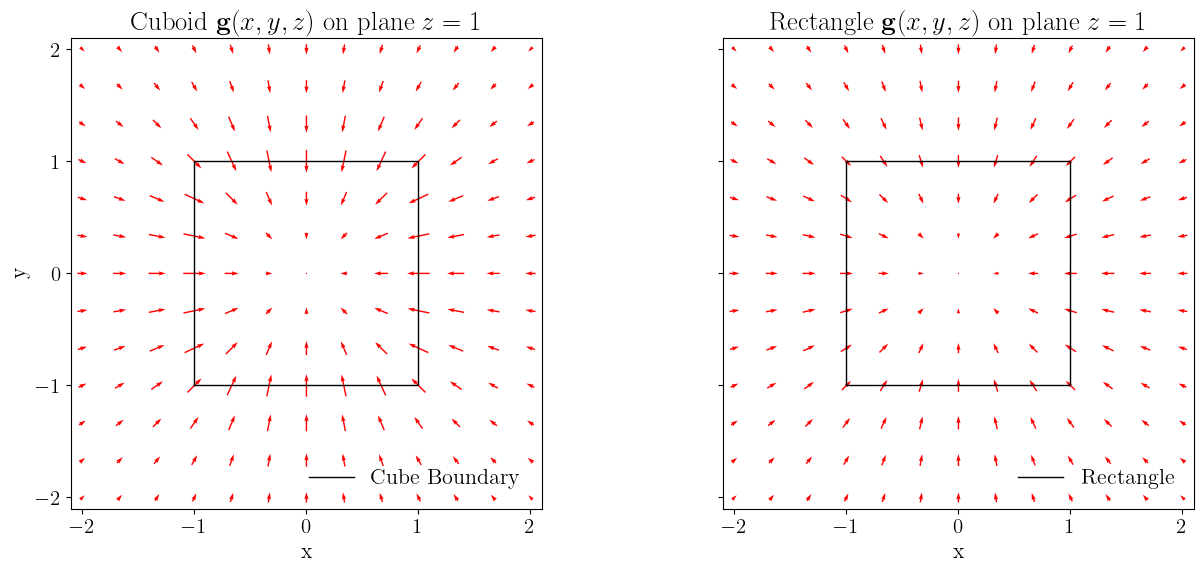

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Imports: adjust to your actual package paths
# -----------------------------
from CuboidGravitationalField.acceleration import (
    gravitational_gx_cuboid,
    gravitational_gy_cuboid,
    gravitational_gz_cuboid
)
from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
    gravitational_gz_rectangle
)

# ---------------------------------------------------------
# PARAMETERS ( Cuboid)
# ---------------------------------------------------------
G = 1.0
rho = 1.0

X_0, Y_0, Z_0 = 0.0, 0.0, 0.0
L_full, B_full, D_full = 2.0, 2.0, 2.0   # full lengths

# Semi-dimensions expected by your functions
a = L_full / 2.0
b = B_full / 2.0
c = D_full / 2.0

# Rectangle equivalent surface density (lamina in z=0)
sigma = 2.0 * c * rho

# ---------------------------------------------------------
# GRID on TOP FACE plane of cube: z = +c
# ---------------------------------------------------------
x_vals = np.linspace(-2, 2, 13)
y_vals = np.linspace(-2, 2, 13)
X, Y = np.meshgrid(x_vals, y_vals)

zq = +c  # top face plane (z=+1 for this cube)

# Allocate arrays
U_cub = np.zeros_like(X); V_cub = np.zeros_like(Y)
U_rec = np.zeros_like(X); V_rec = np.zeros_like(Y)

# (Optional) store gz too if you want later
W_cub = np.zeros_like(X)
W_rec = np.zeros_like(X)

# ---------------------------------------------------------
# COMPUTE acceleration field on grid
# ---------------------------------------------------------
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        xq, yq = X[i, j], Y[i, j]

        # ---- Cuboid ----
        gx = gravitational_gx_cuboid(xq, yq, zq, a, b, c, rho, G)
        gy = gravitational_gy_cuboid(xq, yq, zq, a, b, c, rho, G)
        gz = gravitational_gz_cuboid(xq, yq, zq, a, b, c, rho, G)

        U_cub[i, j] = gx
        V_cub[i, j] = gy
        W_cub[i, j] = gz

        # ---- Rectangle (lamina in z=0), evaluated at same (x,y,zq) ----
        gxR = gravitational_gx_rectangle(xq, yq, zq, a, b, sigma, G=G)
        gyR = gravitational_gy_rectangle(xq, yq, zq, a, b, sigma, G=G)
        gzR = gravitational_gz_rectangle(xq, yq, zq, a, b, sigma, G=G, eps=0.0)

        U_rec[i, j] = gxR
        V_rec[i, j] = gyR
        W_rec[i, j] = gzR

# ---------------------------------------------------------
# PLOT: subplots (Cuboid vs Rectangle)
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# same quiver scale for both so comparisons are meaningful
quiver_scale = 65
qkw = dict(scale=quiver_scale, pivot='middle', width=0.003)

# Cuboid boundary (projection in x-y)
x_min, x_max = X_0 - a, X_0 + a
y_min, y_max = Y_0 - b, Y_0 + b

# --- Left: Cuboid ---
axs[0].quiver(X, Y, U_cub, V_cub, color='red', **qkw)
axs[0].plot([x_min, x_max, x_max, x_min, x_min],
            [y_min, y_min, y_max, y_max, y_min],
            color='black', linewidth=1, label='Cube Boundary')

axs[0].set_title(rf"Cuboid $\mathbf{{g}}(x,y,z)$ on plane $z={zq:g}$")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].legend(loc='lower right', frameon=False)

# --- Right: Rectangle ---
axs[1].quiver(X, Y, U_rec, V_rec, color='red', **qkw)
axs[1].plot([x_min, x_max, x_max, x_min, x_min],
            [y_min, y_min, y_max, y_max, y_min],
            color='black', linewidth=1, label='Rectangle')

axs[1].set_title(rf"Rectangle $\mathbf{{g}}(x,y,z)$ on plane $z={zq:g}$")
axs[1].set_xlabel('x')
axs[1].legend(loc='lower right', frameon=False)

# Common formatting
for ax in axs:
    ax.set_xlim([-2.1, 2.1])
    ax.set_ylim([-2.1, 2.1])
    ax.set_xticks(np.arange(-2, 3, 1))
    ax.set_yticks(np.arange(-2, 3, 1))
    ax.set_aspect('equal')
    ax.grid(False)

plt.tight_layout()
plt.savefig("Test03_Quiver_TopFace_Cuboid_vs_Rectangle.png", dpi=300, bbox_inches='tight')
plt.show()


#### Test 4

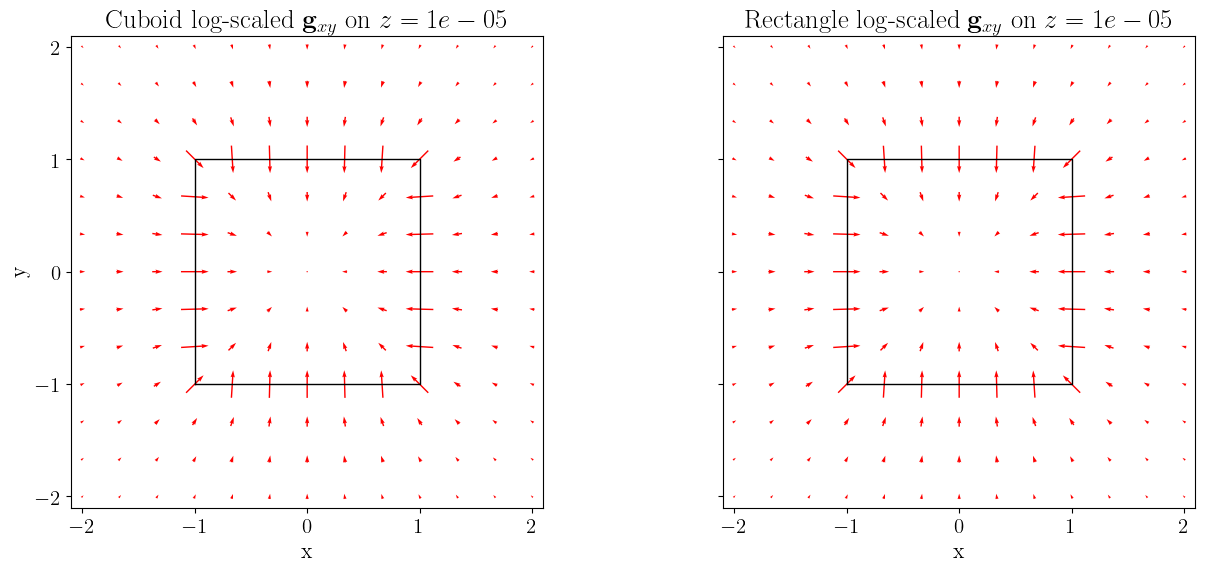

TEST 4 SUMMARY
G=1.0, rho=1.0, L_full=2.0, B_full=2.0, D_full=2e-05
a=1.0, b=1.0, c=1e-05, sigma=2*c*rho=2e-05, plane z=1e-05
------------------------------------------------------------
max |g_xy| cuboid     = 4.812685e-04
max |g_xy| rectangle  = 4.689944e-04
max |Δg_xy|           = 1.227411e-05
------------------------------------------------------------
Log reference scales used (median magnitudes):
m0_cub=2.981878e-05, m0_rec=2.981878e-05, m0_diff=1.704820e-15
Saved figure: Test04_LogScaledQuiver_Cuboid_Rectangle_Difference.png


In [6]:
# ============================================================
# TEST 4 
# Quiver field on plane z = +c (near the lamina / top face plane),
# comparing Cuboid vs Rectangle, plus Difference field.
# Uses LOG-SCALED arrow lengths so edge blow-up doesn't dominate.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Imports
# -----------------------------
from CuboidGravitationalField.acceleration import (
    gravitational_gx_cuboid,
    gravitational_gy_cuboid,
    gravitational_gz_cuboid,
)

from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
    gravitational_gz_rectangle,
)

# ---------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------
G = 1.0
rho = 1.0                 # you said you're using 1000
L_full, B_full, D_full = 2.0, 2.0, 2e-5  # full dimensions; thin slab thickness in z

# Semi-dimensions expected by your cuboid/rectangle functions
a = L_full / 2.0
b = B_full / 2.0
c = D_full / 2.0

# Rectangle equivalent surface density (lamina in z=0 plane)
sigma = 2.0 * c * rho

# Evaluation plane: close to z=0 (top face plane for thin slab)
zq = +c

# ---------------------------------------------------------
# GRID (x-y)
# ---------------------------------------------------------
x_vals = np.linspace(-2, 2, 13)
y_vals = np.linspace(-2, 2, 13)
X, Y = np.meshgrid(x_vals, y_vals)

U_cub = np.zeros_like(X); V_cub = np.zeros_like(X)
U_rec = np.zeros_like(X); V_rec = np.zeros_like(X)

# (optional store gz too)
W_cub = np.zeros_like(X)
W_rec = np.zeros_like(X)

# ---------------------------------------------------------
# COMPUTE FIELDS
# ---------------------------------------------------------
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        xq, yq = X[i, j], Y[i, j]

        # Cuboid
        gx = gravitational_gx_cuboid(xq, yq, zq, a, b, c, rho, G)
        gy = gravitational_gy_cuboid(xq, yq, zq, a, b, c, rho, G)
        gz = gravitational_gz_cuboid(xq, yq, zq, a, b, c, rho, G)

        U_cub[i, j] = gx
        V_cub[i, j] = gy
        W_cub[i, j] = gz

        # Rectangle (lamina at z=0)
        gxR = gravitational_gx_rectangle(xq, yq, zq, a, b, sigma, G=G)
        gyR = gravitational_gy_rectangle(xq, yq, zq, a, b, sigma, G=G)
        gzR = gravitational_gz_rectangle(xq, yq, zq, a, b, sigma, G=G, eps=1e-15)

        U_rec[i, j] = gxR
        V_rec[i, j] = gyR
        W_rec[i, j] = gzR

# Difference field (Cuboid - Rectangle)
U_diff = U_cub - U_rec
V_diff = V_cub - V_rec

# ---------------------------------------------------------
# LOG-SCALED QUIVER
# ---------------------------------------------------------
def logscale_quiver(U, V, m0=None, eps=1e-300):
    """
    Log-scale vector magnitudes for quiver plotting.
    Directions preserved. Guarantees: mag -> 0  =>  mag_log -> 0.
    """
    mag = np.sqrt(U**2 + V**2)

    # Choose reference scale from nonzero magnitudes
    mag_nz = mag[mag > 0]
    if m0 is None:
        m0 = np.median(mag_nz) if mag_nz.size else 1.0
    if not np.isfinite(m0) or m0 <= 0:
        m0 = 1.0

    # Log mapping that is 0 at mag=0
    mag_log = np.log10(1.0 + mag / m0)

    # Avoid division by zero
    scale = np.where(mag > 0, mag_log / (mag + eps), 0.0)

    Uq = U * scale
    Vq = V * scale
    return Uq, Vq, m0


U_cub_log, V_cub_log, m0_cub = logscale_quiver(U_cub, V_cub, m0=None)
U_rec_log, V_rec_log, m0_rec = logscale_quiver(U_rec, V_rec, m0=None)
U_diff_log, V_diff_log, m0_dif = logscale_quiver(U_diff, V_diff, m0=None)

# ---------------------------------------------------------
# PLOT (3 subplots)
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Manual quiver display scale for the *log-scaled* vectors
scale_log = 5  # smaller => longer arrows; larger => shorter

qkw = dict(color='red', pivot='middle', width=0.003, scale=scale_log, scale_units='xy')

# footprint boundary
bx = [-a, a, a, -a, -a]
by = [-b, -b, b, b, -b]

axs[0].quiver(X, Y, U_cub_log, V_cub_log, **qkw)
axs[0].plot(bx, by, color='black', linewidth=1)
axs[0].set_title(rf"Cuboid $\log$-scaled $\mathbf{{g}}_{{xy}}$ on $z={zq:g}$")

axs[1].quiver(X, Y, U_rec_log, V_rec_log, **qkw)
axs[1].plot(bx, by, color='black', linewidth=1)
axs[1].set_title(rf"Rectangle $\log$-scaled $\mathbf{{g}}_{{xy}}$ on $z={zq:g}$")

axs[0].set_ylabel("y")
for ax in axs:
    ax.set_xlabel("x")
    ax.set_xlim([-2.1, 2.1])
    ax.set_ylim([-2.1, 2.1])
    ax.set_xticks(np.arange(-2, 3, 1))
    ax.set_yticks(np.arange(-2, 3, 1))
    ax.set_aspect('equal')
    ax.grid(False)

plt.tight_layout()
plt.savefig("Test04_LogScaledQuiver_Cuboid_Rectangle_Difference.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# DIAGNOSTICS (numeric summary)
# ---------------------------------------------------------
mag_cub = np.sqrt(U_cub**2 + V_cub**2)
mag_rec = np.sqrt(U_rec**2 + V_rec**2)
mag_dif = np.sqrt(U_diff**2 + V_diff**2)

print("============================================================")
print("TEST 4 SUMMARY")
print(f"G={G}, rho={rho}, L_full={L_full}, B_full={B_full}, D_full={D_full}")
print(f"a={a}, b={b}, c={c}, sigma=2*c*rho={sigma}, plane z={zq}")
print("------------------------------------------------------------")
print(f"max |g_xy| cuboid     = {np.nanmax(mag_cub):.6e}")
print(f"max |g_xy| rectangle  = {np.nanmax(mag_rec):.6e}")
print(f"max |Δg_xy|           = {np.nanmax(mag_dif):.6e}")
print("------------------------------------------------------------")
print("Log reference scales used (median magnitudes):")
print(f"m0_cub={m0_cub:.6e}, m0_rec={m0_rec:.6e}, m0_diff={m0_dif:.6e}")
print("Saved figure: Test04_LogScaledQuiver_Cuboid_Rectangle_Difference.png")
print("============================================================")


#### Test 05

------------------------------------------------------------
Field point: (x,y,z) = (0.370, -0.210, 0.580)
Reference cuboid V   = 8.4537261767044871e+00
------------------------------------------------------------
   N        V_stack                Relative error
   1   8.2478202101697189e+00   2.436e-02
   3   8.6931309219241903e+00   2.832e-02
   5   8.4053261258666563e+00   5.725e-03
   7   8.5411074258507966e+00   1.034e-02
   9   8.4418136427577988e+00   1.409e-03
  11   8.4632038391905873e+00   1.121e-03
  13   8.4570636891637072e+00   3.948e-04
  15   8.4506041812028858e+00   3.693e-04
  17   8.4654190579692195e+00   1.383e-03
  19   8.4502214850485746e+00   4.146e-04
  21   8.4604317898142050e+00   7.932e-04
  23   8.4527030183408094e+00   1.210e-04
  25   8.4542113749391774e+00   5.739e-05
  27   8.4557418683133019e+00   2.384e-04
  29   8.4524611157593110e+00   1.496e-04
  31   8.4586865304256342e+00   5.868e-04
  33   8.4526753923509279e+00   1.243e-04
  35   8.4552048053440

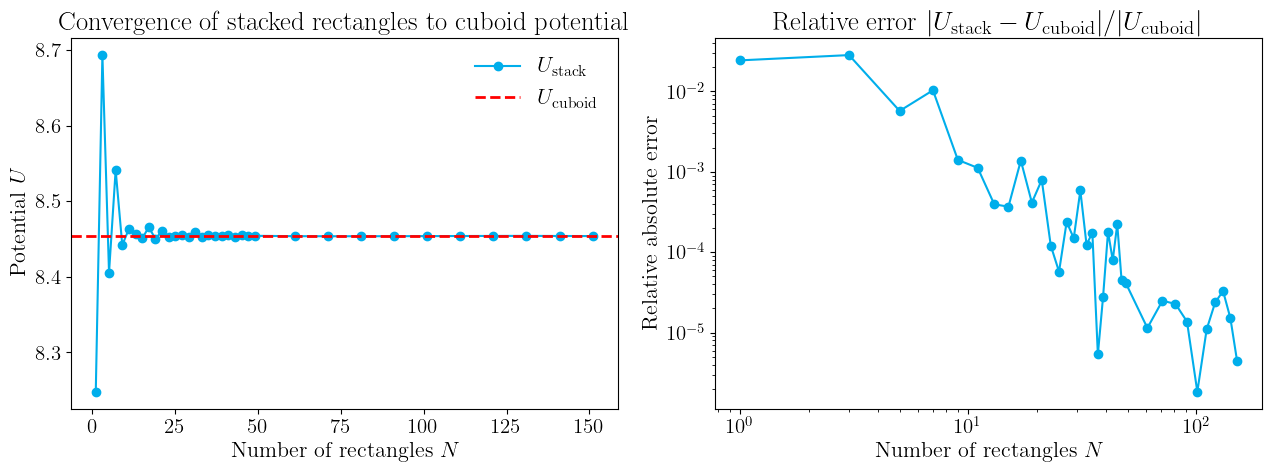

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Imports
# -----------------------------
from CuboidGravitationalField.potential import Gravitational_potential_cuboid
from RectangleGravitationalField.rectangle_potential import gravitational_potential_rectangle

# ---------------------------------------------------------
# COLORS
# ---------------------------------------------------------
lb = np.array([0, 174, 235]) / 255.0   # blue for stacked rectangles
cube_color = 'red'

# ---------------------------------------------------------
# CUBE PARAMETERS
# ---------------------------------------------------------
G = 1.0
rho = 1.0

L_full, B_full, D_full = 2.0, 2.0, 2.0
a = L_full / 2.0
b = B_full / 2.0
c = D_full / 2.0

# ---------------------------------------------------------
# FIELD POINT (arbitrary, not symmetric)
# ---------------------------------------------------------
x0, y0, z0 = 0.37, -0.21, 0.58

# Reference cuboid potential
V_cub = Gravitational_potential_cuboid(x0, y0, z0, a, b, c, rho, G)

# ---------------------------------------------------------
# STACKED RECTANGLE APPROXIMATION
# ---------------------------------------------------------
def stacked_rectangle_potential(x, y, z, a, b, c, rho, G, N):
    """
    Cuboid potential approximated by N stacked rectangles.
    N must be odd so z=0 plane exists.
    """
    dz = 2.0 * c / N
    sigma = rho * dz

    # Midpoint positions (symmetric, includes z=0)
    z_k = -c + (np.arange(N) + 0.5) * dz

    Vsum = 0.0
    for zk in z_k:
        Vsum += gravitational_potential_rectangle(
            x, y, z - zk, a, b, sigma, G=G
        )
    return Vsum

# ---------------------------------------------------------
# N VALUES (dense < 100)
# ---------------------------------------------------------
N_dense = np.arange(1, 51, 2)                 # 1,3,5,...,99
N_sparse = np.array([61, 71, 81, 91, 101, 111, 121, 131, 141, 151]) # larger N
N_list = np.concatenate([N_dense, N_sparse])

V_stack = np.zeros_like(N_list, dtype=float)
rel_err = np.zeros_like(N_list, dtype=float)

for i, N in enumerate(N_list):
    Vn = stacked_rectangle_potential(x0, y0, z0, a, b, c, rho, G, int(N))
    V_stack[i] = Vn
    rel_err[i] = np.abs(Vn - V_cub) / np.abs(V_cub)

# ---------------------------------------------------------
# PRINT TABLE
# ---------------------------------------------------------
print("------------------------------------------------------------")
print(f"Field point: (x,y,z) = ({x0:.3f}, {y0:.3f}, {z0:.3f})")
print(f"Reference cuboid V   = {V_cub:.16e}")
print("------------------------------------------------------------")
print("   N        V_stack                Relative error")
for N, Vn, er in zip(N_list, V_stack, rel_err):
    print(f"{int(N):4d}   {Vn:.16e}   {er:.3e}")
print("------------------------------------------------------------")

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

# ---- Potential convergence ----
axs[0].plot(
    N_list, V_stack,
    marker='o', linestyle='-',
    color=lb, label=r'$U_{\mathrm{stack}}$'
)

axs[0].axhline(
    V_cub,
    color=cube_color, linestyle='--', linewidth=2,
    label=r'$U_{\mathrm{cuboid}}$'
)

axs[0].set_xlabel(r'Number of rectangles $N$')
axs[0].set_ylabel(r'Potential $U$')
axs[0].set_title('Convergence of stacked rectangles to cuboid potential')
axs[0].legend(frameon=False)

# ---- Relative absolute error ----
axs[1].loglog(
    N_list, rel_err,
    marker='o', linestyle='-',
    color=lb
)

axs[1].set_xlabel(r'Number of rectangles $N$')
axs[1].set_ylabel(r'Relative absolute error')
axs[1].set_title(r'Relative error $|U_{\mathrm{stack}}-U_{\mathrm{cuboid}}|/|U_{\mathrm{cuboid}}|$')

plt.tight_layout()
plt.show()


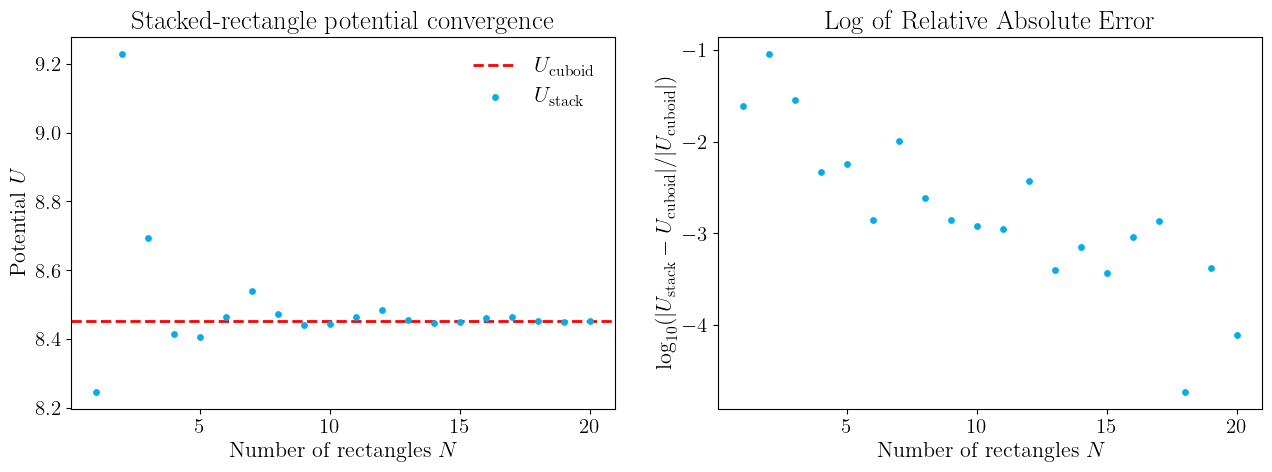

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Imports
# -----------------------------
from CuboidGravitationalField.potential import Gravitational_potential_cuboid
from RectangleGravitationalField.rectangle_potential import gravitational_potential_rectangle

# ---------------------------------------------------------
# COLORS
# ---------------------------------------------------------
lb = np.array([0, 174, 235]) / 255.0   # stacked rectangles (blue)
cube_color = 'red'

# ---------------------------------------------------------
# CUBE PARAMETERS
# ---------------------------------------------------------
G = 1.0
rho = 1.0

L_full, B_full, D_full = 2.0, 2.0, 2.0
a = L_full / 2.0
b = B_full / 2.0
c = D_full / 2.0

# ---------------------------------------------------------
# FIELD POINT
# ---------------------------------------------------------
x0, y0, z0 = 0.37, -0.21, 0.58

# Reference cuboid potential
V_cub = Gravitational_potential_cuboid(x0, y0, z0, a, b, c, rho, G)

# ---------------------------------------------------------
# STACKED RECTANGLE POTENTIAL
# ---------------------------------------------------------
def stacked_rectangle_potential(x, y, z, a, b, c, rho, G, N):
    dz = 2.0 * c / N
    sigma = rho * dz
    z_k = -c + (np.arange(N) + 0.5) * dz

    Vsum = 0.0
    for zk in z_k:
        Vsum += gravitational_potential_rectangle(
            x, y, z - zk, a, b, sigma, G=G
        )
    return Vsum

# ---------------------------------------------------------
# N VALUES (dense below 100)
# ---------------------------------------------------------
N_dense = np.arange(1,21, 1)                 # 1,3,5,...,99
#N_sparse = np.array([0]) # larger N
N_list = np.concatenate([N_dense])

V_stack = np.zeros_like(N_list, dtype=float)
rel_err = np.zeros_like(N_list, dtype=float)

for i, N in enumerate(N_list):
    Vn = stacked_rectangle_potential(x0, y0, z0, a, b, c, rho, G, int(N))
    V_stack[i] = Vn
    rel_err[i] = np.abs(Vn - V_cub) / np.abs(V_cub)

log_rel_err = np.log10(rel_err)

# ---------------------------------------------------------
# PLOTS (SCATTER)
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

# ---- Potential convergence (scatter) ----
axs[0].axhline(
    V_cub,
    color=cube_color, linestyle='--', linewidth=2,   zorder=1, 
    label=r'$U_{\mathrm{cuboid}}$'
)

axs[0].scatter(
    N_list, V_stack,
    s=15, color=lb, zorder=3, label=r'$U_{\mathrm{stack}}$'
)

axs[0].set_xlabel(r'Number of rectangles $N$')
axs[0].set_ylabel(r'Potential $U$')
axs[0].set_title('Stacked-rectangle potential convergence')
axs[0].legend(frameon=False)

# ---- Relative absolute error (scatter, log-log) ----
axs[1].scatter(
    N_list,
    log_rel_err,
    s=15,
    color=lb,
    zorder=3
)

axs[1].set_xlabel(r'Number of rectangles $N$')
axs[1].set_ylabel(r'$\log_{10}\!\left(|U_{\mathrm{stack}}-U_{\mathrm{cuboid}}|/|U_{\mathrm{cuboid}}|\right)$')
axs[1].set_title(
    r'$\mathrm{ Log\ of\ Relative\ Absolute\ Error}$'
)

plt.tight_layout()
plt.savefig("Validation_III_StackedRect_vs_Cuboid.pdf", bbox_inches="tight")
plt.show()


#### Test 06

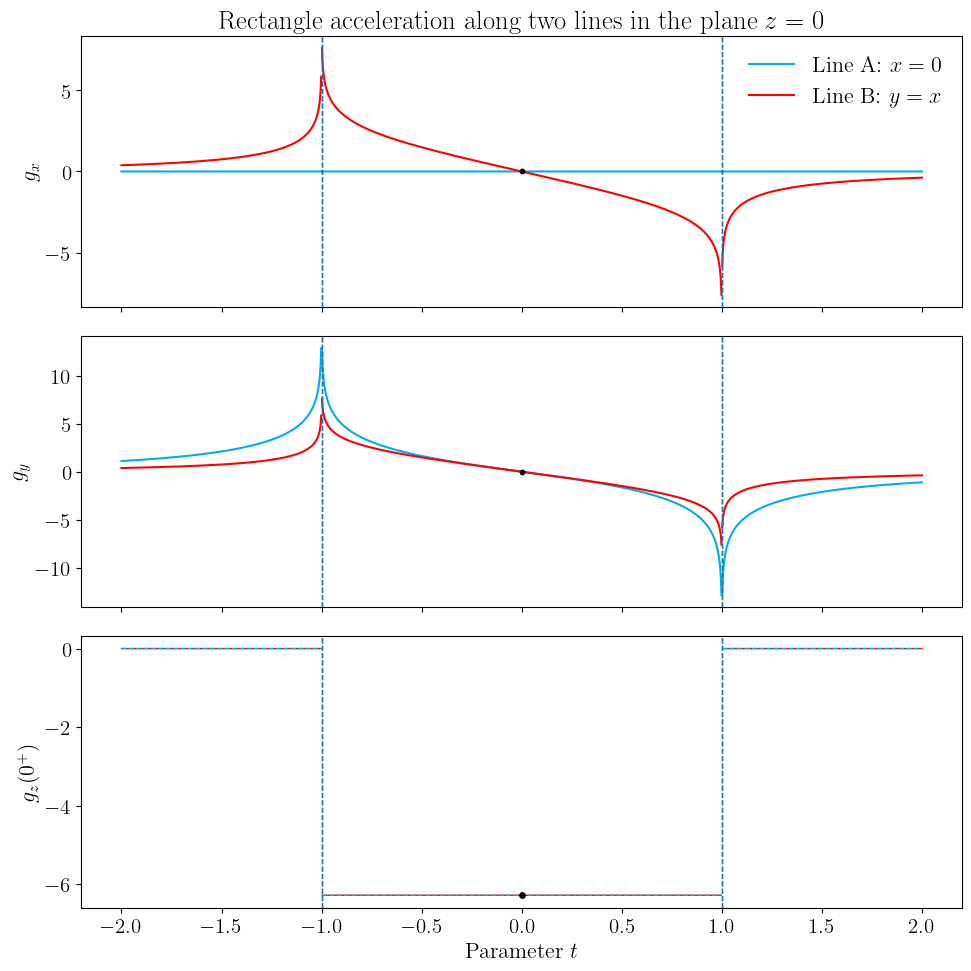

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
    gravitational_gz_rectangle
)

# ---------------------------------------------------------
# PARAMETERS (Rectangle in z=0 plane)
# ---------------------------------------------------------
G = 1.0
sigma = 1.0
L = 1.0   # half-length in x
B = 1.0   # half-length in y

lb = np.array([0, 174, 235]) / 255.0  # blue
red = 'red'

# We are evaluating in the plane z=0, but gz is discontinuous.
# So we use a tiny signed eps for gz; and for gx, gy we can keep z=0.
eps = 1e-15

# ---------------------------------------------------------
# CENTER VALUE (x=0, y=0, z=0+)
# ---------------------------------------------------------
xC, yC, zC = 0.0, 0.0, eps

gxC = gravitational_gx_rectangle(xC, yC, 0.0, L, B, sigma, G=G)
gyC = gravitational_gy_rectangle(xC, yC, 0.0, L, B, sigma, G=G)
gzC = gravitational_gz_rectangle(xC, yC, zC, L, B, sigma, G=G, eps=eps)


# Range to go exterior -> interior -> exterior
tmin, tmax = -2.0, 2.0
N = 2001
t = np.linspace(tmin, tmax, N)

# ---------------------------------------------------------
# Helper: compute along a parametric line (x(t), y(t))
# ---------------------------------------------------------
def eval_line(x_arr, y_arr, label):
    gx = np.empty_like(x_arr, dtype=float)
    gy = np.empty_like(x_arr, dtype=float)
    gz = np.empty_like(x_arr, dtype=float)

    # Flags for divergence points (edges/vertices in plane)
    diverge = np.zeros_like(x_arr, dtype=bool)

    for i, (x, y) in enumerate(zip(x_arr, y_arr)):
        # Identify divergence conditions in the plane z=0:
        # Edge: x=±L with |y|<=B OR y=±B with |x|<=L
        # Vertex: (±L, ±B)
        on_x_edge = (np.isclose(abs(x), L) and (abs(y) <= B + 1e-14))
        on_y_edge = (np.isclose(abs(y), B) and (abs(x) <= L + 1e-14))
        if on_x_edge or on_y_edge:
            diverge[i] = True
            gx[i] = np.nan
            gy[i] = np.nan
            gz[i] = np.nan
            continue

        # Otherwise compute normally:
        gx[i] = gravitational_gx_rectangle(x, y, 0.0, L, B, sigma, G=G)
        gy[i] = gravitational_gy_rectangle(x, y, 0.0, L, B, sigma, G=G)

        # gz: use one-sided evaluation because of jump at z=0
        # choose z=+eps (above the sheet)
        gz[i] = gravitational_gz_rectangle(x, y, +eps, L, B, sigma, G=G, eps=eps)

        # If your updated rectangle code returns inf at certain points, mask it too:
        if not np.isfinite(gx[i]) or not np.isfinite(gy[i]) or not np.isfinite(gz[i]):
            diverge[i] = True
            gx[i] = np.nan
            gy[i] = np.nan
            gz[i] = np.nan

    return gx, gy, gz, diverge, label

# ---------------------------------------------------------
# Line 1: x=0, y varies
# ---------------------------------------------------------
x1 = np.zeros_like(t)
y1 = t

gx1, gy1, gz1, div1, label1 = eval_line(x1, y1, r'Line A: $x=0$')

# Divergence points for line A: y=±B (edges) and vertices are not on x=0 unless L=0
div_y_edges = np.array([-B, +B])

# ---------------------------------------------------------
# Line 2: y=x (diagonal)
# ---------------------------------------------------------
x2 = t
y2 = t

gx2, gy2, gz2, div2, label2 = eval_line(x2, y2, r'Line B: $y=x$')

# Divergence for diagonal occurs at intersection with rectangle boundary:
# For square L=B, it hits vertices at x=±L.
# In general, vertices if L=B; otherwise it hits whichever boundary is reached first.
# We'll compute those intercepts:
if np.isclose(L, B):
    div_diag = np.array([-L, +L])  # vertices
else:
    div_diag = np.array([-min(L, B), +min(L, B)])  # hits an edge first

# ---------------------------------------------------------
# PLOT: subplots gx, gy, gz vs parameter t
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# ---- gx ----
axs[0].plot(t, gx1, color=lb, label=label1)
axs[0].plot(t, gx2, color=red, label=label2)
axs[0].scatter(0.0, gxC, color='black', s=10, zorder=4)

axs[0].set_ylabel(r'$g_x$')
axs[0].set_title(r'Rectangle acceleration along two lines in the plane $z=0$')
axs[0].legend(frameon=False)

# ---- gy ----
axs[1].plot(t, gy1, color=lb)
axs[1].plot(t, gy2, color=red)
axs[1].scatter(0.0, gyC, color='black', s=10, zorder=4)

axs[1].set_ylabel(r'$g_y$')

# ---- gz ----
# Red curve FIRST (background)
axs[2].plot(
    t, gz2,
    color='red',
    linestyle='-',
    linewidth=1,
    zorder=1,
    label=label2
)

# Blue curve SECOND (foreground, dashed)
axs[2].plot(
    t, gz1,
    color=lb,
    linestyle='--',
    linewidth=1,
    zorder=3,
    label=label1
)

# Center point
axs[2].scatter(
    0.0, gzC,
    color='black',
    s=15,
    zorder=5
)

axs[2].set_ylabel(r'$g_z(0^+)$')
axs[2].set_xlabel(r'Parameter $t$')


# ---------------------------------------------------------
# Mark divergence points with vertical dashed lines
# ---------------------------------------------------------
for ax in axs:
    # Line A divergence at y=±B (since x=0)
    for yy in div_y_edges:
        ax.axvline(yy, linestyle='--', linewidth=1)

    # Line B divergence near boundary intersection
    for dd in div_diag:
        ax.axvline(dd, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


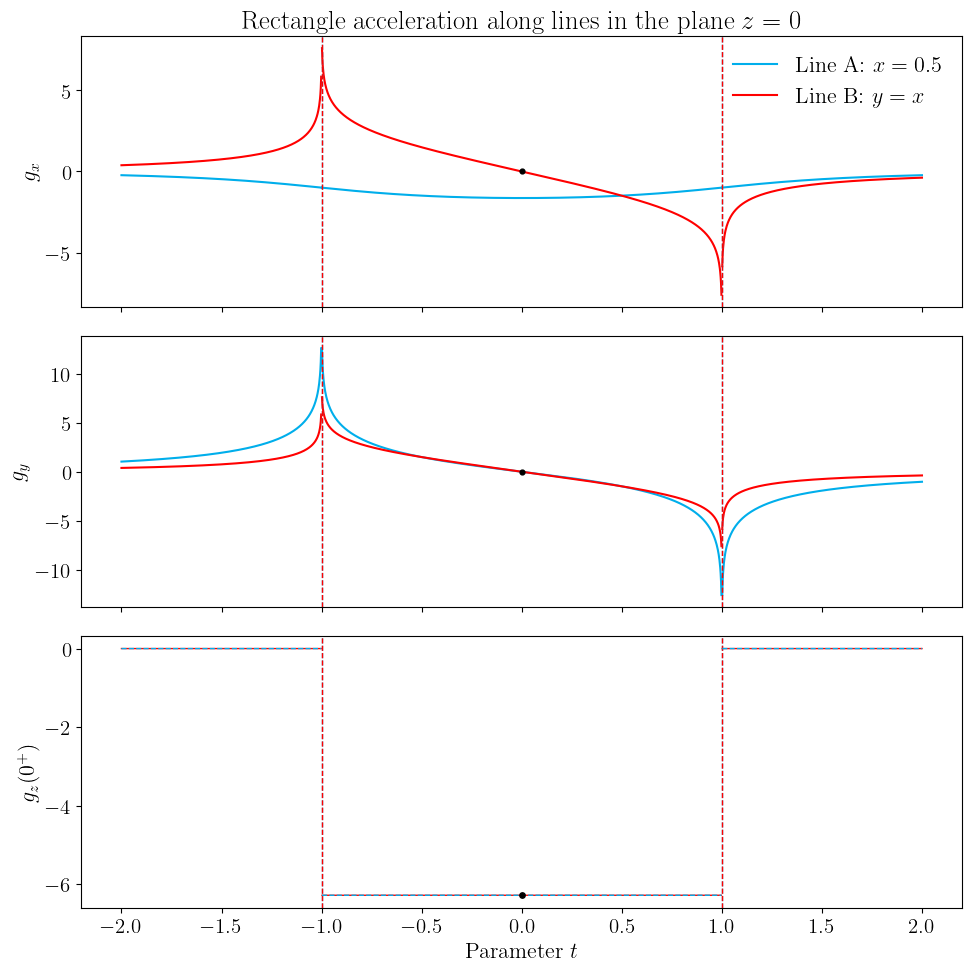

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
    gravitational_gz_rectangle
)

# ---------------------------------------------------------
# PARAMETERS (Rectangle in z=0 plane): x∈[-L,L], y∈[-B,B]
# ---------------------------------------------------------
G = 1.0
sigma = 1.0
L = 1.0   # half-length in x
B = 1.0   # half-length in y

lb = np.array([0, 174, 235]) / 255.0  # blue
red = "red"

# gz is discontinuous at z=0, so evaluate gz at z=+eps
eps = 1e-15

# ---------------------------------------------------------
# CENTER VALUE (x=0, y=0, z=0+)
# ---------------------------------------------------------
xC, yC, zC = 0.0, 0.0, eps
gxC = gravitational_gx_rectangle(xC, yC, 0.0, L, B, sigma, G=G)
gyC = gravitational_gy_rectangle(xC, yC, 0.0, L, B, sigma, G=G)
gzC = gravitational_gz_rectangle(xC, yC, zC, L, B, sigma, G=G, eps=eps)

# ---------------------------------------------------------
# Parameter range (exterior -> interior -> exterior)
# ---------------------------------------------------------
tmin, tmax = -2.0, 2.0
N = 2001
t = np.linspace(tmin, tmax, N)

# ---------------------------------------------------------
# Helper: compute along a parametric line (x(t), y(t))
# ---------------------------------------------------------
def eval_line(x_arr, y_arr, label):
    gx = np.empty_like(x_arr, dtype=float)
    gy = np.empty_like(x_arr, dtype=float)
    gz = np.empty_like(x_arr, dtype=float)
    diverge = np.zeros_like(x_arr, dtype=bool)

    tol_edge = 1e-14

    for i, (x, y) in enumerate(zip(x_arr, y_arr)):
        # Points on the boundary in the plane z=0 are improper for gx,gy (log singularities),
        # so mask them (edges AND vertices).
        on_x_edge = (np.isclose(abs(x), L, atol=tol_edge) and (abs(y) <= B + tol_edge))
        on_y_edge = (np.isclose(abs(y), B, atol=tol_edge) and (abs(x) <= L + tol_edge))

        if on_x_edge or on_y_edge:
            diverge[i] = True
            gx[i] = np.nan
            gy[i] = np.nan
            gz[i] = np.nan
            continue

        gx[i] = gravitational_gx_rectangle(x, y, 0.0, L, B, sigma, G=G)
        gy[i] = gravitational_gy_rectangle(x, y, 0.0, L, B, sigma, G=G)
        gz[i] = gravitational_gz_rectangle(x, y, +eps, L, B, sigma, G=G, eps=eps)

        if (not np.isfinite(gx[i])) or (not np.isfinite(gy[i])) or (not np.isfinite(gz[i])):
            diverge[i] = True
            gx[i] = np.nan
            gy[i] = np.nan
            gz[i] = np.nan

    return gx, gy, gz, diverge, label

# ---------------------------------------------------------
# TEST LINE (parallel to y-axis): x = x0, y varies
# ---------------------------------------------------------
x0 = 0.5  

x1 = np.full_like(t, x0)
y1 = t

gx1, gy1, gz1, div1, label1 = eval_line(x1, y1, rf"Line A: $x={x0}$")

# Divergence points for this line:
# It hits the horizontal edges y=±B at t=±B provided |x0|<L.
# If |x0|==L, the whole segment inside is on the vertical edge (different case).
div_A = []
if abs(x0) < L - 1e-14:
    div_A = [-B, +B]   # edge hits at y = ±B
elif np.isclose(abs(x0), L, atol=1e-14):
    # On the vertical edge x=±L: gx is the singular component at y within [-B,B],
    # and additionally y=±B are vertices. Mark vertices at least.
    div_A = [-B, +B]
else:
    div_A = []  # line misses the rectangle entirely

# ---------------------------------------------------------
# OPTIONAL: keep your diagonal line for comparison (y=x)
# ---------------------------------------------------------
x2 = t
y2 = t
gx2, gy2, gz2, div2, label2 = eval_line(x2, y2, r"Line B: $y=x$")

# Diagonal hits boundary at t = ±min(L,B) (vertices if L=B).
div_B = [-min(L, B), +min(L, B)]

# ---------------------------------------------------------
# PLOT: subplots gx, gy, gz vs parameter t
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# ---- gx ----
axs[0].plot(t, gx1, color=lb, label=label1)
axs[0].plot(t, gx2, color=red, label=label2)
axs[0].scatter(0.0, gxC, color="black", s=12, zorder=4)
axs[0].set_ylabel(r"$g_x$")
axs[0].set_title(r"Rectangle acceleration along lines in the plane $z=0$")
axs[0].legend(frameon=False)

# ---- gy ----
axs[1].plot(t, gy1, color=lb)
axs[1].plot(t, gy2, color=red)
axs[1].scatter(0.0, gyC, color="black", s=12, zorder=4)
axs[1].set_ylabel(r"$g_y$")

# ---- gz ----
axs[2].plot(t, gz2, color=red, linestyle="-", linewidth=1, zorder=1)
axs[2].plot(t, gz1, color=lb, linestyle="--", linewidth=1, zorder=3)
axs[2].scatter(0.0, gzC, color="black", s=15, zorder=5)
axs[2].set_ylabel(r"$g_z(0^+)$")
axs[2].set_xlabel(r"Parameter $t$")

# ---------------------------------------------------------
# Mark divergence points with vertical dashed lines
# ---------------------------------------------------------
for ax in axs:
    for dd in div_A:
        ax.axvline(dd, linestyle="--", linewidth=1, color=lb)
    for dd in div_B:
        ax.axvline(dd, linestyle="--", linewidth=1, color=red)

plt.tight_layout()
plt.show()


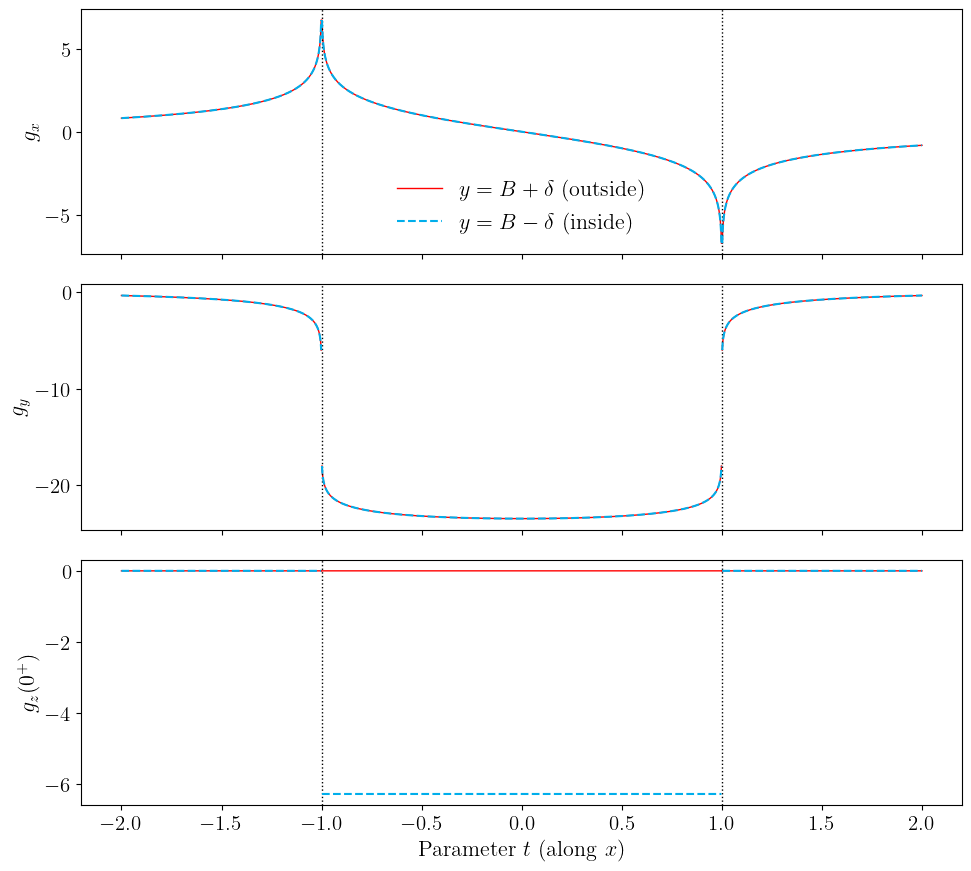

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
    gravitational_gz_rectangle
)

# ---------------------------------------------------------
# PARAMETERS (Rectangle in z=0 plane): x∈[-L,L], y∈[-B,B]
# ---------------------------------------------------------
G = 1.0
sigma = 1.0
L = 1.0
B = 1.0

lb = np.array([0, 174, 235]) / 255.0  # blue

# gz is discontinuous at z=0, so evaluate gz at z=+eps
epsz = 1e-15

# ---------------------------------------------------------
# TEST: field points along a line parallel to x-axis,
# approaching the horizontal edge y = +B (or y = -B)
#
# Prediction (your paired-point argument):
#   gy singular (normal to edge), gx finite (tangent)
#
# IMPORTANT: do NOT evaluate exactly at y=B in-plane.
# Instead use a one-sided approach: y = B - delta (inside)
# and/or y = B + delta (outside).
# ---------------------------------------------------------
delta = 1e-5  # try 1e-4, 1e-6, 1e-8 to see sharpening

# Parameter along the line (sweeps left -> right)
tmin, tmax = -2.0 * L, 2.0 * L
N = 2001
t = np.linspace(tmin, tmax, N)

# Two near-edge lines: inside and outside
x = t
y_in  = np.full_like(t, B - delta)  # just inside the lamina
y_out = np.full_like(t, B + delta)  # just outside the lamina

def eval_line(x_arr, y_arr):
    gx = np.empty_like(x_arr, dtype=float)
    gy = np.empty_like(x_arr, dtype=float)
    gz = np.empty_like(x_arr, dtype=float)

    for i, (xx, yy) in enumerate(zip(x_arr, y_arr)):
        gx[i] = gravitational_gx_rectangle(xx, yy, 0.0, L, B, sigma, G=G)
        gy[i] = gravitational_gy_rectangle(xx, yy, 0.0, L, B, sigma, G=G)
        gz[i] = gravitational_gz_rectangle(xx, yy, +epsz, L, B, sigma, G=G, eps=epsz)

        if (not np.isfinite(gx[i])) or (not np.isfinite(gy[i])) or (not np.isfinite(gz[i])):
            gx[i] = np.nan
            gy[i] = np.nan
            gz[i] = np.nan

    return gx, gy, gz

gx_in,  gy_in,  gz_in  = eval_line(x, y_in)
gx_out, gy_out, gz_out = eval_line(x, y_out)

# ---------------------------------------------------------
# PLOT: red solid (background), blue dashed (foreground)
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# ---- gx ----
axs[0].plot(
    t, gx_out,
    color="red",
    linestyle="-",
    linewidth=1.0,
    zorder=1,
    label=r"$y=B+\delta$ (outside)"
)
axs[0].plot(
    t, gx_in,
    color=lb,
    linestyle="--",
    linewidth=1.5,
    zorder=3,
    label=r"$y=B-\delta$ (inside)"
)
axs[0].set_ylabel(r"$g_x$")
axs[0].legend(frameon=False)

# ---- gy ----
axs[1].plot(
    t, gy_out,
    color="red",
    linestyle="-",
    linewidth=1.0,
    zorder=1
)
axs[1].plot(
    t, gy_in,
    color=lb,
    linestyle="--",
    linewidth=1.5,
    zorder=3
)
axs[1].set_ylabel(r"$g_y$")

# ---- gz ----
axs[2].plot(
    t, gz_out,
    color="red",
    linestyle="-",
    linewidth=1.0,
    zorder=1
)
axs[2].plot(
    t, gz_in,
    color=lb,
    linestyle="--",
    linewidth=1.5,
    zorder=3
)
axs[2].set_ylabel(r"$g_z(0^+)$")
axs[2].set_xlabel(r"Parameter $t$ (along $x$)")

# Mark vertex locations (corners)
for ax in axs:
    ax.axvline(-L, linestyle=":", linewidth=1, color="k")
    ax.axvline(+L, linestyle=":", linewidth=1, color="k")

plt.tight_layout()
plt.show()



#### Text 07: Rectangle versus two-triangle decomposition

tri1 n_hat: [0. 0. 1.]
tri2 n_hat: [0. 0. 1.]

--- mapping check at safe point ---
P_test = (0.23, -0.17, 0.31)
g_rect = [-0.58457303  0.42445486 -4.51976227]
best mapped g_tri = [-0.58457303  0.42445486 -4.51976227]
chosen tri_sign = -1.0
chosen tri_zflip = False (z' = z since z_r=0)
best ||mapped - rect|| = 6.280369834735101e-16
-----------------------------------



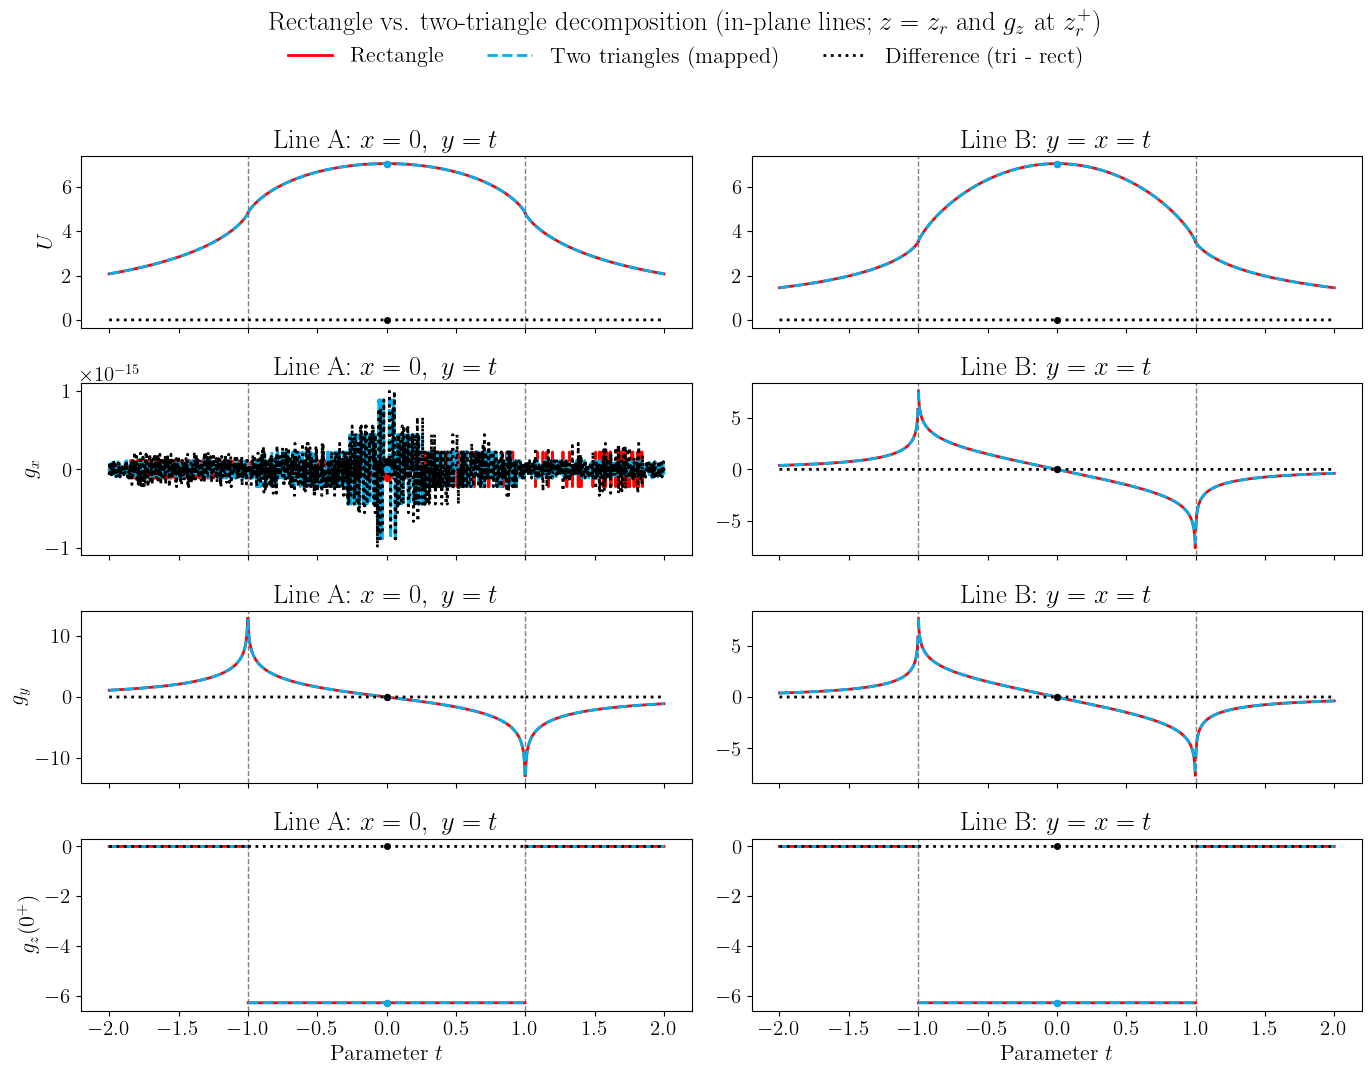

Saved figure to: Test07_Rectangle_vs_TwoTriangles.pdf


In [10]:
# ============================================================
# TEST 07  (UPDATED for manuscript figure + PDF export)
# Rectangle (analytic) vs Rectangle built from TWO TRIANGLES
#
# Lines in plane z=z_r:
#   Line A: x=0, y=t
#   Line B: y=x=t
#
# Quantities:
#   U at z=z_r
#   gx, gy at z=z_r
#   gz at z=z_r^+ (use z=z_r+eps to take the one-sided limit)
#
# IMPORTANT:
# - Triangle module may differ by an overall sign and/or z-reflection.
# - We auto-detect BOTH using a safe off-plane point.
#
# Plot:
#   red solid   = rectangle
#   blue dashed = mapped two-triangle result
#   black dotted= difference (tri - rect)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Imports
# -----------------------------
from RectangleGravitationalField.rectangle_potential import gravitational_potential_rectangle
from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
    gravitational_gz_rectangle,
)

from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation


# ============================================================
# PARAMETERS
# ============================================================
G = 1.0
sigma = 1.0
L = 1.0   # half-length in x
B = 1.0   # half-length in y
z_r = 0.0 # rectangle plane
eps = 1e-10  # for gz(z_r^+)

# Colors
lb = np.array([0, 174, 235]) / 255.0  # blue
red = "red"
diff_color = "black"

# Output
out_pdf = "Test07_Rectangle_vs_TwoTriangles.pdf"


# ============================================================
# Helper: enforce triangle normal aligned with +z
# ============================================================
def oriented_triangle(vertices, *, desired_nhat, G=1.0, sigma=1.0, eps=0.0):
    v = np.asarray(vertices, dtype=float)
    n_raw = np.cross(v[1] - v[0], v[2] - v[0])
    if np.dot(n_raw, desired_nhat) < 0.0:
        v = v[[0, 2, 1]]  # flip winding
    return TriangleLaminaGravitation(vertices=v, G=G, sigma=sigma, eps=eps)


# ============================================================
# Build rectangle [-L,L] x [-B,B] at z=z_r from 2 triangles
# ============================================================
v00 = np.array([-L, -B, z_r])
v10 = np.array([+L, -B, z_r])
v11 = np.array([+L, +B, z_r])
v01 = np.array([-L, +B, z_r])

desired_nhat = np.array([0.0, 0.0, 1.0])

tri1 = oriented_triangle(np.vstack([v00, v10, v11]), desired_nhat=desired_nhat, G=G, sigma=sigma, eps=0.0)
tri2 = oriented_triangle(np.vstack([v00, v11, v01]), desired_nhat=desired_nhat, G=G, sigma=sigma, eps=0.0)

print("tri1 n_hat:", tri1.n_hat)
print("tri2 n_hat:", tri2.n_hat)


# ============================================================
# Rectangle fields at a point
# ============================================================
def rect_U(x, y, z):
    return gravitational_potential_rectangle(x, y, z, L, B, sigma, G=G)

def rect_g(x, y, z):
    gx = gravitational_gx_rectangle(x, y, z, L, B, sigma, G=G)
    gy = gravitational_gy_rectangle(x, y, z, L, B, sigma, G=G)
    gz = gravitational_gz_rectangle(x, y, z, L, B, sigma, G=G, eps=eps)
    return np.array([gx, gy, gz], dtype=float)


# ============================================================
# Triangle fields at a point (sum of 2 triangles)
# ============================================================
def tri_U_raw(x, y, z):
    P = np.array([x, y, z], dtype=float)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        return -float(tri1.potential(P) + tri2.potential(P))

def tri_g_raw(x, y, z):
    P = np.array([x, y, z], dtype=float)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        return (tri1.acceleration(P) + tri2.acceleration(P)).astype(float)


# ============================================================
# AUTO-DETECT mapping: (global sign) × (optional z-flip)
# Choose (s, zflip) minimizing || mapped - rect || at a safe point.
# ============================================================
xT, yT, zT = 0.23, -0.17, 0.31  # safe point off-plane
gR = rect_g(xT, yT, zT)

def z_map(z, zflip):
    return (2.0 * z_r - z) if zflip else z

candidates = []
for s in (+1.0, -1.0):
    for zflip in (False, True):
        gT = s * tri_g_raw(xT, yT, z_map(zT, zflip))
        err = np.linalg.norm(gT - gR)
        candidates.append((err, s, zflip, gT))

candidates.sort(key=lambda x: x[0])
best_err, tri_sign, tri_zflip, gT_best = candidates[0]

print("\n--- mapping check at safe point ---")
print("P_test =", (xT, yT, zT))
print("g_rect =", gR)
print("best mapped g_tri =", gT_best)
print("chosen tri_sign =", tri_sign)
print("chosen tri_zflip =", tri_zflip, f"(z' = {'-z' if tri_zflip else 'z'} since z_r=0)")
print("best ||mapped - rect|| =", best_err)
print("-----------------------------------\n")


# ============================================================
# Two triangles along a line:
# U, gx,gy on plane z=z_r ; gz at z=z_r+eps
# Apply mapping consistently.
# ============================================================
def tri2_line_fields_mapped(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # U on plane
    U = np.empty_like(x, dtype=float)
    # gx,gy on plane
    z0 = np.zeros_like(x) + z_r
    P0 = np.column_stack([x, y, z_map(z0, tri_zflip)])
    g0 = tri_sign * (tri1.acceleration(P0) + tri2.acceleration(P0))

    # gz at z_r^+
    zp = np.zeros_like(x) + (z_r + eps)
    Pp = np.column_stack([x, y, z_map(zp, tri_zflip)])
    gp = tri_sign * (tri1.acceleration(Pp) + tri2.acceleration(Pp))

    for i in range(x.size):
        U[i] = tri_sign * tri_U_raw(x[i], y[i], z_map(z_r, tri_zflip))

    gx = g0[:, 0]
    gy = g0[:, 1]
    gz = gp[:, 2]
    return U, gx, gy, gz


# ============================================================
# Rectangle along a line:
# U, gx,gy on plane z=z_r ; gz at z=z_r+eps
# ============================================================
def rect_line_fields(x, y):
    U  = np.empty_like(x, dtype=float)
    gx = np.empty_like(x, dtype=float)
    gy = np.empty_like(x, dtype=float)
    gz = np.empty_like(x, dtype=float)
    for i in range(x.size):
        U[i]  = rect_U(x[i], y[i], z_r)
        gx[i] = gravitational_gx_rectangle(x[i], y[i], z_r, L, B, sigma, G=G)
        gy[i] = gravitational_gy_rectangle(x[i], y[i], z_r, L, B, sigma, G=G)
        gz[i] = gravitational_gz_rectangle(x[i], y[i], z_r + eps, L, B, sigma, G=G, eps=eps)
    return U, gx, gy, gz


# ============================================================
# Lines for Test 07
# ============================================================
tmin, tmax = -2.0, 2.0
N = 2001
t = np.linspace(tmin, tmax, N)

# Line A: x=0, y=t
xA = np.zeros_like(t)
yA = t.copy()

# Line B: y=x=t
xB = t.copy()
yB = t.copy()


# ============================================================
# Divergence mask on plane z=z_r (rectangle edges)
# ============================================================
def divergence_mask(x, y, atol=1e-14):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    on_x_edge = np.isclose(np.abs(x), L, atol=atol) & (np.abs(y) <= B + atol)
    on_y_edge = np.isclose(np.abs(y), B, atol=atol) & (np.abs(x) <= L + atol)
    return on_x_edge | on_y_edge


# ============================================================
# Compute all for a given line
# ============================================================
def compute_all(x, y, title):
    U_r, gx_r, gy_r, gz_r = rect_line_fields(x, y)
    U_t, gx_t, gy_t, gz_t = tri2_line_fields_mapped(x, y)

    div = divergence_mask(x, y)

    # mask singular edge points on-plane
    for arr in (U_r, gx_r, gy_r, U_t, gx_t, gy_t):
        arr[div] = np.nan
    # gz is evaluated at z_r+eps (finite), but keep markers consistent:
    gz_r[div] = np.nan
    gz_t[div] = np.nan

    dU  = U_t  - U_r
    dgx = gx_t - gx_r
    dgy = gy_t - gy_r
    dgz = gz_t - gz_r

    dU[div]  = np.nan
    dgx[div] = np.nan
    dgy[div] = np.nan
    dgz[div] = np.nan

    return (U_r, gx_r, gy_r, gz_r), (U_t, gx_t, gy_t, gz_t), (dU, dgx, dgy, dgz), title


rectA, triA, diffA, titleA = compute_all(xA, yA, r"Line A: $x=0,\ y=t$")
rectB, triB, diffB, titleB = compute_all(xB, yB, r"Line B: $y=x=t$")


# ============================================================
# Center dots at (0,0): U, gx,gy on plane; gz at z_r^+
# ============================================================
U_C_r  = rect_U(0.0, 0.0, z_r)
gxC_r  = gravitational_gx_rectangle(0.0, 0.0, z_r, L, B, sigma, G=G)
gyC_r  = gravitational_gy_rectangle(0.0, 0.0, z_r, L, B, sigma, G=G)
gzC_r  = gravitational_gz_rectangle(0.0, 0.0, z_r + eps, L, B, sigma, G=G, eps=eps)

U_C_t  = tri_sign * tri_U_raw(0.0, 0.0, z_map(z_r, tri_zflip))

gC0_t = tri_sign * (tri1.acceleration(np.array([0.0, 0.0, z_map(z_r, tri_zflip)])) +
                    tri2.acceleration(np.array([0.0, 0.0, z_map(z_r, tri_zflip)])))
gC1_t = tri_sign * (tri1.acceleration(np.array([0.0, 0.0, z_map(z_r + eps, tri_zflip)])) +
                    tri2.acceleration(np.array([0.0, 0.0, z_map(z_r + eps, tri_zflip)])))

gxC_t, gyC_t = float(gC0_t[0]), float(gC0_t[1])
gzC_t = float(gC1_t[2])

dU_C  = U_C_t  - U_C_r
dgxC  = gxC_t  - gxC_r
dgyC  = gyC_t  - gyC_r
dgzC  = gzC_t  - gzC_r


# ============================================================
# Divergence markers in parameter t
# ============================================================
marksA = [-B, +B]
marksB = [-min(L, B), +min(L, B)]


# ============================================================
# PLOT: 4 rows × 2 cols  (U, gx, gy, gz(0+))
# ============================================================
fig, axs = plt.subplots(4, 2, figsize=(14, 11), sharex=True)

def plot_panel(ax, rect, tri, diff, center_r, center_t, center_d, title, marks, ylabel=None):
    ax.plot(t, rect, color=red, linestyle="-",  linewidth=2, zorder=1)
    ax.plot(t, tri,  color=lb,  linestyle="--", linewidth=2, zorder=3)
    ax.plot(t, diff, color=diff_color, linestyle=":", linewidth=2, zorder=4)

    ax.scatter(0.0, center_r, color=red,       s=18, zorder=6)
    ax.scatter(0.0, center_t, color=lb,        s=18, zorder=7)
    ax.scatter(0.0, center_d, color=diff_color,s=16, zorder=8)

    for m in marks:
        ax.axvline(m, color="gray", linestyle="--", linewidth=1, zorder=0)

    ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

# Row 1: U
plot_panel(axs[0, 0], rectA[0], triA[0], diffA[0], U_C_r,  U_C_t,  dU_C,  titleA, marksA, ylabel=r"$U$")
plot_panel(axs[0, 1], rectB[0], triB[0], diffB[0], U_C_r,  U_C_t,  dU_C,  titleB, marksB)

# Row 2: gx
plot_panel(axs[1, 0], rectA[1], triA[1], diffA[1], gxC_r, gxC_t, dgxC, titleA, marksA, ylabel=r"$g_x$")
plot_panel(axs[1, 1], rectB[1], triB[1], diffB[1], gxC_r, gxC_t, dgxC, titleB, marksB)

# Row 3: gy
plot_panel(axs[2, 0], rectA[2], triA[2], diffA[2], gyC_r, gyC_t, dgyC, titleA, marksA, ylabel=r"$g_y$")
plot_panel(axs[2, 1], rectB[2], triB[2], diffB[2], gyC_r, gyC_t, dgyC, titleB, marksB)

# Row 4: gz(0+)
plot_panel(axs[3, 0], rectA[3], triA[3], diffA[3], gzC_r, gzC_t, dgzC, titleA, marksA, ylabel=r"$g_z(0^+)$")
plot_panel(axs[3, 1], rectB[3], triB[3], diffB[3], gzC_r, gzC_t, dgzC, titleB, marksB)

axs[3, 0].set_xlabel(r"Parameter $t$")
axs[3, 1].set_xlabel(r"Parameter $t$")

handles = [
    plt.Line2D([0], [0], color=red, linewidth=2, linestyle="-",  label="Rectangle"),
    plt.Line2D([0], [0], color=lb,  linewidth=2, linestyle="--", label="Two triangles (mapped)"),
    plt.Line2D([0], [0], color=diff_color, linewidth=2, linestyle=":", label=r"Difference (tri - rect)"),
]

# Journal-style suptitle
fig.suptitle(
    r"Rectangle vs. two-triangle decomposition (in-plane lines; $z=z_r$ and $g_z$ at $z_r^+$)",
    y=0.98
)

# Legend just below the suptitle
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.94])

# SAVE AS PDF
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_pdf}")


In [16]:
import numpy as np
from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation

G=1.0
sigma=1.0
v0=np.array([-1.0,-1.0,0.0])
v1=np.array([+1.0,-1.0,0.0])
v2=np.array([-1.0,+1.0,0.0])

tri = TriangleLaminaGravitation(np.vstack([v0,v1,v2]), G=G, sigma=sigma, eps=0.0)

A = 0.5*np.linalg.norm(np.cross(v1-v0, v2-v0))
M = sigma*A

P = np.array([0.2, -0.1, 1000.0])   # very far away
r = np.linalg.norm(P)

V = tri.potential(P)
V_asym = G*M/r

print("Area A =", A)
print("M =", M)
print("V(tri) =", V)
print("V_asym =", V_asym)
print("ratio V/V_asym =", V/V_asym)


Area A = 2.0
M = 2.0
V(tri) = 0.00199999921666734
V_asym = 0.001999999950000002
ratio V/V_asym = 0.9999996333336598


#### Test 08: Circular disk versus triangulated approximation

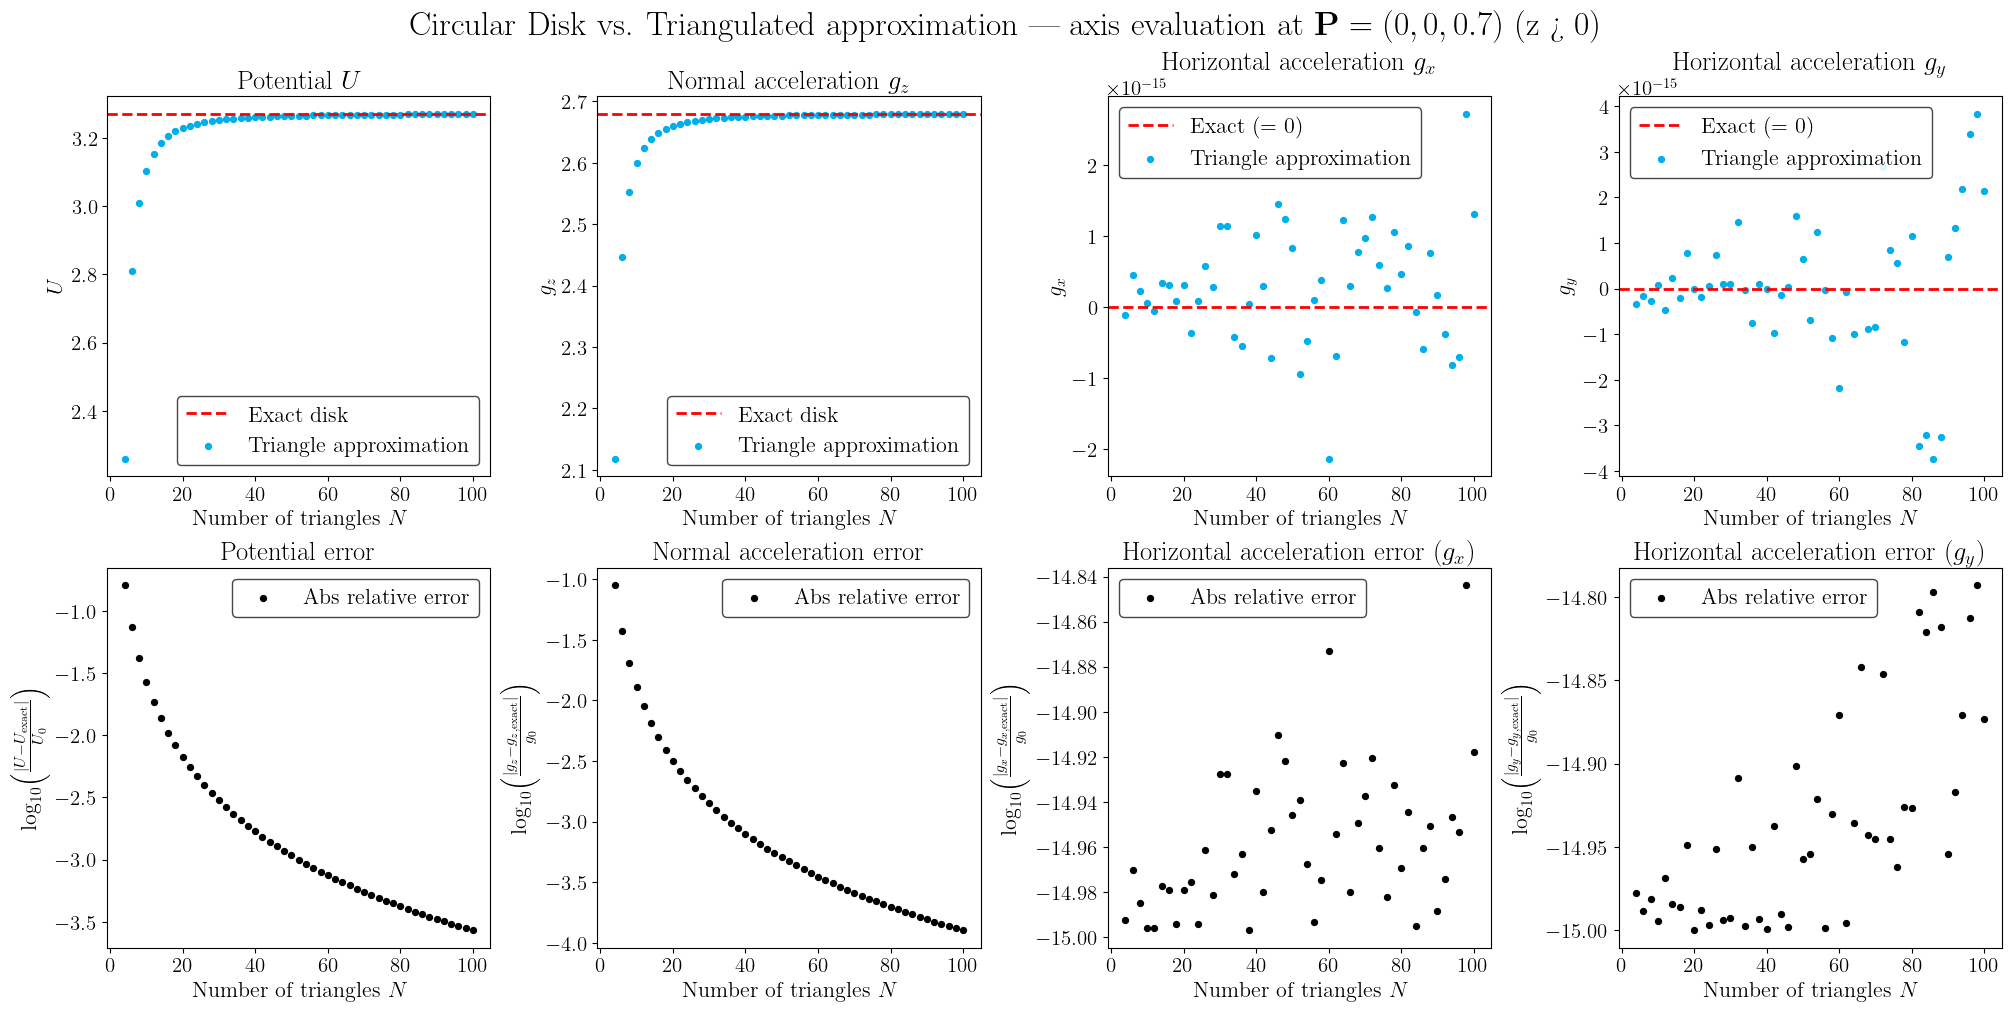

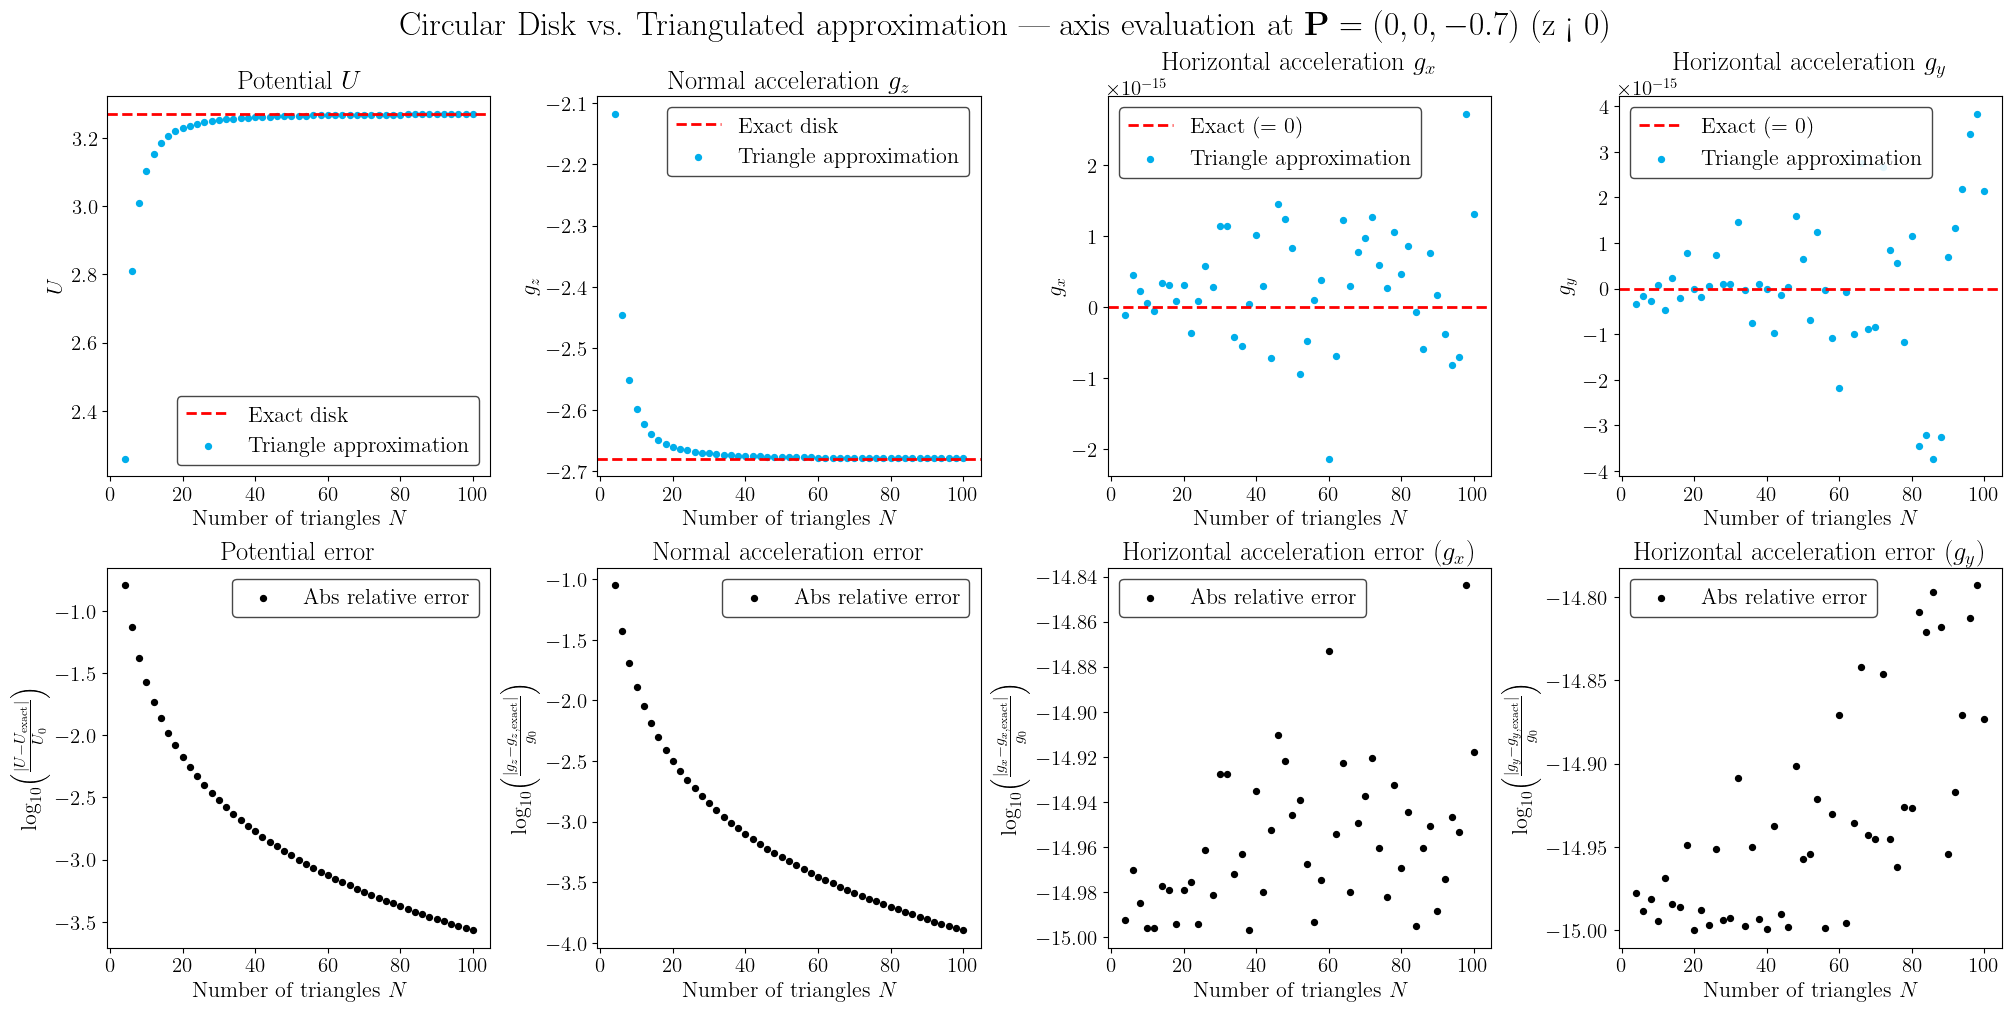

In [ ]:
# ============================================================
# VALIDATION 1: Disk vs Triangle fan (Triangle-only)
# Circular disk in z=0 approximated by N triangles.
# Convergence on symmetry axis at two points: z_above and z_below.
#
# Conventions:
# - Triangle_GP.py uses: g = ∇U  (NOT -∇U)
# - Here we keep the DISK acceleration with a NEGATIVE sign as requested:
#     U_exact  = 2πGσ (sqrt(R^2+z^2) - |z|)
#     g_z,exact = -2πGσ sign(z) ( |z|/sqrt(R^2+z^2) - 1 )
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation

# ------------------------------------------------------------
# Colors (requested)
# ------------------------------------------------------------
lb   = np.array([0, 174, 235]) / 255.0        # blue: triangle approximation
red  = "red"                                   # red: exact disk reference
orng = np.array([0, 0, 0]) / 255.0        # orange: error dots

# ------------------------------------------------------------
# Exact disk formulas on z-axis (MATCH Triangle_GP.py: g = ∇U)
# ------------------------------------------------------------
def U_disk_axis(z, R, G, sigma):
    z = np.asarray(z, dtype=float)
    return 2.0 * np.pi * G * sigma * (np.sqrt(R * R + z * z) - np.abs(z))

def gz_disk_axis(z, R, G, sigma):
    """
    Requested: keep NEGATIVE sign in disk acceleration.
    g_z = dU/dz = -2πGσ sign(z) ( |z|/sqrt(R^2+z^2) - 1 )
    """
    z = np.asarray(z, dtype=float)
    r = np.sqrt(R * R + z * z)
    s = np.sign(z)
    return -2.0 * np.pi * G * sigma * s * ((np.abs(z) / r) - 1.0)

# ------------------------------------------------------------
# Build disk triangles (fan): center + two neighboring rim points
# Orientation: (center, theta_k, theta_{k+1}) CCW => +z normal
# ------------------------------------------------------------
def build_disk_triangles(N, R, G, sigma, eps=0.0):
    center = np.array([0.0, 0.0, 0.0])
    thetas = np.linspace(0.0, 2.0 * np.pi, N + 1)  # N sectors, close loop

    tris = []
    for k in range(N):
        t0 = thetas[k]
        t1 = thetas[k + 1]
        v1 = np.array([R * np.cos(t0), R * np.sin(t0), 0.0])
        v2 = np.array([R * np.cos(t1), R * np.sin(t1), 0.0])
        verts = np.vstack([center, v1, v2])  # CCW => +z
        tris.append(TriangleLaminaGravitation(vertices=verts, G=G, sigma=sigma, eps=eps))
    return tris

# ------------------------------------------------------------
# Evaluate disk approx at P=(0,0,z) by summing triangles
# Returns: U, gx, gy, gz
# ------------------------------------------------------------
def disk_approx_from_triangles(z, tris):
    P = np.array([0.0, 0.0, float(z)], dtype=float)
    Usum = 0.0
    gsum = np.zeros(3, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        for tri in tris:
            Usum += tri.potential(P)
            gsum += tri.acceleration(P)

    return float(Usum), float(gsum[0]), float(gsum[1]), float(gsum[2])

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
G = 1.0
sigma = 1.0
R = 1.0

z_above = +0.7 * R
z_below = -0.7 * R

N_list = np.arange(4, 101, 2)  # 4,6,8,...,100

# Reference scales for relative errors (robust even when exact=0)
U_scale = 2.0 * np.pi * G * sigma * R   # characteristic potential scale
g_scale = 2.0 * np.pi * G * sigma       # characteristic acceleration scale
tiny = 1e-15

# ------------------------------------------------------------
# Run convergence for a given z
# ------------------------------------------------------------
def run_convergence(z0):
    U_exact  = U_disk_axis(z0, R, G, sigma)
    gx_exact = 0.0
    gy_exact = 0.0
    gz_exact = gz_disk_axis(z0, R, G, sigma)

    U_app  = np.zeros_like(N_list, dtype=float)
    gx_app = np.zeros_like(N_list, dtype=float)
    gy_app = np.zeros_like(N_list, dtype=float)
    gz_app = np.zeros_like(N_list, dtype=float)

    # absolute errors
    eU  = np.zeros_like(N_list, dtype=float)
    egx = np.zeros_like(N_list, dtype=float)
    egy = np.zeros_like(N_list, dtype=float)
    egz = np.zeros_like(N_list, dtype=float)

    for i, N in enumerate(N_list):
        tris = build_disk_triangles(int(N), R, G, sigma, eps=0.0)
        Un, gxn, gyn, gzn = disk_approx_from_triangles(z0, tris)

        U_app[i]  = Un
        gx_app[i] = gxn
        gy_app[i] = gyn
        gz_app[i] = gzn

        eU[i]  = np.abs(Un  - U_exact)
        egx[i] = np.abs(gxn - gx_exact)
        egy[i] = np.abs(gyn - gy_exact)
        egz[i] = np.abs(gzn - gz_exact)

    # absolute relative errors (use global scales to avoid division by 0)
    rU  = eU  / (np.abs(U_scale) + tiny)
    rgx = egx / (np.abs(g_scale) + tiny)
    rgy = egy / (np.abs(g_scale) + tiny)
    rgz = egz / (np.abs(g_scale) + tiny)

    # log10 absolute relative error for plotting
    log_rU  = np.log10(rU  + tiny)
    log_rgx = np.log10(rgx + tiny)
    log_rgy = np.log10(rgy + tiny)
    log_rgz = np.log10(rgz + tiny)

    exact_pair = (float(U_exact), float(gz_exact))
    approx_tuple = (U_app, gx_app, gy_app, gz_app)
    logrelerr_tuple = (log_rU, log_rgx, log_rgy, log_rgz)

    return exact_pair, approx_tuple, logrelerr_tuple

# ------------------------------------------------------------
# Compute for above and below points
# ------------------------------------------------------------
ex_above, app_above, relerr_above = run_convergence(z_above)
ex_below, app_below, relerr_below = run_convergence(z_below)

# ------------------------------------------------------------
# Plot one single figure (2×4) and save as PDF
# ------------------------------------------------------------
def plot_one_figure(z0, exact_pair, approx_tuple, logrelerr_tuple, title_tag, pdf_name):
    z0 = float(np.asarray(z0).ravel()[0])

    U_exact, gz_exact = exact_pair
    U_app, gx_app, gy_app, gz_app = approx_tuple
    log_rU, log_rgx, log_rgy, log_rgz = logrelerr_tuple

    # Boxed legends placed so they do not cover points
    LEGEND_KW = dict(frameon=True, fancybox=True, framealpha=0.9, edgecolor="0.2")

    fig, axs = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)

    # ---------------------------
    # Top row: values
    # ---------------------------
    axs[0, 0].axhline(U_exact, color=red, linestyle="--", linewidth=2, label="Exact disk")
    axs[0, 0].scatter(N_list, U_app, s=18, color=lb, label="Triangle approximation")
    axs[0, 0].set_title(r"Potential $U$")
    axs[0, 0].set_xlabel(r"Number of triangles $N$")
    axs[0, 0].set_ylabel(r"$U$")
    axs[0, 0].legend(loc="best", **LEGEND_KW)

    axs[0, 1].axhline(gz_exact, color=red, linestyle="--", linewidth=2, label="Exact disk")
    axs[0, 1].scatter(N_list, gz_app, s=18, color=lb, label="Triangle approximation")
    axs[0, 1].set_title(r"Normal acceleration $g_z$")
    axs[0, 1].set_xlabel(r"Number of triangles $N$")
    axs[0, 1].set_ylabel(r"$g_z$")
    axs[0, 1].legend(loc="best", **LEGEND_KW)

    axs[0, 2].axhline(0.0, color=red, linestyle="--", linewidth=2, label=r"Exact ($=0$)")
    axs[0, 2].scatter(N_list, gx_app, s=18, color=lb, label="Triangle approximation")
    axs[0, 2].set_title(r"Horizontal acceleration $g_x$")
    axs[0, 2].set_xlabel(r"Number of triangles $N$")
    axs[0, 2].set_ylabel(r"$g_x$")
    axs[0, 2].legend(loc="best", **LEGEND_KW)

    axs[0, 3].axhline(0.0, color=red, linestyle="--", linewidth=2, label=r"Exact ($=0$)")
    axs[0, 3].scatter(N_list, gy_app, s=18, color=lb, label="Triangle approximation")
    axs[0, 3].set_title(r"Horizontal acceleration $g_y$")
    axs[0, 3].set_xlabel(r"Number of triangles $N$")
    axs[0, 3].set_ylabel(r"$g_y$")
    axs[0, 3].legend(loc="best", **LEGEND_KW)

    # ---------------------------
    # Bottom row: log10 absolute relative errors (y-axis shows relative error)
    # ---------------------------
    axs[1, 0].scatter(N_list, log_rU,  s=18, color=orng, label="Abs relative error")
    axs[1, 0].set_title(r"Potential error")
    axs[1, 0].set_xlabel(r"Number of triangles $N$")
    axs[1, 0].set_ylabel(r"$\log_{10}\!\left(\frac{|U-U_{\mathrm{exact}}|}{U_0}\right)$")
    axs[1, 0].legend(loc="best", **LEGEND_KW)

    axs[1, 1].scatter(N_list, log_rgz, s=18, color=orng, label="Abs relative error")
    axs[1, 1].set_title(r"Normal acceleration error")
    axs[1, 1].set_xlabel(r"Number of triangles $N$")
    axs[1, 1].set_ylabel(r"$\log_{10}\!\left(\frac{|g_z-g_{z,\mathrm{exact}}|}{g_0}\right)$")
    axs[1, 1].legend(loc="best", **LEGEND_KW)

    axs[1, 2].scatter(N_list, log_rgx, s=18, color=orng, label="Abs relative error")
    axs[1, 2].set_title(r"Horizontal acceleration error ($g_x$)")
    axs[1, 2].set_xlabel(r"Number of triangles $N$")
    axs[1, 2].set_ylabel(r"$\log_{10}\!\left(\frac{|g_x-g_{x,\mathrm{exact}}|}{g_0}\right)$")
    axs[1, 2].legend(loc="best", **LEGEND_KW)

    axs[1, 3].scatter(N_list, log_rgy, s=18, color=orng, label="Abs relative error")
    axs[1, 3].set_title(r"Horizontal acceleration error ($g_y$)")
    axs[1, 3].set_xlabel(r"Number of triangles $N$")
    axs[1, 3].set_ylabel(r"$\log_{10}\!\left(\frac{|g_y-g_{y,\mathrm{exact}}|}{g_0}\right)$")
    axs[1, 3].legend(loc="best", **LEGEND_KW)

    # ---------------------------
    # Global manuscript-style title
    # ---------------------------
    fig.suptitle(
        f"Circular Disk vs. Triangulated approximation — axis evaluation at $\\mathbf{{P}}=(0,0,{z0:.3g})$ ({title_tag})",
        fontsize=24
    )

    # Save as PDF
    fig.savefig(pdf_name, format="pdf", bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# Produce figures + save PDFs
# ------------------------------------------------------------
plot_one_figure(
    z_above, ex_above, app_above, relerr_above,
    title_tag="z > 0", pdf_name="Validation_Disk_vs_Triangles_zAbove.pdf"
)

plot_one_figure(
    z_below, ex_below, app_below, relerr_below,
    title_tag="z < 0", pdf_name="Validation_Disk_vs_Triangles_zBelow.pdf"
)


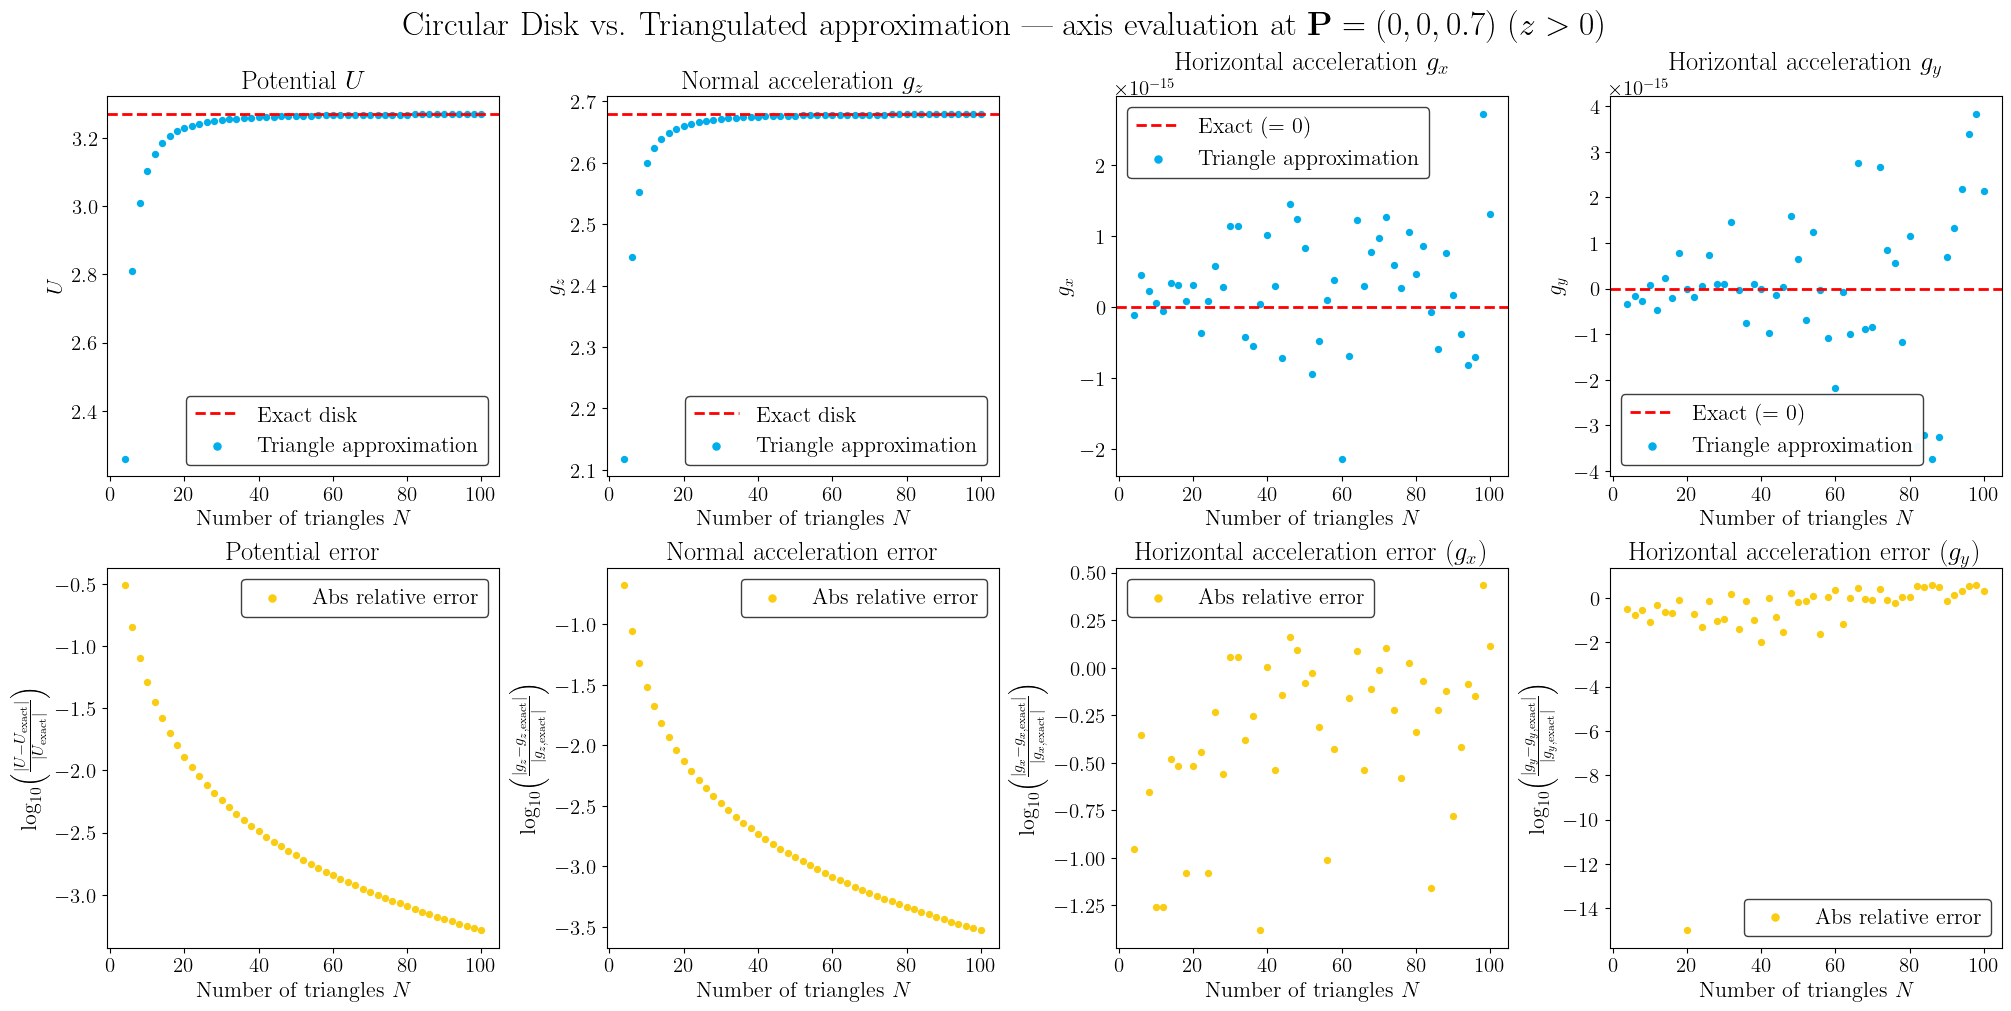

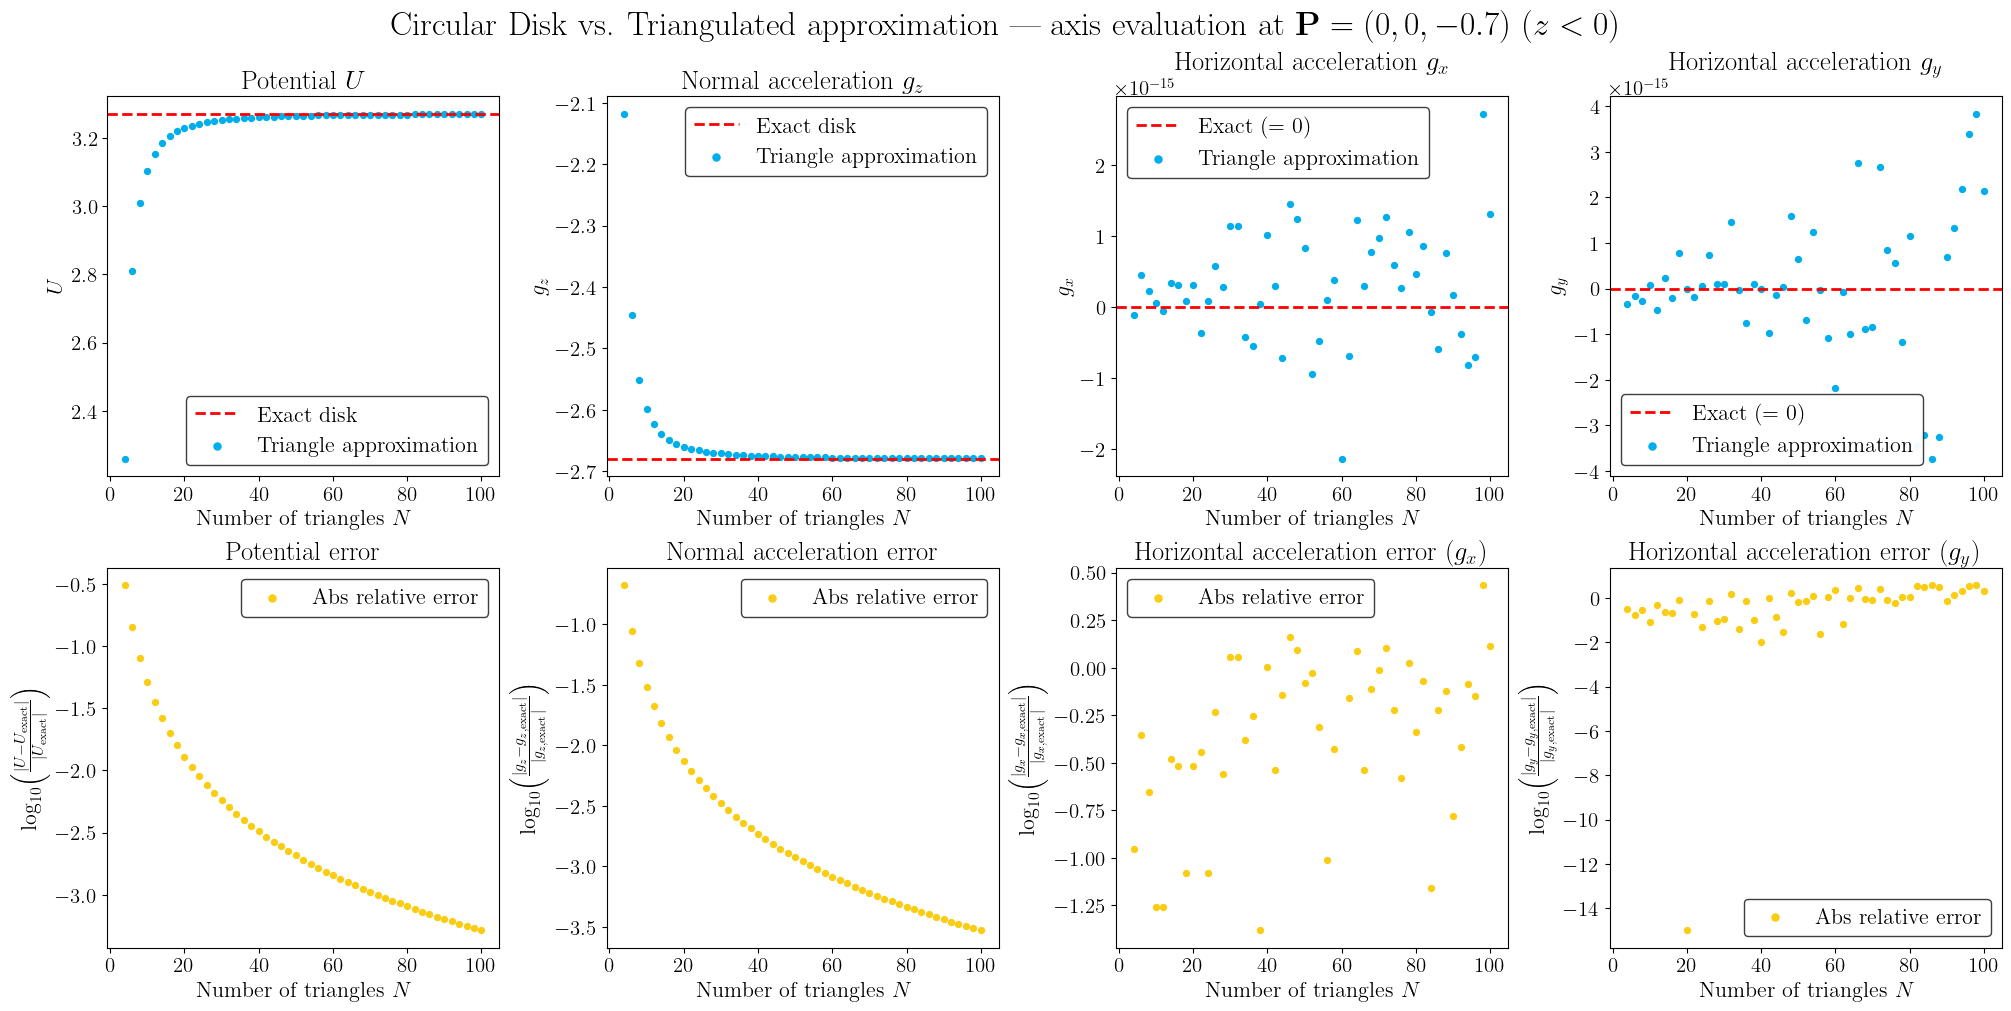

In [19]:
# ============================================================
# VALIDATION 1: Disk vs Triangle fan (Triangle-only)
# Circular disk in z=0 approximated by N triangles.
# Convergence on symmetry axis at two points: z_above and z_below.
#
# IMPORTANT conventions:
# - Triangle_GP.py uses: g = ∇U  (NOT -∇U)
# - Per your instruction: keep the DISK acceleration with a NEGATIVE sign:
#     U_exact  = 2πGσ (sqrt(R^2+z^2) - |z|)
#     g_z,exact = -2πGσ sign(z) ( |z|/sqrt(R^2+z^2) - 1 )
#
# ERROR DEFINITION (as you requested):
#   log10( |exact - approx| / |exact| )
# i.e. pointwise absolute relative error with the EXACT DISK value in the denominator.
#
# NOTE (mathematical reality):
# - On the symmetry axis, g_x,exact = g_y,exact = 0, so the relative error is undefined.
# - To keep the code running, we use |exact| + tiny in the denominator; this will
#   produce very large values for g_x and g_y (because exact=0).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation

# ------------------------------------------------------------
# Colors (requested)
# ------------------------------------------------------------
lb   = np.array([0, 174, 235]) / 255.0        # blue: triangle approximation
red  = "red"                                   # red: exact disk reference
orng = np.array([250, 204, 18]) / 255.0        # orange: error dots

tiny = 1e-15  # used to avoid division by zero in relative error

# ------------------------------------------------------------
# Exact disk formulas on z-axis (MATCH Triangle_GP.py: g = ∇U)
# ------------------------------------------------------------
def U_disk_axis(z, R, G, sigma):
    z = np.asarray(z, dtype=float)
    return 2.0 * np.pi * G * sigma * (np.sqrt(R * R + z * z) - np.abs(z))

def gz_disk_axis(z, R, G, sigma):
    """
    Requested: keep NEGATIVE sign in disk acceleration.
    g_z = dU/dz = -2πGσ sign(z) ( |z|/sqrt(R^2+z^2) - 1 )
    """
    z = np.asarray(z, dtype=float)
    r = np.sqrt(R * R + z * z)
    s = np.sign(z)
    return -2.0 * np.pi * G * sigma * s * ((np.abs(z) / r) - 1.0)

# ------------------------------------------------------------
# Build disk triangles (fan): center + two neighboring rim points
# Orientation: (center, theta_k, theta_{k+1}) CCW => +z normal
# ------------------------------------------------------------
def build_disk_triangles(N, R, G, sigma, eps=0.0):
    center = np.array([0.0, 0.0, 0.0])
    thetas = np.linspace(0.0, 2.0 * np.pi, N + 1)  # N sectors, close loop

    tris = []
    for k in range(N):
        t0 = thetas[k]
        t1 = thetas[k + 1]
        v1 = np.array([R * np.cos(t0), R * np.sin(t0), 0.0])
        v2 = np.array([R * np.cos(t1), R * np.sin(t1), 0.0])
        verts = np.vstack([center, v1, v2])  # CCW => +z
        tris.append(TriangleLaminaGravitation(vertices=verts, G=G, sigma=sigma, eps=eps))
    return tris

# ------------------------------------------------------------
# Evaluate disk approx at P=(0,0,z) by summing triangles
# Returns: U, gx, gy, gz
# ------------------------------------------------------------
def disk_approx_from_triangles(z, tris):
    P = np.array([0.0, 0.0, float(z)], dtype=float)
    Usum = 0.0
    gsum = np.zeros(3, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        for tri in tris:
            Usum += tri.potential(P)
            gsum += tri.acceleration(P)

    return float(Usum), float(gsum[0]), float(gsum[1]), float(gsum[2])

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
G = 1.0
sigma = 1.0
R = 1.0

z_above = +0.7 * R
z_below = -0.7 * R

N_list = np.arange(4, 101, 2)  # 4,6,8,...,100

# ------------------------------------------------------------
# Run convergence for a given z
# ------------------------------------------------------------
def run_convergence(z0):
    U_exact  = float(U_disk_axis(z0, R, G, sigma))
    gx_exact = 0.0
    gy_exact = 0.0
    gz_exact = float(gz_disk_axis(z0, R, G, sigma))

    U_app  = np.zeros_like(N_list, dtype=float)
    gx_app = np.zeros_like(N_list, dtype=float)
    gy_app = np.zeros_like(N_list, dtype=float)
    gz_app = np.zeros_like(N_list, dtype=float)

    # absolute errors
    eU  = np.zeros_like(N_list, dtype=float)
    egx = np.zeros_like(N_list, dtype=float)
    egy = np.zeros_like(N_list, dtype=float)
    egz = np.zeros_like(N_list, dtype=float)

    for i, N in enumerate(N_list):
        tris = build_disk_triangles(int(N), R, G, sigma, eps=0.0)
        Un, gxn, gyn, gzn = disk_approx_from_triangles(z0, tris)

        U_app[i]  = Un
        gx_app[i] = gxn
        gy_app[i] = gyn
        gz_app[i] = gzn

        eU[i]  = np.abs(Un  - U_exact)
        egx[i] = np.abs(gxn - gx_exact)
        egy[i] = np.abs(gyn - gy_exact)
        egz[i] = np.abs(gzn - gz_exact)

    # -------------------------
    # Your requested relative error:
    # log10( |exact - approx| / |exact| )
    # -------------------------
    rU  = eU  / (np.abs(U_exact)  + tiny)
    rgx = egx / (np.abs(gx_exact) + tiny)   # gx_exact = 0 on axis -> huge by design
    rgy = egy / (np.abs(gy_exact) + tiny)   # gy_exact = 0 on axis -> huge by design
    rgz = egz / (np.abs(gz_exact) + tiny)

    log_rU  = np.log10(rU  + tiny)
    log_rgx = np.log10(rgx + tiny)
    log_rgy = np.log10(rgy + tiny)
    log_rgz = np.log10(rgz + tiny)

    exact_pair = (U_exact, gz_exact)
    approx_tuple = (U_app, gx_app, gy_app, gz_app)
    logrelerr_tuple = (log_rU, log_rgx, log_rgy, log_rgz)

    return exact_pair, approx_tuple, logrelerr_tuple

# ------------------------------------------------------------
# Compute for above and below points
# ------------------------------------------------------------
ex_above, app_above, relerr_above = run_convergence(z_above)
ex_below, app_below, relerr_below = run_convergence(z_below)

# ------------------------------------------------------------
# Plot one single figure (2×4) and save as PDF
# ------------------------------------------------------------
def plot_one_figure(z0, exact_pair, approx_tuple, logrelerr_tuple, title_tag, pdf_name):
    z0 = float(np.asarray(z0).ravel()[0])

    U_exact, gz_exact = exact_pair
    U_app, gx_app, gy_app, gz_app = approx_tuple
    log_rU, log_rgx, log_rgy, log_rgz = logrelerr_tuple

    LEGEND_KW = dict(
        loc="best",
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        edgecolor="0.2",
        markerscale=1.2
    )

    fig, axs = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)

    # ---------------------------
    # Top row: values
    # ---------------------------
    axs[0, 0].axhline(U_exact, color=red, linestyle="--", linewidth=2, label="Exact disk")
    axs[0, 0].scatter(N_list, U_app, s=18, color=lb, label="Triangle approximation")
    axs[0, 0].set_title(r"Potential $U$")
    axs[0, 0].set_xlabel(r"Number of triangles $N$")
    axs[0, 0].set_ylabel(r"$U$")
    axs[0, 0].legend(**LEGEND_KW)

    axs[0, 1].axhline(gz_exact, color=red, linestyle="--", linewidth=2, label="Exact disk")
    axs[0, 1].scatter(N_list, gz_app, s=18, color=lb, label="Triangle approximation")
    axs[0, 1].set_title(r"Normal acceleration $g_z$")
    axs[0, 1].set_xlabel(r"Number of triangles $N$")
    axs[0, 1].set_ylabel(r"$g_z$")
    axs[0, 1].legend(**LEGEND_KW)

    axs[0, 2].axhline(0.0, color=red, linestyle="--", linewidth=2, label=r"Exact ($=0$)")
    axs[0, 2].scatter(N_list, gx_app, s=18, color=lb, label="Triangle approximation")
    axs[0, 2].set_title(r"Horizontal acceleration $g_x$")
    axs[0, 2].set_xlabel(r"Number of triangles $N$")
    axs[0, 2].set_ylabel(r"$g_x$")
    axs[0, 2].legend(**LEGEND_KW)

    axs[0, 3].axhline(0.0, color=red, linestyle="--", linewidth=2, label=r"Exact ($=0$)")
    axs[0, 3].scatter(N_list, gy_app, s=18, color=lb, label="Triangle approximation")
    axs[0, 3].set_title(r"Horizontal acceleration $g_y$")
    axs[0, 3].set_xlabel(r"Number of triangles $N$")
    axs[0, 3].set_ylabel(r"$g_y$")
    axs[0, 3].legend(**LEGEND_KW)

    # ---------------------------
    # Bottom row: log10 absolute relative errors (your formula)
    # ---------------------------
    axs[1, 0].scatter(N_list, log_rU,  s=18, color=orng, label="Abs relative error")
    axs[1, 0].set_title(r"Potential error")
    axs[1, 0].set_xlabel(r"Number of triangles $N$")
    axs[1, 0].set_ylabel(r"$\log_{10}\!\left(\frac{|U-U_{\mathrm{exact}}|}{|U_{\mathrm{exact}}|}\right)$")
    axs[1, 0].legend(**LEGEND_KW)

    axs[1, 1].scatter(N_list, log_rgz, s=18, color=orng, label="Abs relative error")
    axs[1, 1].set_title(r"Normal acceleration error")
    axs[1, 1].set_xlabel(r"Number of triangles $N$")
    axs[1, 1].set_ylabel(r"$\log_{10}\!\left(\frac{|g_z-g_{z,\mathrm{exact}}|}{|g_{z,\mathrm{exact}}|}\right)$")
    axs[1, 1].legend(**LEGEND_KW)

    axs[1, 2].scatter(N_list, log_rgx, s=18, color=orng, label="Abs relative error")
    axs[1, 2].set_title(r"Horizontal acceleration error ($g_x$)")
    axs[1, 2].set_xlabel(r"Number of triangles $N$")
    axs[1, 2].set_ylabel(r"$\log_{10}\!\left(\frac{|g_x-g_{x,\mathrm{exact}}|}{|g_{x,\mathrm{exact}}|}\right)$")
    axs[1, 2].legend(**LEGEND_KW)

    axs[1, 3].scatter(N_list, log_rgy, s=18, color=orng, label="Abs relative error")
    axs[1, 3].set_title(r"Horizontal acceleration error ($g_y$)")
    axs[1, 3].set_xlabel(r"Number of triangles $N$")
    axs[1, 3].set_ylabel(r"$\log_{10}\!\left(\frac{|g_y-g_{y,\mathrm{exact}}|}{|g_{y,\mathrm{exact}}|}\right)$")
    axs[1, 3].legend(**LEGEND_KW)

    fig.suptitle(
        f"Circular Disk vs. Triangulated approximation — axis evaluation at $\\mathbf{{P}}=(0,0,{z0:.3g})$ ({title_tag})",
        fontsize=24
    )

    fig.savefig(pdf_name, format="pdf", bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# Produce figures + save PDFs
# ------------------------------------------------------------
plot_one_figure(
    z_above, ex_above, app_above, relerr_above,
    title_tag=r"$z>0$", pdf_name="Validation_Disk_vs_Triangles_zAbove.pdf"
)

plot_one_figure(
    z_below, ex_below, app_below, relerr_below,
    title_tag=r"$z<0$", pdf_name="Validation_Disk_vs_Triangles_zBelow.pdf"
)


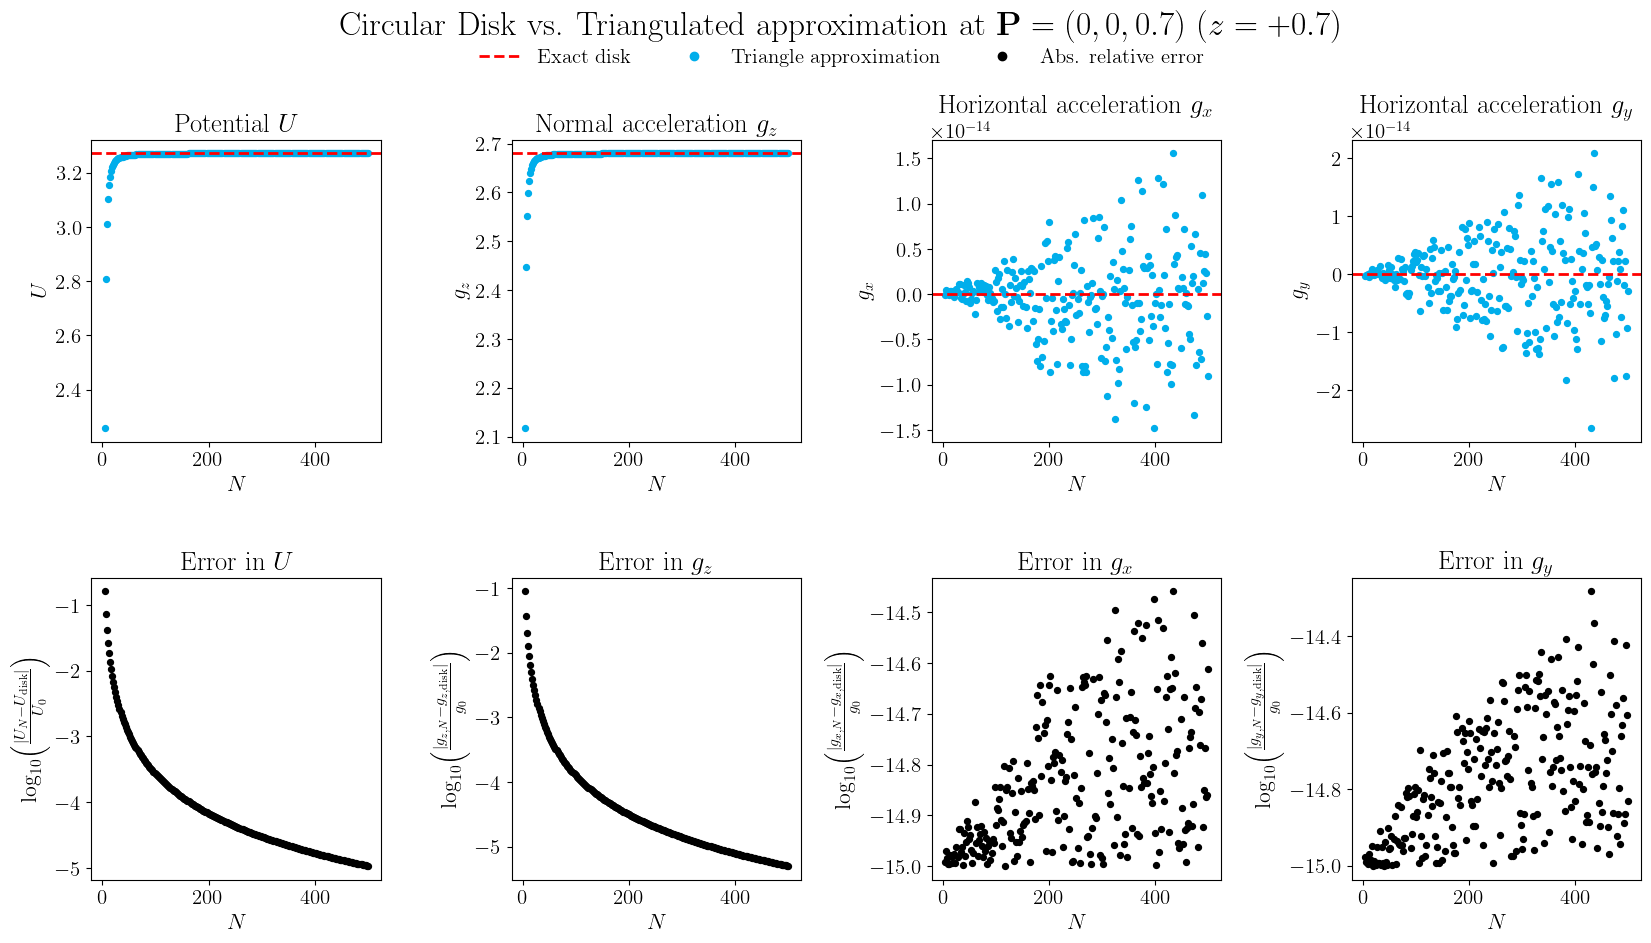

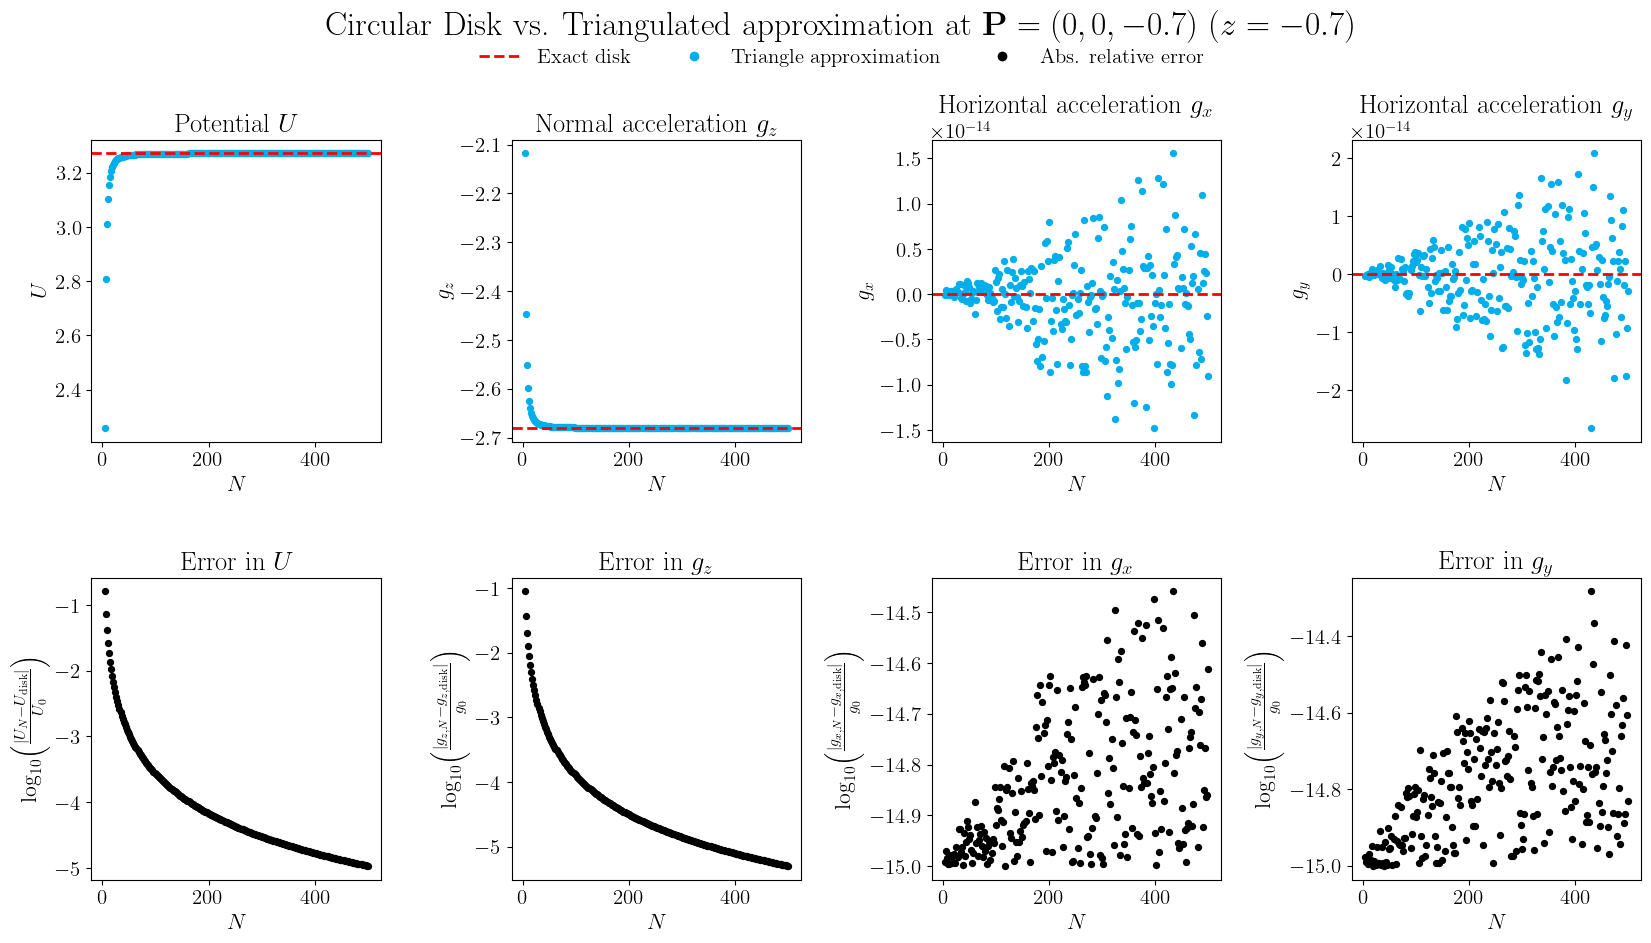

In [ ]:
# ============================================================
# VALIDATION I: Disk vs Triangle fan (Triangle-only)
# Disk in z=0 approximated by N triangles (fan triangulation).
# Evaluate on symmetry axis at z = +0.7R and z = -0.7R.
#
# Conventions:
# - Triangle_GP.py uses: g = ∇U
# - Disk reference uses NEGATIVE sign for gz (as you requested):
#     U_exact  = 2πGσ (sqrt(R^2+z^2) - |z|)
#     gz_exact = -2πGσ sign(z) ( |z|/sqrt(R^2+z^2) - 1 )
#
# Error metric (your preferred, stable version):
# - Use global scales to avoid division by zero:
#     U_scale = 2πGσR,  g_scale = 2πGσ
# - Plot log10 absolute relative (scaled) error:
#     log10( |approx - exact| / scale )
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation

# ------------------------------------------------------------
# Colors (requested)
# ------------------------------------------------------------
lb   = np.array([0, 174, 235]) / 255.0        # blue: triangle approximation
red  = "red"                                   # red: exact disk reference
orng = np.array([0, 0, 0]) / 255.0        # orange: error dots

tiny = 1e-15

# ------------------------------------------------------------
# Exact disk formulas on z-axis (MATCH Triangle_GP.py: g = ∇U)
# ------------------------------------------------------------
def U_disk_axis(z, R, G, sigma):
    z = np.asarray(z, dtype=float)
    return 2.0 * np.pi * G * sigma * (np.sqrt(R * R + z * z) - np.abs(z))

def gz_disk_axis(z, R, G, sigma):
    """
    Requested: keep NEGATIVE sign in disk acceleration.
    gz = dU/dz = -2πGσ sign(z) ( |z|/sqrt(R^2+z^2) - 1 )
    """
    z = np.asarray(z, dtype=float)
    r = np.sqrt(R * R + z * z)
    s = np.sign(z)
    return -2.0 * np.pi * G * sigma * s * ((np.abs(z) / r) - 1.0)

# ------------------------------------------------------------
# Build disk triangles (fan): center + two neighboring rim points
# Orientation: (center, theta_k, theta_{k+1}) CCW => +z normal
# ------------------------------------------------------------
def build_disk_triangles(N, R, G, sigma, eps=0.0):
    center = np.array([0.0, 0.0, 0.0])
    thetas = np.linspace(0.0, 2.0 * np.pi, N + 1)  # close loop

    tris = []
    for k in range(N):
        t0 = thetas[k]
        t1 = thetas[k + 1]
        v1 = np.array([R * np.cos(t0), R * np.sin(t0), 0.0])
        v2 = np.array([R * np.cos(t1), R * np.sin(t1), 0.0])

        verts = np.vstack([center, v1, v2])  # CCW => +z
        tris.append(TriangleLaminaGravitation(vertices=verts, G=G, sigma=sigma, eps=eps))
    return tris

# ------------------------------------------------------------
# Evaluate disk approx at P=(0,0,z) by summing triangles
# Returns: U, gx, gy, gz
# ------------------------------------------------------------
def disk_approx_from_triangles(z, tris):
    P = np.array([0.0, 0.0, float(z)], dtype=float)
    Usum = 0.0
    gsum = np.zeros(3, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        for tri in tris:
            Usum += tri.potential(P)
            gsum += tri.acceleration(P)

    return float(Usum), float(gsum[0]), float(gsum[1]), float(gsum[2])

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
G = 1.0
sigma = 1.0
R = 1.0

z_above = +0.7 * R
z_below = -0.7 * R

N_list = np.arange(4, 501, 2)  # 4,6,...,100

# Global characteristic scales (as in your preferred code)
U_scale = 2.0 * np.pi * G * sigma * R
g_scale = 2.0 * np.pi * G * sigma

# ------------------------------------------------------------
# Run convergence for a given z (your preferred stable relative error)
# ------------------------------------------------------------
def run_convergence(z0):
    U_exact  = float(U_disk_axis(z0, R, G, sigma))
    gx_exact = 0.0
    gy_exact = 0.0
    gz_exact = float(gz_disk_axis(z0, R, G, sigma))

    U_app  = np.zeros_like(N_list, dtype=float)
    gx_app = np.zeros_like(N_list, dtype=float)
    gy_app = np.zeros_like(N_list, dtype=float)
    gz_app = np.zeros_like(N_list, dtype=float)

    # absolute errors
    eU  = np.zeros_like(N_list, dtype=float)
    egx = np.zeros_like(N_list, dtype=float)
    egy = np.zeros_like(N_list, dtype=float)
    egz = np.zeros_like(N_list, dtype=float)

    for i, N in enumerate(N_list):
        tris = build_disk_triangles(int(N), R, G, sigma, eps=0.0)
        Un, gxn, gyn, gzn = disk_approx_from_triangles(z0, tris)

        U_app[i]  = Un
        gx_app[i] = gxn
        gy_app[i] = gyn
        gz_app[i] = gzn

        eU[i]  = np.abs(Un  - U_exact)
        egx[i] = np.abs(gxn - gx_exact)
        egy[i] = np.abs(gyn - gy_exact)
        egz[i] = np.abs(gzn - gz_exact)

    # absolute relative errors (use global scales to avoid division by 0)
    rU  = eU  / (np.abs(U_scale) + tiny)
    rgx = egx / (np.abs(g_scale) + tiny)
    rgy = egy / (np.abs(g_scale) + tiny)
    rgz = egz / (np.abs(g_scale) + tiny)

    # log10 absolute relative error for plotting
    log_rU  = np.log10(rU  + tiny)
    log_rgx = np.log10(rgx + tiny)
    log_rgy = np.log10(rgy + tiny)
    log_rgz = np.log10(rgz + tiny)

    exact = dict(U=U_exact, gx=gx_exact, gy=gy_exact, gz=gz_exact)
    approx = dict(U=U_app, gx=gx_app, gy=gy_app, gz=gz_app)
    logerr = dict(U=log_rU, gx=log_rgx, gy=log_rgy, gz=log_rgz)

    return exact, approx, logerr

# ------------------------------------------------------------
# Plot one clean 2×4 figure with ONE global legend (Option 2)
# ------------------------------------------------------------
def plot_validation_2x4(z0, exact, approx, logerr, tag, pdf_name):
    z0 = float(z0)

    # Create figure (avoid constrained_layout so we can reserve top room cleanly)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(
        rf"Circular Disk vs. Triangulated approximation at $\mathbf{{P}}=(0,0,{z0:.3g})$ ({tag})",
        fontsize=24,
        y=0.98
    )

    # ---------------------------
    # Top row: values
    # ---------------------------
    # U
    axs[0, 0].axhline(exact["U"], color=red, linestyle="--", linewidth=2, label="Exact disk")
    axs[0, 0].scatter(N_list, approx["U"], s=18, color=lb, label="Triangle approximation")
    axs[0, 0].set_title(r"Potential $U$")
    axs[0, 0].set_xlabel(r"$N$")
    axs[0, 0].set_ylabel(r"$U$")

    # gz
    axs[0, 1].axhline(exact["gz"], color=red, linestyle="--", linewidth=2, label="Exact disk")
    axs[0, 1].scatter(N_list, approx["gz"], s=18, color=lb, label="Triangle approximation")
    axs[0, 1].set_title(r"Normal acceleration $g_z$")
    axs[0, 1].set_xlabel(r"$N$")
    axs[0, 1].set_ylabel(r"$g_z$")

    # gx
    axs[0, 2].axhline(0.0, color=red, linestyle="--", linewidth=2, label=r"Exact ($=0$)")
    axs[0, 2].scatter(N_list, approx["gx"], s=18, color=lb, label="Triangle approximation")
    axs[0, 2].set_title(r"Horizontal acceleration $g_x$")
    axs[0, 2].set_xlabel(r"$N$")
    axs[0, 2].set_ylabel(r"$g_x$")

    # gy
    axs[0, 3].axhline(0.0, color=red, linestyle="--", linewidth=2, label=r"Exact ($=0$)")
    axs[0, 3].scatter(N_list, approx["gy"], s=18, color=lb, label="Triangle approximation")
    axs[0, 3].set_title(r"Horizontal acceleration $g_y$")
    axs[0, 3].set_xlabel(r"$N$")
    axs[0, 3].set_ylabel(r"$g_y$")

    # ---------------------------
    # Bottom row: error (log10 scaled abs relative error)
    # ---------------------------
    axs[1, 0].scatter(N_list, logerr["U"], s=18, color=orng, label="Abs relative error")
    axs[1, 0].set_title(r"Error in $U$")
    axs[1, 0].set_xlabel(r"$N$")
    axs[1, 0].set_ylabel(r"$\log_{10}\!\left(\frac{|U_N-U_{\mathrm{disk}}|}{U_0}\right)$")

    axs[1, 1].scatter(N_list, logerr["gz"], s=18, color=orng, label="Abs relative error")
    axs[1, 1].set_title(r"Error in $g_z$")
    axs[1, 1].set_xlabel(r"$N$")
    axs[1, 1].set_ylabel(r"$\log_{10}\!\left(\frac{|g_{z,N}-g_{z,\mathrm{disk}}|}{g_0}\right)$")

    axs[1, 2].scatter(N_list, logerr["gx"], s=18, color=orng, label="Abs relative error")
    axs[1, 2].set_title(r"Error in $g_x$")
    axs[1, 2].set_xlabel(r"$N$")
    axs[1, 2].set_ylabel(r"$\log_{10}\!\left(\frac{|g_{x,N}-g_{x,\mathrm{disk}}|}{g_0}\right)$")

    axs[1, 3].scatter(N_list, logerr["gy"], s=18, color=orng, label="Abs relative error")
    axs[1, 3].set_title(r"Error in $g_y$")
    axs[1, 3].set_xlabel(r"$N$")
    axs[1, 3].set_ylabel(r"$\log_{10}\!\left(\frac{|g_{y,N}-g_{y,\mathrm{disk}}|}{g_0}\right)$")

    # ---------------------------
    # ONE global legend (Option 2)
    # Collect handles from a few axes to ensure all entries included
    # ---------------------------
    handles, labels = [], []
    for ax in (axs[0, 0], axs[0, 2], axs[1, 0]):
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh)
                labels.append(ll)
    
    from matplotlib.lines import Line2D

    legend_handles = [
        Line2D([0], [0], color=red, linestyle="--", linewidth=2,
            label="Exact disk"),
        Line2D([0], [0], marker="o", linestyle="None", markersize=6,
            markerfacecolor=lb, markeredgecolor=lb,
            label="Triangle approximation"),
        Line2D([0], [0], marker="o", linestyle="None", markersize=6,
            markerfacecolor=orng, markeredgecolor=orng,
            label="Abs. relative error"),]


    fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),  # move legend slightly up
    ncol=3,
    frameon=False,               # no box
    fontsize=15)


    # Leave room for legend + suptitle
    fig.subplots_adjust(top=0.85, wspace=0.45, hspace=0.45)

    # Save and show
    fig.savefig(pdf_name, format="pdf", bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# Run + plot (above and below)
# ------------------------------------------------------------
exact_above, approx_above, logerr_above = run_convergence(z_above)
exact_below, approx_below, logerr_below = run_convergence(z_below)

plot_validation_2x4(
    z_above, exact_above, approx_above, logerr_above,
    tag=r"$z=+0.7$", pdf_name="Validation_I_Disk_vs_Triangles_Above.pdf"
)

plot_validation_2x4(
    z_below, exact_below, approx_below, logerr_below,
    tag=r"$z=-0.7$", pdf_name="Validation_I_Disk_vs_Triangles_Below.pdf"
)


#### Test 09

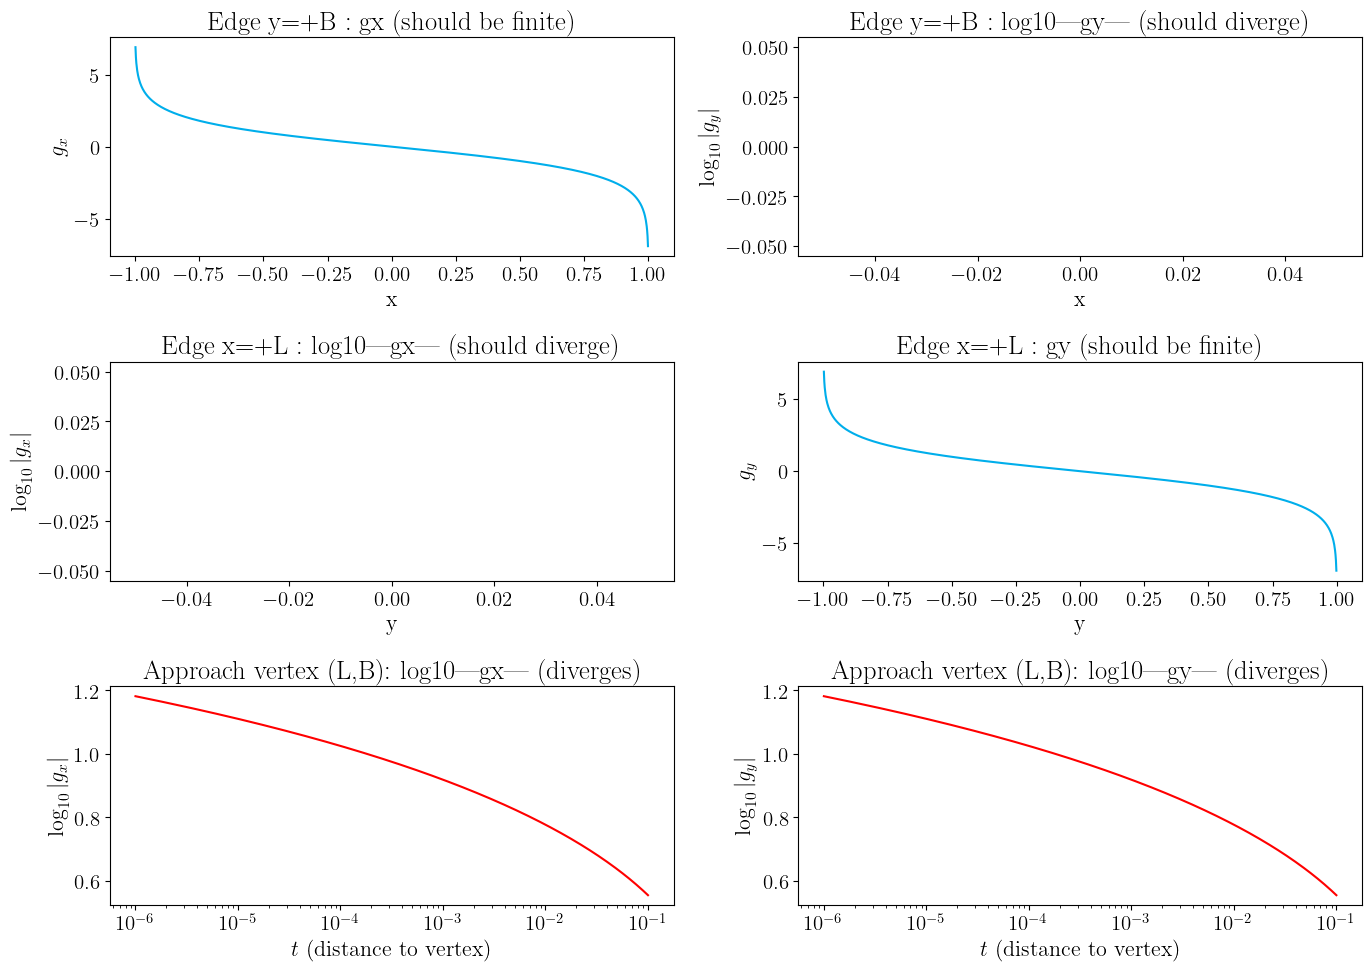

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
)

# -----------------------------
# Parameters
# -----------------------------
G = 1.0
sigma = 1.0
L = 1.0
B = 1.0

lb = np.array([0, 174, 235]) / 255.0
red = "red"

# -----------------------------
# Helpers
# -----------------------------
def gx(x, y):
    return gravitational_gx_rectangle(x, y, 0.0, L, B, sigma, G=G)

def gy(x, y):
    return gravitational_gy_rectangle(x, y, 0.0, L, B, sigma, G=G)

def safe_log10_abs(a):
    a = np.asarray(a, float)
    return np.log10(np.abs(a) + 1e-300)

# -----------------------------
# 1) Along edge parallel to x-axis: y = +B
# Expect: gy singular, gx finite
# -----------------------------
x1 = np.linspace(-L, L, 1201)
y1 = np.full_like(x1, +B)

gx1 = np.array([gx(x, y) for x, y in zip(x1, y1)])
gy1 = np.array([gy(x, y) for x, y in zip(x1, y1)])

# -----------------------------
# 2) Along edge parallel to y-axis: x = +L
# Expect: gx singular, gy finite
# -----------------------------
y2 = np.linspace(-B, B, 1201)
x2 = np.full_like(y2, +L)

gx2 = np.array([gx(x, y) for x, y in zip(x2, y2)])
gy2 = np.array([gy(x, y) for x, y in zip(x2, y2)])

# -----------------------------
# 3) Approach a vertex: (L,B) along diagonal
# Expect: gx and gy both singular
# -----------------------------
# Approach from inside: (x,y) = (L - t, B - t), t->0+
t = np.logspace(-6, -1, 300)
x3 = L - t
y3 = B - t

gx3 = np.array([gx(x, y) for x, y in zip(x3, y3)])
gy3 = np.array([gy(x, y) for x, y in zip(x3, y3)])

# -----------------------------
# Plots
# -----------------------------
fig, axs = plt.subplots(3, 2, figsize=(14, 10))

# Edge y=+B
axs[0, 0].plot(x1, gx1, color=lb)
axs[0, 0].set_title("Edge y=+B : gx (should be finite)")
axs[0, 0].set_xlabel("x")
axs[0, 0].set_ylabel(r"$g_x$")

axs[0, 1].plot(x1, safe_log10_abs(gy1), color=red)
axs[0, 1].set_title("Edge y=+B : log10|gy| (should diverge)")
axs[0, 1].set_xlabel("x")
axs[0, 1].set_ylabel(r"$\log_{10}|g_y|$")

# Edge x=+L
axs[1, 0].plot(y2, safe_log10_abs(gx2), color=red)
axs[1, 0].set_title("Edge x=+L : log10|gx| (should diverge)")
axs[1, 0].set_xlabel("y")
axs[1, 0].set_ylabel(r"$\log_{10}|g_x|$")

axs[1, 1].plot(y2, gy2, color=lb)
axs[1, 1].set_title("Edge x=+L : gy (should be finite)")
axs[1, 1].set_xlabel("y")
axs[1, 1].set_ylabel(r"$g_y$")

# Vertex approach
axs[2, 0].plot(t, safe_log10_abs(gx3), color=red)
axs[2, 0].set_xscale("log")
axs[2, 0].set_title("Approach vertex (L,B): log10|gx| (diverges)")
axs[2, 0].set_xlabel(r"$t$ (distance to vertex)")
axs[2, 0].set_ylabel(r"$\log_{10}|g_x|$")

axs[2, 1].plot(t, safe_log10_abs(gy3), color=red)
axs[2, 1].set_xscale("log")
axs[2, 1].set_title("Approach vertex (L,B): log10|gy| (diverges)")
axs[2, 1].set_xlabel(r"$t$ (distance to vertex)")
axs[2, 1].set_ylabel(r"$\log_{10}|g_y|$")

for ax in axs.ravel():
    ax.grid(False)

plt.tight_layout()
plt.show()


#### Appendix B: Thin-cuboid limit: gravitation-gradient tensor comparison | Table

In [22]:
# Test10_ThinCuboidTensor_vs_RectangleTensor.py
import numpy as np
from pathlib import Path

# -----------------------------
# Imports
# -----------------------------
from CuboidGravitationalField.tensor import (
    gravitational_Vxx_cuboid,
    gravitational_Vyy_cuboid,
    gravitational_Vzz_cuboid,
    gravitational_Vxy_cuboid,
    gravitational_Vxz_cuboid,
    gravitational_Vyz_cuboid,
)

# Standalone rectangle tensor you created:
from RectangleGravitationalField.rectangle_tensor import (
    gravitational_Vxx_rectangle,
    gravitational_Vyy_rectangle,
    gravitational_Vzz_rectangle,
    gravitational_Vxy_rectangle,
    gravitational_Vxz_rectangle,
    gravitational_Vyz_rectangle,
)

# -----------------------------
# Test10 parameters
# -----------------------------
L = 1.0
B = 1.0
D = 1e-7          # half-thickness for cuboid
rho = 1.0         # volume density
G = 1.0

sigma = 2.0 * D * rho   # surface density equivalent
z_r = 0.0               # rectangle plane

# -----------------------------
# Test points (z=0 singularities included)
# -----------------------------
points = {
    "1) Vertex of rectangle (L,B,0)": ( L,  B, 0.0),
    "2) On edge (x=L, y=0, z=0)":     ( L,  0.0, 0.0),
    "3) Inside on plane (0,0,0)":     ( 0.0, 0.0, 0.0),
    "4) Exterior on plane (2,0,0)":   ( 2.0, 0.0, 0.0),
    "5) Extended edge line (L,2,0)":  ( L,  2.0, 0.0),
    "6) Above (0,0,+h)":              ( 0.0, 0.0, 1.0),
    "7) Below (0,0,-h)":              ( 0.0, 0.0,-1.0),
}

# -----------------------------
# Helpers
# -----------------------------
def fmt(v):
    if isinstance(v, (float, np.floating)):
        if np.isnan(v): return "nan"
        if np.isposinf(v): return "+inf"
        if np.isneginf(v): return "-inf"
        return f"{v:.16e}"
    return str(v)

def finite(*vals):
    arr = np.array(vals, dtype=float)
    return np.all(np.isfinite(arr))

def laplacian(Vxx, Vyy, Vzz):
    return Vxx + Vyy + Vzz

def tensor9_from6(Vxx, Vyy, Vzz, Vxy, Vxz, Vyz):
    # symmetric tensor: Vyx=Vxy, Vzx=Vxz, Vzy=Vyz
    return (
        Vxx, Vxy, Vxz,
        Vxy, Vyy, Vyz,
        Vxz, Vyz, Vzz
    )

# -----------------------------
# Computation helpers
# -----------------------------
def cuboid_tensor_eval6(x, y, z):
    Vxx = gravitational_Vxx_cuboid(x, y, z, L, B, D, rho, G)
    Vyy = gravitational_Vyy_cuboid(x, y, z, L, B, D, rho, G)
    Vzz = gravitational_Vzz_cuboid(x, y, z, L, B, D, rho, G)
    Vxy = gravitational_Vxy_cuboid(x, y, z, L, B, D, rho, G)
    Vxz = gravitational_Vxz_cuboid(x, y, z, L, B, D, rho, G)
    Vyz = gravitational_Vyz_cuboid(x, y, z, L, B, D, rho, G)
    return Vxx, Vyy, Vzz, Vxy, Vxz, Vyz

def rect_tensor_eval6(x, y, z):
    # suppress expected singular warnings but keep inf/nan values
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Vxx = gravitational_Vxx_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vyy = gravitational_Vyy_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vzz = gravitational_Vzz_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vxy = gravitational_Vxy_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vxz = gravitational_Vxz_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vyz = gravitational_Vyz_rectangle(x, y, z, L, B, z_r, G, sigma)
    return Vxx, Vyy, Vzz, Vxy, Vxz, Vyz

# -----------------------------
# Run and write to txt
# -----------------------------
out_path = Path("Test10_ThinCuboidTensor_vs_RectangleTensor.txt")

lines = []
lines.append("Test10: Thin cuboid tensor vs rectangle tensor (lamina)\n\n")
lines.append("Parameters:\n")
lines.append(f"  L=B={L}\n")
lines.append(f"  D={D} (half-thickness)\n")
lines.append(f"  rho={rho}\n")
lines.append(f"  sigma=2*D*rho={sigma}\n")
lines.append(f"  G={G}\n")
lines.append(f"  rectangle plane z_r={z_r}\n")
lines.append("-" * 78 + "\n")

for name, (x, y, z) in points.items():
    C6 = cuboid_tensor_eval6(x, y, z)
    R6 = rect_tensor_eval6(x, y, z)

    C9 = tensor9_from6(*C6)
    R9 = tensor9_from6(*R6)

    # Differences (Cuboid - Rectangle) for 6 unique components
    d6 = tuple(ci - ri for ci, ri in zip(C6, R6))

    # Laplacians
    lapC = laplacian(C6[0], C6[1], C6[2])
    lapR = laplacian(R6[0], R6[1], R6[2])

    lines.append(f"{name}\n")
    lines.append(f"  Point (x,y,z) = ({x}, {y}, {z})\n\n")

    # ----------------- Cuboid -----------------
    lines.append("  Cuboid tensor (rho=1): 6 unique components\n")
    lines.append(f"    Vxx = {fmt(C6[0])}\n")
    lines.append(f"    Vyy = {fmt(C6[1])}\n")
    lines.append(f"    Vzz = {fmt(C6[2])}\n")
    lines.append(f"    Vxy = {fmt(C6[3])}\n")
    lines.append(f"    Vxz = {fmt(C6[4])}\n")
    lines.append(f"    Vyz = {fmt(C6[5])}\n")
    lines.append("  Cuboid tensor (full 3×3, 9 elements):\n")
    lines.append(f"    [Vxx Vxy Vxz] = [{fmt(C9[0])}, {fmt(C9[1])}, {fmt(C9[2])}]\n")
    lines.append(f"    [Vyx Vyy Vyz] = [{fmt(C9[3])}, {fmt(C9[4])}, {fmt(C9[5])}]\n")
    lines.append(f"    [Vzx Vzy Vzz] = [{fmt(C9[6])}, {fmt(C9[7])}, {fmt(C9[8])}]\n")
    lines.append(f"  Cuboid Laplacian (Vxx+Vyy+Vzz) = {fmt(lapC)}\n\n")

    # ----------------- Rectangle -----------------
    lines.append("  Rectangle tensor (sigma=2D*rho): 6 unique components\n")
    lines.append(f"    Vxx = {fmt(R6[0])}\n")
    lines.append(f"    Vyy = {fmt(R6[1])}\n")
    lines.append(f"    Vzz = {fmt(R6[2])}\n")
    lines.append(f"    Vxy = {fmt(R6[3])}\n")
    lines.append(f"    Vxz = {fmt(R6[4])}\n")
    lines.append(f"    Vyz = {fmt(R6[5])}\n")
    lines.append("  Rectangle tensor (full 3×3, 9 elements):\n")
    lines.append(f"    [Vxx Vxy Vxz] = [{fmt(R9[0])}, {fmt(R9[1])}, {fmt(R9[2])}]\n")
    lines.append(f"    [Vyx Vyy Vyz] = [{fmt(R9[3])}, {fmt(R9[4])}, {fmt(R9[5])}]\n")
    lines.append(f"    [Vzx Vzy Vzz] = [{fmt(R9[6])}, {fmt(R9[7])}, {fmt(R9[8])}]\n")
    lines.append(f"  Rectangle Laplacian (Vxx+Vyy+Vzz) = {fmt(lapR)}\n\n")

    # ----------------- Differences -----------------
    lines.append("  Difference (Cuboid - Rectangle): 6 unique components\n")
    lines.append(f"    dVxx = {fmt(d6[0])}\n")
    lines.append(f"    dVyy = {fmt(d6[1])}\n")
    lines.append(f"    dVzz = {fmt(d6[2])}\n")
    lines.append(f"    dVxy = {fmt(d6[3])}\n")
    lines.append(f"    dVxz = {fmt(d6[4])}\n")
    lines.append(f"    dVyz = {fmt(d6[5])}\n")

    # Optional note about Laplace check region
    if z != z_r and finite(lapC, lapR):
        lines.append("  Laplace check (off-sheet): expect both Laplacians ~ 0\n")
    else:
        lines.append("  Laplace check: on-sheet/near-singular; Laplacian may be inf/nan (expected)\n")

    lines.append("-" * 78 + "\n")

out_path.write_text("".join(lines))
print(f"Saved: {out_path.resolve()}")


Saved: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test10_ThinCuboidTensor_vs_RectangleTensor.txt


In [23]:
# Test11_RectangleTensor_Only_WithLaplacian.py
import numpy as np
from pathlib import Path

# Rectangle tensor (standalone)
from RectangleGravitationalField.rectangle_tensor import (
    gravitational_Vxx_rectangle,
    gravitational_Vyy_rectangle,
    gravitational_Vzz_rectangle,
    gravitational_Vxy_rectangle,
    gravitational_Vxz_rectangle,
    gravitational_Vyz_rectangle,
)

# -----------------------------
# Test11 parameters (as requested)
# -----------------------------
G = 1.0
sigma = 1.0          # surface density
L = 1.0
B = 1.0
z_r = 0.0            # rectangle plane

# -----------------------------
# Test points
# -----------------------------
# "above" / "below" : z != 0
# "inside" : (x,y) inside rectangle; include both on-plane and off-plane inside
h = 1.0

points = {
    # Above / below, inside footprint
    "1) Above center (0,0,+h)":          (0.0, 0.0, +h),
    "2) Below center (0,0,-h)":          (0.0, 0.0, -h),

    # Above / below, interior (not at center)
    "3) Above inside (0.5,0.3,+h)":      (0.5, 0.3, +h),
    "4) Below inside (0.5,0.3,-h)":      (0.5, 0.3, -h),

    # On-plane inside (will be singular for some components depending on point)
    "5) On-plane inside (0.2,0.2,0)":    (0.2, 0.2, 0.0),
    "6) On-plane center (0,0,0)":        (0.0, 0.0, 0.0),

    # On-plane boundary / vertex (intentionally singular checks)
    "7) On edge (L,0,0)":                (L, 0.0, 0.0),
    "8) Vertex (L,B,0)":                 (L, B, 0.0),

    # Outside footprint, above/below
    "9) Above outside (2,0,+h)":          (2.0, 0.0, +h),
    "10) Below outside (2,0,-h)":         (2.0, 0.0, -h),
}

# -----------------------------
# Helpers
# -----------------------------
def fmt(v):
    if isinstance(v, (float, np.floating)):
        if np.isnan(v): return "nan"
        if np.isposinf(v): return "+inf"
        if np.isneginf(v): return "-inf"
        return f"{v:.16e}"
    return str(v)

def tensor6_eval(x, y, z):
    # suppress expected singular warnings but keep inf/nan values
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Vxx = gravitational_Vxx_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vyy = gravitational_Vyy_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vzz = gravitational_Vzz_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vxy = gravitational_Vxy_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vxz = gravitational_Vxz_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vyz = gravitational_Vyz_rectangle(x, y, z, L, B, z_r, G, sigma)
    return Vxx, Vyy, Vzz, Vxy, Vxz, Vyz

def tensor9_from6(Vxx, Vyy, Vzz, Vxy, Vxz, Vyz):
    return (
        Vxx, Vxy, Vxz,
        Vxy, Vyy, Vyz,
        Vxz, Vyz, Vzz
    )

def laplacian(Vxx, Vyy, Vzz):
    return Vxx + Vyy + Vzz

# -----------------------------
# Run and write to txt
# -----------------------------
out_path = Path("Test11_RectangleTensor_Only_WithLaplacian.txt")

lines = []
lines.append("Test11: Rectangle tensor only (G=1, sigma=1) with Laplacian\n\n")
lines.append("Parameters:\n")
lines.append(f"  L={L}, B={B}\n")
lines.append(f"  rectangle plane z_r={z_r}\n")
lines.append(f"  G={G}\n")
lines.append(f"  sigma={sigma}\n")
lines.append("-" * 78 + "\n")

for name, (x, y, z) in points.items():
    V6 = tensor6_eval(x, y, z)
    V9 = tensor9_from6(*V6)
    lap = laplacian(V6[0], V6[1], V6[2])

    lines.append(f"{name}\n")
    lines.append(f"  Point (x,y,z) = ({x}, {y}, {z})\n\n")

    lines.append("  Rectangle tensor (6 unique components):\n")
    lines.append(f"    Vxx = {fmt(V6[0])}\n")
    lines.append(f"    Vyy = {fmt(V6[1])}\n")
    lines.append(f"    Vzz = {fmt(V6[2])}\n")
    lines.append(f"    Vxy = {fmt(V6[3])}\n")
    lines.append(f"    Vxz = {fmt(V6[4])}\n")
    lines.append(f"    Vyz = {fmt(V6[5])}\n\n")

    lines.append("  Rectangle tensor (full 3×3, 9 elements):\n")
    lines.append(f"    [Vxx Vxy Vxz] = [{fmt(V9[0])}, {fmt(V9[1])}, {fmt(V9[2])}]\n")
    lines.append(f"    [Vyx Vyy Vyz] = [{fmt(V9[3])}, {fmt(V9[4])}, {fmt(V9[5])}]\n")
    lines.append(f"    [Vzx Vzy Vzz] = [{fmt(V9[6])}, {fmt(V9[7])}, {fmt(V9[8])}]\n\n")

    lines.append(f"  Laplacian (Vxx + Vyy + Vzz) = {fmt(lap)}\n")

    if z != z_r and np.isfinite(lap):
        lines.append("  Note: off-sheet Laplacian should be ~ 0 (numerical roundoff).\n")
    else:
        lines.append("  Note: on-sheet / singular locations may yield inf/nan (expected).\n")

    lines.append("-" * 78 + "\n")

out_path.write_text("".join(lines))
print(f"Saved: {out_path.resolve()}")


Saved: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test11_RectangleTensor_Only_WithLaplacian.txt


In [11]:
# Test12_RectangleTensor_vs_FD_ofAcceleration_RandomPoints.py
#
# Purpose:
#   Validate the rectangle tensor against finite-difference derivatives of the
#   rectangle acceleration field at many random 3D points around the rectangle.
#
# Key identity:
#   g = -∇V  =>  ∂g_i/∂x_j = - ∂²V/∂x_i∂x_j
#
# So if your tensor functions return V_ij = ∂²V/∂x_i∂x_j (Hessian of potential),
# then DG (Jacobian of g) should match  -V.
#
# This script computes both comparisons:
#   err_minus : DG - (-V)  (expected if tensor is Hessian)
#   err_plus  : DG - (+V)  (in case your tensor is actually DG itself)
# and reports which one fits better.
#
# It also avoids singular regions (near z=0 and near edges/vertices).

import numpy as np
from pathlib import Path

# -----------------------------
# User parameters
# -----------------------------
G = 1.0
sigma = 1.0
L = 1.0
B = 1.0
z_r = 0.0

SEED = 12345
NPTS = 300                    # number of random test points
H = 1e-5                      # finite-difference step (keep small but not too small)

# Sampling box around rectangle
XMAX = 2.5 * L
YMAX = 2.5 * B
ZMAX = 2.5 * max(L, B)

# Exclusion zones (to avoid singularities / huge condition numbers)
ZMIN = 5e-1 * max(L, B)        # avoid points too close to the sheet (z=0)
EDGE_PAD = 2e-1 * max(L, B)    # avoid points very close to edges on/near sheet
RMIN = 1e-12                   # avoid r ~ 0 in FD probes

# Output files
OUT_TXT = Path("Test12_RectangleTensor_vs_FD_ofAcceleration_Summary.txt")
OUT_CSV = Path("Test12_RectangleTensor_vs_FD_ofAcceleration_PerPoint.csv")

# -----------------------------
# Imports (adjust module names if yours differ)
# -----------------------------
from RectangleGravitationalField.rectangle_tensor import (
    gravitational_Vxx_rectangle,
    gravitational_Vyy_rectangle,
    gravitational_Vzz_rectangle,
    gravitational_Vxy_rectangle,
    gravitational_Vxz_rectangle,
    gravitational_Vyz_rectangle,
)

from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
    gravitational_gz_rectangle,
)

# -----------------------------
# Helper functions
# -----------------------------
def fmt(v):
    if isinstance(v, (float, np.floating)):
        if np.isnan(v): return "nan"
        if np.isposinf(v): return "+inf"
        if np.isneginf(v): return "-inf"
        return f"{v:.16e}"
    return str(v)

def inside_footprint(x, y):
    return (-L <= x <= L) and (-B <= y <= B)

def too_close_to_edges(x, y):
    # close to rectangle boundary lines x=±L or y=±B
    return (abs(abs(x) - L) < EDGE_PAD) or (abs(abs(y) - B) < EDGE_PAD)

def tensor6_at(x, y, z):
    # suppress warnings; keep inf/nan
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Vxx = gravitational_Vxx_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vyy = gravitational_Vyy_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vzz = gravitational_Vzz_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vxy = gravitational_Vxy_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vxz = gravitational_Vxz_rectangle(x, y, z, L, B, z_r, G, sigma)
        Vyz = gravitational_Vyz_rectangle(x, y, z, L, B, z_r, G, sigma)
    return Vxx, Vyy, Vzz, Vxy, Vxz, Vyz

def tensor3x3_from6(Vxx, Vyy, Vzz, Vxy, Vxz, Vyz):
    # symmetric
    return np.array([
        [Vxx, Vxy, Vxz],
        [Vxy, Vyy, Vyz],
        [Vxz, Vyz, Vzz],
    ], dtype=float)

def accel_at(x, y, z):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        gx = gravitational_gx_rectangle(x, y, z, L, B, sigma, G=G)
        gy = gravitational_gy_rectangle(x, y, z, L, B, sigma, G=G)
        # your gz sometimes had eps; here we assume your acceleration module is stable
        gz = gravitational_gz_rectangle(x, y, z, L, B, sigma, G=G, eps=0.0)
    return np.array([gx, gy, gz], dtype=float)

def jacobian_fd_of_accel(x, y, z, h=H):
    """
    DG_ij = ∂g_i / ∂x_j via centered finite differences.
    """
    e = np.eye(3, dtype=float)
    g_p = np.zeros((3, 3), dtype=float)
    g_m = np.zeros((3, 3), dtype=float)

    for j in range(3):
        xp = (x + h*e[j,0], y + h*e[j,1], z + h*e[j,2])
        xm = (x - h*e[j,0], y - h*e[j,1], z - h*e[j,2])

        g_p[:, j] = accel_at(*xp)
        g_m[:, j] = accel_at(*xm)

    DG = (g_p - g_m) / (2.0*h)
    return DG

def all_finite(mat):
    return np.all(np.isfinite(mat))

def rms(mat):
    return np.sqrt(np.mean(mat*mat))

def rel_rms(err, ref):
    # relative RMS with a safe denominator
    denom = np.maximum(np.sqrt(np.mean(ref*ref)), 1e-30)
    return rms(err) / denom

# -----------------------------
# Random point generator with rejection
# -----------------------------
rng = np.random.default_rng(SEED)

def sample_point():
    # uniform in box, reject near singular sets
    for _ in range(20000):
        x = rng.uniform(-XMAX, XMAX)
        y = rng.uniform(-YMAX, YMAX)
        z = rng.uniform(-ZMAX, ZMAX)

        # avoid sheet neighborhood
        if abs(z - z_r) < ZMIN:
            continue

        # avoid being too close to edges while also close-ish to sheet
        if inside_footprint(x, y) and too_close_to_edges(x, y) and abs(z - z_r) < 5*ZMIN:
            continue

        # also ensure FD probes won't cross too close to sheet
        if abs((z + H) - z_r) < ZMIN or abs((z - H) - z_r) < ZMIN:
            continue

        return x, y, z

    raise RuntimeError("Failed to sample a valid point (too strict constraints).")

# -----------------------------
# Run test
# -----------------------------
rows = []
kept = 0
skipped = 0

# Accumulate global stats for both conventions
errs_minus = []   # DG - (-V) = DG + V
errs_plus  = []   # DG - (+V)

for k in range(NPTS):
    x, y, z = sample_point()

    V6 = tensor6_at(x, y, z)
    V = tensor3x3_from6(*V6)

    DG = jacobian_fd_of_accel(x, y, z, h=H)

    # Skip if not finite (near singular behavior or nan propagation)
    if not (all_finite(V) and all_finite(DG)):
        skipped += 1
        continue

    # Convention checks
    err_minus = DG + V   # should be ~0 if V is Hessian( V )
    err_plus  = DG - V   # should be ~0 if V is DG itself

    errs_minus.append(err_minus)
    errs_plus.append(err_plus)

    # Per-point metrics
    rm_minus = rms(err_minus)
    rm_plus  = rms(err_plus)

    # Also Laplacian check (off-sheet should be ~0 for Hessian of potential)
    lap = V[0,0] + V[1,1] + V[2,2]

    rows.append({
        "idx": kept,
        "x": x, "y": y, "z": z,
        "laplacian_trace(V)": lap,
        "rms_err_DG_plus_V": rm_minus,
        "rms_err_DG_minus_V": rm_plus,
        # some component-wise errors (optional quick look)
        "maxabs_err_plus_V": np.max(np.abs(err_minus)),
        "maxabs_err_minus_V": np.max(np.abs(err_plus)),
    })
    kept += 1

# If everything skipped, fail early
if kept == 0:
    raise RuntimeError("All points were skipped (tensor or FD produced non-finite everywhere).")

Eminus = np.stack(errs_minus, axis=0)  # shape (kept, 3, 3)
Eplus  = np.stack(errs_plus, axis=0)

# Global metrics
rms_minus_global = rms(Eminus)
rms_plus_global  = rms(Eplus)
maxabs_minus_global = np.max(np.abs(Eminus))
maxabs_plus_global  = np.max(np.abs(Eplus))

# Reference norms (DG) for relative error reporting
# Use the DG reconstructed from err +/- V:
# DG = -V + err_minus; DG = +V + err_plus (either way)
# We'll estimate DG norm from the first convention:
DG_est = -0.0  # placeholder not used; compute from stored per-point if needed

Vnorms = []
for r in rows:
    V6 = tensor6_at(r["x"], r["y"], r["z"])
    V = tensor3x3_from6(*V6)
    if all_finite(V):
        Vnorms.append(rms(V))
Vscale = max(np.mean(Vnorms), 1e-30)

rel_minus = rms_minus_global / Vscale
rel_plus  = rms_plus_global / Vscale

best = "DG ≈ -V (tensor is Hessian of potential)" if rms_minus_global <= rms_plus_global else "DG ≈ +V (tensor is DG / gravity-gradient)"

# -----------------------------
# Write outputs
# -----------------------------
# Summary TXT
lines = []
lines.append("Test12: Rectangle Tensor vs FD(Jacobian of Acceleration)\n\n")
lines.append("Parameters:\n")
lines.append(f"  L={L}, B={B}, z_r={z_r}\n")
lines.append(f"  G={G}, sigma={sigma}\n")
lines.append(f"  N requested={NPTS}\n")
lines.append(f"  N kept={kept}, N skipped (non-finite)={skipped}\n")
lines.append(f"  FD step H={H}\n")
lines.append(f"  sampling box: x∈[-{XMAX},{XMAX}], y∈[-{YMAX},{YMAX}], z∈[-{ZMAX},{ZMAX}]\n")
lines.append(f"  exclusions: |z-z_r|<{ZMIN}, edge_pad={EDGE_PAD}\n")
lines.append("-" * 78 + "\n")

lines.append("Global error metrics (Frobenius/RMS over all 9 components and all points):\n")
lines.append(f"  Convention A: err_minus = DG + V   (expects DG = -V)\n")
lines.append(f"    RMS(err_minus)    = {fmt(rms_minus_global)}\n")
lines.append(f"    max|err_minus|    = {fmt(maxabs_minus_global)}\n")
lines.append(f"    approx rel RMS    = {fmt(rel_minus)}   (scaled by mean RMS(V) ~ {fmt(Vscale)})\n\n")

lines.append(f"  Convention B: err_plus  = DG - V   (expects DG = +V)\n")
lines.append(f"    RMS(err_plus)     = {fmt(rms_plus_global)}\n")
lines.append(f"    max|err_plus|     = {fmt(maxabs_plus_global)}\n")
lines.append(f"    approx rel RMS    = {fmt(rel_plus)}   (scaled by mean RMS(V) ~ {fmt(Vscale)})\n\n")

lines.append(f"Best-fitting convention: {best}\n")
lines.append("-" * 78 + "\n")

# Laplacian statistics (trace of V)
laps = np.array([r["laplacian_trace(V)"] for r in rows], dtype=float)
lines.append("Trace/Laplacian check (trace(V) = Vxx+Vyy+Vzz):\n")
lines.append("  Note: for rectangle, off-sheet (z != z_r) the potential is harmonic, so trace(V) ~ 0\n")
lines.append(f"  mean(trace) = {fmt(np.mean(laps))}\n")
lines.append(f"  std(trace)  = {fmt(np.std(laps))}\n")
lines.append(f"  max|trace|  = {fmt(np.max(np.abs(laps)))}\n")
lines.append("-" * 78 + "\n")

OUT_TXT.write_text("".join(lines))
print(f"Saved summary: {OUT_TXT.resolve()}")

# Per-point CSV
header = [
    "idx", "x", "y", "z",
    "laplacian_trace(V)",
    "rms_err_DG_plus_V", "maxabs_err_plus_V",
    "rms_err_DG_minus_V", "maxabs_err_minus_V",
]
csv_lines = [",".join(header) + "\n"]
for r in rows:
    csv_lines.append(
        f"{r['idx']},{r['x']:.16e},{r['y']:.16e},{r['z']:.16e},"
        f"{r['laplacian_trace(V)']:.16e},"
        f"{r['rms_err_DG_plus_V']:.16e},{r['maxabs_err_plus_V']:.16e},"
        f"{r['rms_err_DG_minus_V']:.16e},{r['maxabs_err_minus_V']:.16e}\n"
    )

OUT_CSV.write_text("".join(csv_lines))
print(f"Saved per-point CSV: {OUT_CSV.resolve()}")


Saved summary: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test12_RectangleTensor_vs_FD_ofAcceleration_Summary.txt
Saved per-point CSV: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test12_RectangleTensor_vs_FD_ofAcceleration_PerPoint.csv


#### Test 12: Gravitation-gradient tensor along vertical lines

Saved: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test10T_Tensor_Rect_vs_2Tri_case1_xy_0p0_0p0.pdf


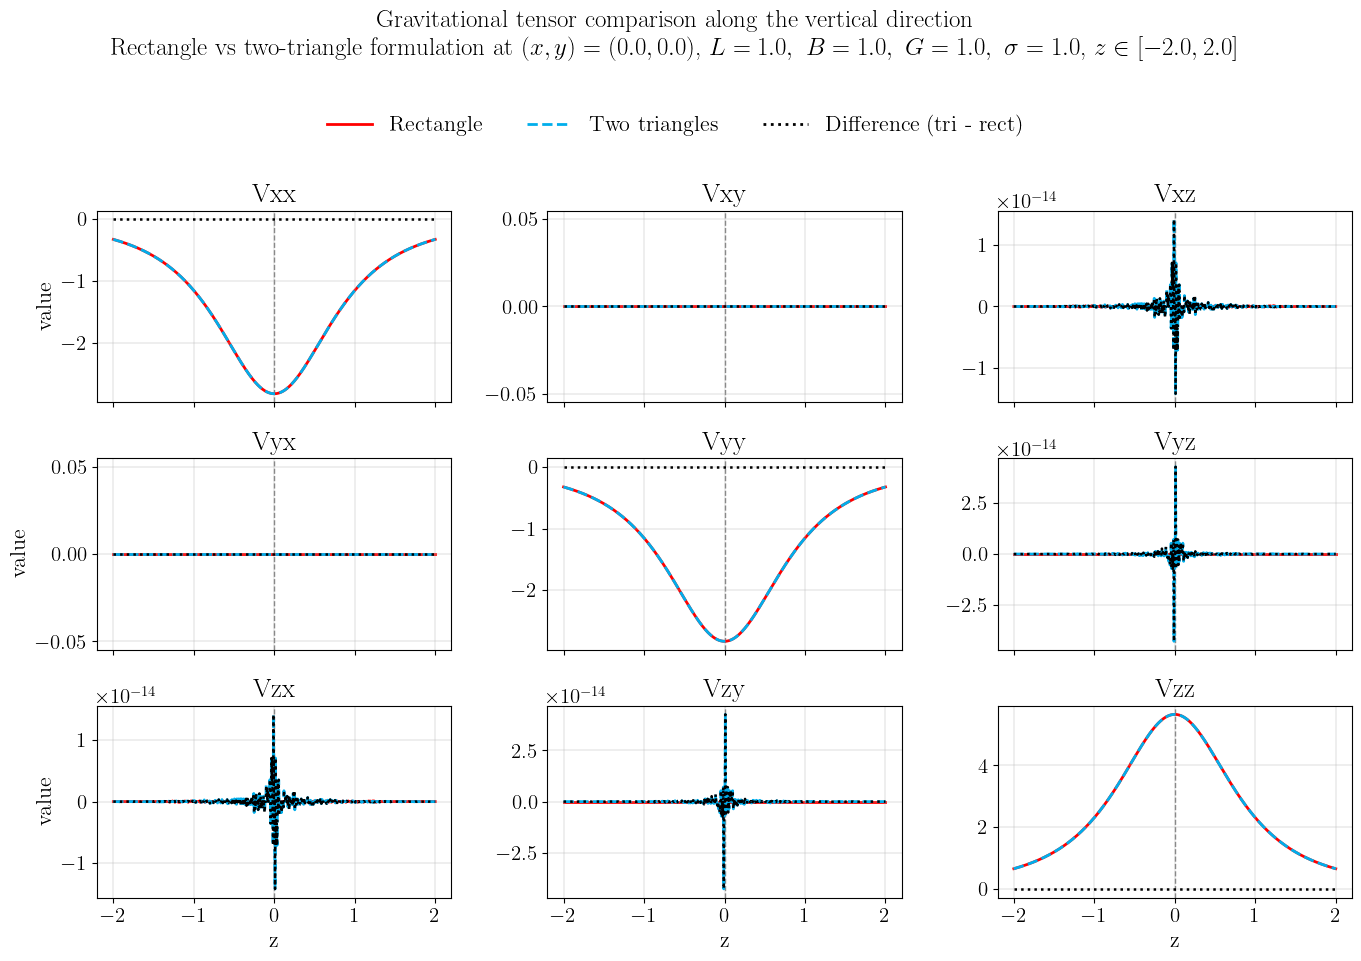

Saved: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test10T_Tensor_Rect_vs_2Tri_case2_xy_0p5_0p5.pdf


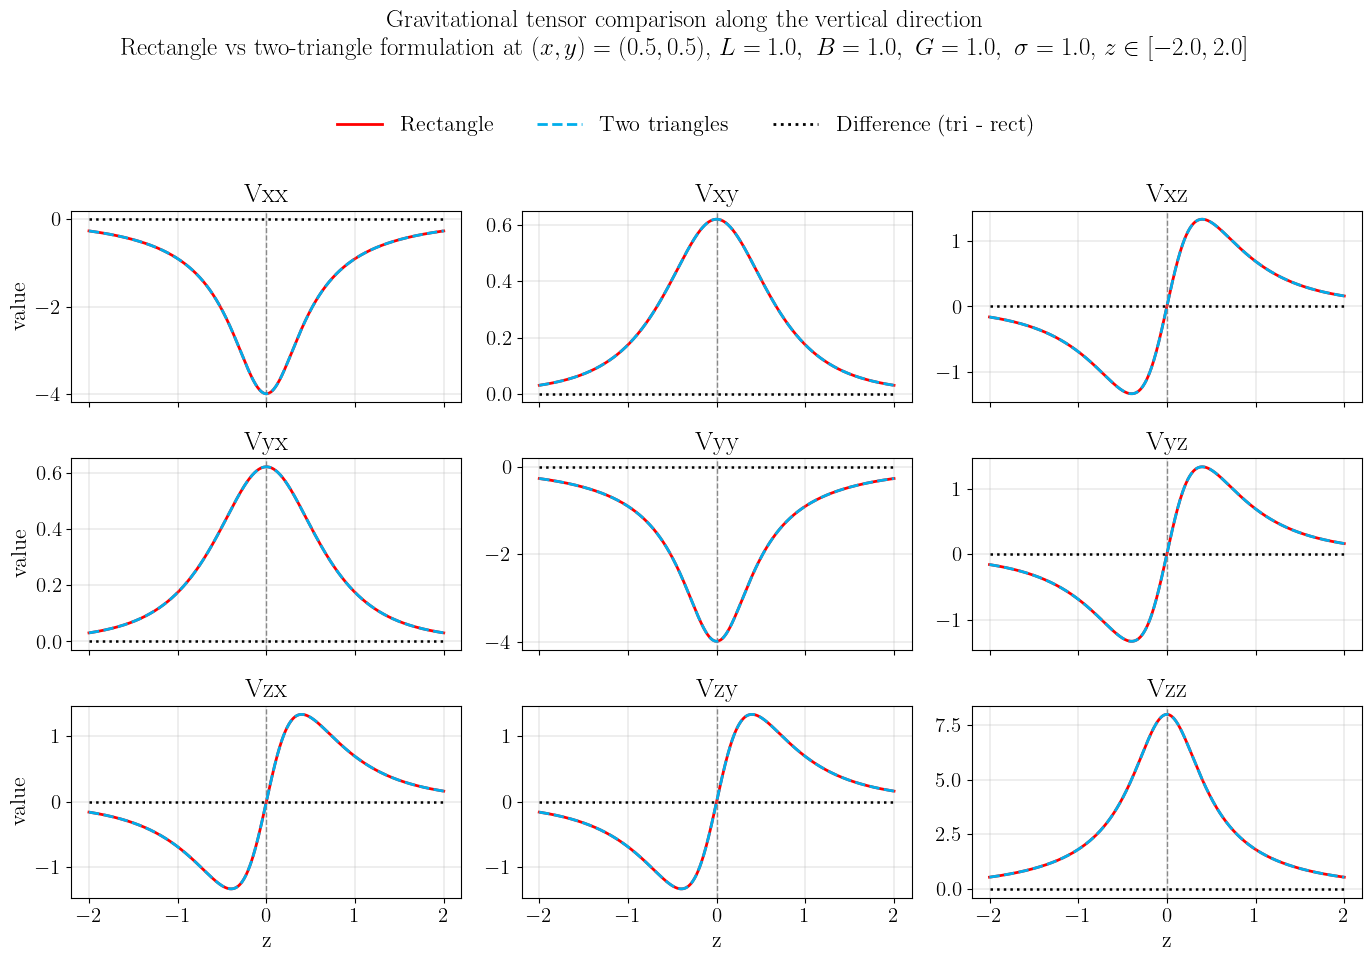

In [14]:
# ============================================================
# Rectangle (analytic tensor) vs Rectangle built from TWO TRIANGLES (tensor)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# -----------------------------
# TeX style settings
# -----------------------------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 16,
    "font.size": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

# -----------------------------
# Imports
# -----------------------------
from RectangleGravitationalField.rectangle_tensor import (
    gravitational_Vxx_rectangle,
    gravitational_Vyy_rectangle,
    gravitational_Vzz_rectangle,
    gravitational_Vxy_rectangle,
    gravitational_Vxz_rectangle,
    gravitational_Vyz_rectangle,
)

from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation


# ============================================================
# PARAMETERS
# ============================================================
G = 1.0
sigma = 1.0
L = 1.0
B = 1.0
z_r = 0.0

ZMAX = 2.0
NZ = 801
SKIP_Z0 = True
z0_skip_tol = 0.0  # if 0: skip exactly z=0; else skip |z|<tol

CASES = [
    ("case1", 0.0, 0.0),
    ("case2", 0.5, 0.5),
]

# Safe point used only to choose tri_sign
xT, yT, zT = 0.23, -0.17, 0.31

# Colors
lb = np.array([0, 174, 235]) / 255.0  # blue
red = "red"
diff_color = "black"

OUTDIR = Path(".")
OUTDIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Helper: enforce triangle normal aligned with +z
# ============================================================
def oriented_triangle(vertices, *, desired_nhat, G=1.0, sigma=1.0, eps=0.0):
    v = np.asarray(vertices, dtype=float)
    n_raw = np.cross(v[1] - v[0], v[2] - v[0])
    if np.dot(n_raw, desired_nhat) < 0.0:
        v = v[[0, 2, 1]]  # flip winding
    return TriangleLaminaGravitation(vertices=v, G=G, sigma=sigma, eps=eps)


# ============================================================
# Build rectangle [-L,L] x [-B,B] at z=z_r from 2 triangles
# (split along diagonal v00 -> v11)
# ============================================================
v00 = np.array([-L, -B, z_r])
v10 = np.array([+L, -B, z_r])
v11 = np.array([+L, +B, z_r])
v01 = np.array([-L, +B, z_r])

desired_nhat = np.array([0.0, 0.0, 1.0])

tri1 = oriented_triangle(np.vstack([v00, v10, v11]), desired_nhat=desired_nhat, G=G, sigma=sigma, eps=0.0)
tri2 = oriented_triangle(np.vstack([v00, v11, v01]), desired_nhat=desired_nhat, G=G, sigma=sigma, eps=0.0)


# ============================================================
# Rectangle tensor (3x3) at a point
# IMPORTANT FIX: evaluate at z_rect = 2*z_r - z
# ============================================================
def rect_tensor(x, y, z):
    z_rect = 2.0 * z_r - z
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Vxx = gravitational_Vxx_rectangle(x, y, z_rect, L, B, z_r, G, sigma)
        Vyy = gravitational_Vyy_rectangle(x, y, z_rect, L, B, z_r, G, sigma)
        Vzz = gravitational_Vzz_rectangle(x, y, z_rect, L, B, z_r, G, sigma)
        Vxy = gravitational_Vxy_rectangle(x, y, z_rect, L, B, z_r, G, sigma)
        Vxz = gravitational_Vxz_rectangle(x, y, z_rect, L, B, z_r, G, sigma)
        Vyz = gravitational_Vyz_rectangle(x, y, z_rect, L, B, z_r, G, sigma)

    return np.array([
        [Vxx, Vxy, Vxz],
        [Vxy, Vyy, Vyz],
        [Vxz, Vyz, Vzz],
    ], dtype=float)


# ============================================================
# Triangle tensor at a point (sum of 2 triangles)
# Use symmetric part for comparison
# ============================================================
def tri_tensor(x, y, z):
    P = np.array([x, y, z], dtype=float)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        G1 = np.array(tri1.gravity_tensor(P), dtype=float)
        G2 = np.array(tri2.gravity_tensor(P), dtype=float)

    Gamma = G1 + G2
    Gamma = 0.5 * (Gamma + Gamma.T)
    return Gamma


# ============================================================
# AUTO-DETECT GLOBAL SIGN (tri_sign) using safe point
# ============================================================
TR = rect_tensor(xT, yT, zT)
TT = tri_tensor(xT, yT, zT)
n1 = np.linalg.norm((+1.0) * TT - TR)
n2 = np.linalg.norm((-1.0) * TT - TR)
tri_sign = +1.0 if n1 <= n2 else -1.0


# ============================================================
# Z sweep array
# ============================================================
z = np.linspace(-ZMAX, +ZMAX, NZ)
if SKIP_Z0:
    if z0_skip_tol == 0.0:
        z = z[z != 0.0]
    else:
        z = z[np.abs(z) > z0_skip_tol]


# ============================================================
# Compute curves for one (x,y)
# ============================================================
def compute_z_sweep(x, y, zvals):
    R = np.empty((len(zvals), 3, 3), dtype=float)
    T = np.empty((len(zvals), 3, 3), dtype=float)

    for k, zk in enumerate(zvals):
        R[k] = rect_tensor(x, y, zk)
        T[k] = tri_sign * tri_tensor(x, y, zk)

    D = T - R
    return R, T, D


# ============================================================
# Plot helper
# ============================================================
COMP_NAMES = [
    ["xx", "xy", "xz"],
    ["yx", "yy", "yz"],
    ["zx", "zy", "zz"],
]

def plot_tensor_panels_and_save(zvals, R, T, D, x0, y0, tag):
    fig, axs = plt.subplots(3, 3, figsize=(14, 10), sharex=True)

    title = (
        "Gravitational tensor comparison along the vertical direction\n"
        rf"Rectangle vs two-triangle formulation at $(x,y)=({x0},{y0})$, "
        rf"$L={L},\ B={B},\ G={G},\ \sigma={sigma}$, $z\in[-{ZMAX},{ZMAX}]$"
    )
    fig.suptitle(title, fontsize=18, y=0.965)

    for i in range(3):
        for j in range(3):
            ax = axs[i, j]
            ax.plot(zvals, R[:, i, j], color=red, linestyle="-",  linewidth=2,   zorder=1)
            ax.plot(zvals, T[:, i, j], color=lb,  linestyle="--", linewidth=2,   zorder=3)
            ax.plot(zvals, D[:, i, j], color=diff_color, linestyle=":", linewidth=1.8, zorder=4)

            ax.set_title(f"V{COMP_NAMES[i][j]}")
            ax.axvline(0.0, color="gray", linestyle="--", linewidth=1, zorder=0)
            ax.grid(True, linewidth=0.3)

            if i == 2:
                ax.set_xlabel("z")
            if j == 0:
                ax.set_ylabel("value")

    handles = [
        plt.Line2D([0], [0], color=red, linewidth=2, linestyle="-",  label="Rectangle"),
        plt.Line2D([0], [0], color=lb,  linewidth=2, linestyle="--", label="Two triangles"),
        plt.Line2D([0], [0], color=diff_color, linewidth=2, linestyle=":", label="Difference (tri - rect)"),
    ]

    # Legend under title
    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.88),
    )

    # Leave room for title + legend
    plt.tight_layout(rect=[0, 0, 1, 0.89])

    # Save PDF
    def fmt_num(a):
        s = f"{a:.1f}"
        return s.replace(".", "p")

    outname = OUTDIR / f"Test10T_Tensor_Rect_vs_2Tri_{tag}_xy_{fmt_num(x0)}_{fmt_num(y0)}.pdf"
    fig.savefig(outname, bbox_inches="tight")
    print(f"Saved: {outname.resolve()}")

    plt.show()


# ============================================================
# RUN + SAVE
# ============================================================
for tag, x0, y0 in CASES:
    R, T, D = compute_z_sweep(x0, y0, z)
    plot_tensor_panels_and_save(z, R, T, D, x0=x0, y0=y0, tag=tag)


In [15]:

# Triangle tensor
# Computes the 3×3 gravity-gradient tensor Γ = ∂g/∂x from Triangle_GP.py,
# and writes results + Laplacian(trace) to a txt file.
#
# Notes:
# - Off the triangle plane and away from edges/vertices, trace(Γ) should be ~0.
# - On the plane / edges / vertices you may see inf/nan (expected singular behavior).
# - Triangle_GP.py returns Γ without enforced symmetrization; we report both:
#     Γ_raw and Γ_sym = 0.5*(Γ + Γ^T)
#
import numpy as np
from pathlib import Path

from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation

# -----------------------------
# Parameters
# -----------------------------
G = 1.0
sigma = 1.0
eps = 0.0

# -----------------------------
# Define ONE triangle in the plane z=0
# Choose a simple right triangle:
#   v0 = (-1, -1, 0)
#   v1 = ( +1, -1, 0)
#   v2 = (-1, +1, 0)
# This triangle occupies the region x<=1, y<=1, x+y<=0 (in that coordinate choice).
# Its centroid:
#   C = (v0+v1+v2)/3 = (-1/3, -1/3, 0)
# -----------------------------
v0 = np.array([-1.0, -1.0, 0.0])
v1 = np.array([+1.0, -1.0, 0.0])
v2 = np.array([-1.0, +1.0, 0.0])

tri = TriangleLaminaGravitation(vertices=np.vstack([v0, v1, v2]), G=G, sigma=sigma, eps=eps)

# -----------------------------
# Test points
# -----------------------------
h = 1.0
C = (v0 + v1 + v2) / 3.0  # centroid

points = {
    # Above / below centroid (safe, off-plane)
    "1) Above centroid":            (float(C[0]), float(C[1]), +h),
    "2) Below centroid":            (float(C[0]), float(C[1]), -h),

    # Above / below interior point (choose something clearly inside)
    # For this triangle, (-0.6,-0.6) is inside.
    "3) Above inside (-0.6,-0.6,+h)": (-0.6, -0.6, +h),
    "4) Below inside (-0.6,-0.6,-h)": (-0.6, -0.6, -h),

    # On-plane interior (may show strong behavior but finite away from edges)
    "5) On-plane inside (-0.6,-0.6,0)": (-0.6, -0.6, 0.0),

    # On-plane centroid (still interior)
    "6) On-plane centroid":         (float(C[0]), float(C[1]), 0.0),

    # On an edge (intentionally singular check)
    # Edge v0->v1 lies on y=-1, x in [-1,1]
    "7) On edge v0-v1 (0,-1,0)":    (0.0, -1.0, 0.0),

    # A vertex (intentionally singular)
    "8) Vertex v1 (+1,-1,0)":       (float(v1[0]), float(v1[1]), 0.0),

    # Outside triangle, above/below
    "9) Above outside (2,0,+h)":     (2.0, 0.0, +h),
    "10) Below outside (2,0,-h)":    (2.0, 0.0, -h),
}

# -----------------------------
# Helpers
# -----------------------------
def fmt(v):
    if isinstance(v, (float, np.floating)):
        if np.isnan(v): return "nan"
        if np.isposinf(v): return "+inf"
        if np.isneginf(v): return "-inf"
        return f"{v:.16e}"
    return str(v)

def tensor_eval_triangle(x, y, z):
    P = np.array([x, y, z], dtype=float)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Gamma = np.array(tri.gravity_tensor(P), dtype=float)  # (3,3)
    Gamma_sym = 0.5 * (Gamma + Gamma.T)
    return Gamma, Gamma_sym

def laplacian(Gamma):
    # trace(Γ) = Γxx + Γyy + Γzz
    return float(Gamma[0, 0] + Gamma[1, 1] + Gamma[2, 2])

def antisym_norm(Gamma):
    A = 0.5 * (Gamma - Gamma.T)
    return float(np.linalg.norm(A, ord="fro"))

# -----------------------------
# Run and write to txt
# -----------------------------
out_path = Path("Test11_TriangleTensor_Only_WithLaplacian.txt")

lines = []
lines.append("Test11: Triangle tensor only (Triangle_GP.py) with Laplacian/trace\n\n")
lines.append("Triangle vertices (z=0 plane):\n")
lines.append(f"  v0 = {v0.tolist()}\n")
lines.append(f"  v1 = {v1.tolist()}\n")
lines.append(f"  v2 = {v2.tolist()}\n")
lines.append(f"  n_hat = {tri.n_hat.tolist()}\n\n")
lines.append("Parameters:\n")
lines.append(f"  G={G}\n")
lines.append(f"  sigma={sigma}\n")
lines.append(f"  eps={eps}\n")
lines.append("-" * 78 + "\n")

for name, (x, y, z) in points.items():
    Gamma_raw, Gamma_sym = tensor_eval_triangle(x, y, z)

    lap_raw = laplacian(Gamma_raw)
    lap_sym = laplacian(Gamma_sym)

    asym_raw = antisym_norm(Gamma_raw)

    lines.append(f"{name}\n")
    lines.append(f"  Point (x,y,z) = ({x}, {y}, {z})\n\n")

    # Raw tensor
    lines.append("  Triangle tensor Γ_raw = ∂g/∂x (3×3):\n")
    lines.append(f"    [xx xy xz] = [{fmt(Gamma_raw[0,0])}, {fmt(Gamma_raw[0,1])}, {fmt(Gamma_raw[0,2])}]\n")
    lines.append(f"    [yx yy yz] = [{fmt(Gamma_raw[1,0])}, {fmt(Gamma_raw[1,1])}, {fmt(Gamma_raw[1,2])}]\n")
    lines.append(f"    [zx zy zz] = [{fmt(Gamma_raw[2,0])}, {fmt(Gamma_raw[2,1])}, {fmt(Gamma_raw[2,2])}]\n\n")

    # Symmetric tensor
    lines.append("  Symmetric part Γ_sym = 0.5*(Γ_raw + Γ_raw^T):\n")
    lines.append(f"    [xx xy xz] = [{fmt(Gamma_sym[0,0])}, {fmt(Gamma_sym[0,1])}, {fmt(Gamma_sym[0,2])}]\n")
    lines.append(f"    [yx yy yz] = [{fmt(Gamma_sym[1,0])}, {fmt(Gamma_sym[1,1])}, {fmt(Gamma_sym[1,2])}]\n")
    lines.append(f"    [zx zy zz] = [{fmt(Gamma_sym[2,0])}, {fmt(Gamma_sym[2,1])}, {fmt(Gamma_sym[2,2])}]\n\n")

    # Diagnostics
    lines.append(f"  trace(Γ_raw) = {fmt(lap_raw)}\n")
    lines.append(f"  trace(Γ_sym) = {fmt(lap_sym)}\n")
    lines.append(f"  ||antisym(Γ_raw)||_F = {fmt(asym_raw)}\n")

    if z != 0.0 and np.isfinite(lap_sym):
        lines.append("  Note: off-plane trace(Γ_sym) should be ~ 0 (numerical roundoff).\n")
    else:
        lines.append("  Note: on-plane / edges / vertices may yield inf/nan (expected singular behavior).\n")

    lines.append("-" * 78 + "\n")

out_path.write_text("".join(lines))
print(f"Saved: {out_path.resolve()}")


Saved: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test11_TriangleTensor_Only_WithLaplacian.txt


In [16]:
# ============================================================
# TEST: Thin cuboid vs rectangle 
# Uses your NEW rectangle vectorized/parallel batch functions
# and existing cuboid batch functions.
#
# ============================================================

import numpy as np
from pathlib import Path

# -----------------------------
# Imports (Cuboid)
# -----------------------------
from CuboidGravitationalField.potential import (
    Gravitational_potential_cuboid,
    potential_batch as potential_batch_cuboid,
)
from CuboidGravitationalField.acceleration import (
    gravitational_gx_cuboid,
    gravitational_gy_cuboid,
    gravitational_gz_cuboid,
    gravitational_acceleration_batch,
)

# -----------------------------
# Imports (Rectangle)
# -----------------------------
from RectangleGravitationalField.rectangle_potential import (
    gravitational_potential_rectangle,
    potential_batch_rectangle,
)
from RectangleGravitationalField.rectangle_acceleration import (
    gravitational_gx_rectangle,
    gravitational_gy_rectangle,
    gravitational_gz_rectangle,
    acceleration_batch_rectangle,
)


# -----------------------------
# Test01 parameters
# -----------------------------
L = 1.0
B = 1.0
D = 1e-7          # half-thickness for cuboid
rho = 1.0         # volume density
G = 1.0

sigma = 2.0 * D * rho   # surface density equivalent

# -----------------------------
# Test points for rectangle (z=0 plane singularities included)
# -----------------------------
# Note: "vertex" and "edge" points on z=0 can produce ±inf in gx/gy for rectangle.
points = {
    "1) Vertex of rectangle (L,B,0)": ( L,  B, 0.0),
    "2) On edge (x=L, y=0, z=0)":     ( L,  0.0, 0.0),
    "3) Inside on plane (0,0,0)":     ( 0.0, 0.0, 0.0),
    "4) Exterior on plane (2,0,0)":   ( 2.0, 0.0, 0.0),
    "5) Extended edge line (L,2,0)":  ( L,  2.0, 0.0),
    "6) Above (0,0,+h)":              ( 0.0, 0.0, 1.0),
    "7) Below (0,0,-h)":              ( 0.0, 0.0,-1.0),
}

# Turn dict into arrays (preserve insertion order)
names = list(points.keys())
pts = np.array([points[k] for k in names], dtype=float)  # shape (N,3)


# ============================================================
# Batch evaluation helpers
# ============================================================

def cuboid_eval_batch(pts):
    """
    Returns V,gx,gy,gz arrays shape (N,)
    Uses cuboid batch for V and acceleration.
    """
    V = potential_batch_cuboid(pts, L, B, D, rho, G, parallel_threshold=100)

    gx, gy, gz = gravitational_acceleration_batch(
        pts, L, B, D, rho, G, parallel_threshold=100
    )
    return V, gx, gy, gz


def rect_eval_batch(pts):
    """
    Returns V,gx,gy,gz arrays shape (N,)
    Uses rectangle batch for V and acceleration.
    """
    # IMPORTANT: use eps=1e-15 for consistent z=0 handling
    V = potential_batch_rectangle(pts, L, B, sigma, G=G, eps=1e-15)

    gx, gy, gz = acceleration_batch_rectangle(
        pts, L, B, sigma, G=G, eps=1e-15
    )
    return V, gx, gy, gz


# ============================================================
# Formatting
# ============================================================

def fmt(v):
    v = float(v)
    if np.isnan(v): return "nan"
    if np.isposinf(v): return "+inf"
    if np.isneginf(v): return "-inf"
    return f"{v:.16e}"


# ============================================================
# Run
# ============================================================

Vc, gxc, gyc, gzc = cuboid_eval_batch(pts)
Vr, gxr, gyr, gzr = rect_eval_batch(pts)

# Differences (Cuboid - Rectangle)
dV  = Vc  - Vr
dgx = gxc - gxr
dgy = gyc - gyr
dgz = gzc - gzr


# ============================================================
# Write txt (same layout as your original)
# ============================================================

out_path = Path("Test01_ThinCuboid_vs_Rectangle.txt")

lines = []
lines.append("Test01: Thin cuboid vs rectangle (lamina)  [UPDATED: batch calls]\n\n")
lines.append(
    "Parameters:\n"
    f"  L=B={L}\n"
    f"  D={D} (half-thickness)\n"
    f"  rho={rho}\n"
    f"  sigma=2*D*rho={sigma}\n"
    f"  G={G}\n\n"
)
lines.append("-" * 78 + "\n\n")

for i, name in enumerate(names):
    x, y, z = pts[i]

    lines.append(f"{name}\n")
    lines.append(f"  Point (x,y,z) = ({x}, {y}, {z})\n\n")

    lines.append("  Cuboid (rho=1):\n")
    lines.append(f"    V  = {fmt(Vc[i])}\n")
    lines.append(f"    gx = {fmt(gxc[i])}\n")
    lines.append(f"    gy = {fmt(gyc[i])}\n")
    lines.append(f"    gz = {fmt(gzc[i])}\n\n")

    lines.append("  Rectangle (sigma=2D*rho):\n")
    lines.append(f"    V  = {fmt(Vr[i])}\n")
    lines.append(f"    gx = {fmt(gxr[i])}\n")
    lines.append(f"    gy = {fmt(gyr[i])}\n")
    lines.append(f"    gz = {fmt(gzr[i])}\n\n")

    lines.append("  Difference (Cuboid - Rectangle):\n")
    lines.append(f"    dV  = {fmt(dV[i])}\n")
    lines.append(f"    dgx = {fmt(dgx[i])}\n")
    lines.append(f"    dgy = {fmt(dgy[i])}\n")
    lines.append(f"    dgz = {fmt(dgz[i])}\n")
    lines.append("-" * 78 + "\n\n")

out_path.write_text("".join(lines), encoding="utf-8")
print(f"Saved: {out_path.resolve()}")


# ============================================================
# OPTIONAL: consistency sanity check (scalar vs batch for these 7 points)
# (Uncomment if you want to verify correctness after refactors)
# ============================================================
# def cuboid_eval_scalar(x, y, z):
#     V = Gravitational_potential_cuboid(x, y, z, L, B, D, rho, G)
#     gx = gravitational_gx_cuboid(x, y, z, L, B, D, rho, G)
#     gy = gravitational_gy_cuboid(x, y, z, L, B, D, rho, G)
#     gz = gravitational_gz_cuboid(x, y, z, L, B, D, rho, G)
#     return V, gx, gy, gz
#
# def rect_eval_scalar(x, y, z):
#     V = gravitational_potential_rectangle(x, y, z, L, B, sigma, G=G)
#     gx = gravitational_gx_rectangle(x, y, z, L, B, sigma, G=G)
#     gy = gravitational_gy_rectangle(x, y, z, L, B, sigma, G=G)
#     gz = gravitational_gz_rectangle(x, y, z, L, B, sigma, G=G, eps=1e-15)
#     return V, gx, gy, gz
#
# for i, name in enumerate(names):
#     x, y, z = pts[i]
#     Vc_s, gxc_s, gyc_s, gzc_s = cuboid_eval_scalar(x, y, z)
#     Vr_s, gxr_s, gyr_s, gzr_s = rect_eval_scalar(x, y, z)
#
#     print(name)
#     print(" cub V diff:", Vc[i]-Vc_s, " rect V diff:", Vr[i]-Vr_s)
#     print(" cub gx diff:", gxc[i]-gxc_s, " rect gx diff:", gxr[i]-gxr_s)
#     print(" cub gy diff:", gyc[i]-gyc_s, " rect gy diff:", gyr[i]-gyr_s)
#     print(" cub gz diff:", gzc[i]-gzc_s, " rect gz diff:", gzr[i]-gzr_s)
#     print()


Saved: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test01_ThinCuboid_vs_Rectangle.txt


/Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [32]:
# Test11_TriangleTensor_VectorizedVsScalar_WithLaplacian.py
#
# Triangle tensor comparison: SCALAR vs VECTORIZED/BATCH (if available).
# Computes the 3×3 gravity-gradient tensor Γ = ∂g/∂x from Triangle_GP.py
# using two evaluation paths:
#   (A) scalar point-by-point: tri.gravity_tensor(P)
#   (B) vectorized/batch:      tri.gravity_tensor_batch(Ps)  (or fallback to A)
#
# Writes both tensors, their differences, and Laplacian(trace) diagnostics.
#
# Notes:
# - Off the triangle plane and away from edges/vertices, trace(Γ) should be ~0.
# - On-plane / edges / vertices may show inf/nan (expected singular behavior).
# - Triangle_GP.py may return Γ without enforced symmetrization; we report both:
#     Γ_raw and Γ_sym = 0.5*(Γ + Γ^T)
#
import numpy as np
from pathlib import Path

from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation

# -----------------------------
# Parameters
# -----------------------------
G = 1.0
sigma = 1.0
eps = 0.0

# -----------------------------
# Define ONE triangle in the plane z=0
# Right triangle:
#   v0 = (-1, -1, 0)
#   v1 = ( +1, -1, 0)
#   v2 = (-1, +1, 0)
# -----------------------------
v0 = np.array([-1.0, -1.0, 0.0])
v1 = np.array([+1.0, -1.0, 0.0])
v2 = np.array([-1.0, +1.0, 0.0])

tri = TriangleLaminaGravitation(vertices=np.vstack([v0, v1, v2]), G=G, sigma=sigma, eps=eps)

# -----------------------------
# Test points
# -----------------------------
h = 1.0
C = (v0 + v1 + v2) / 3.0  # centroid

points = {
    "1) Above centroid":               (float(C[0]), float(C[1]), +h),
    "2) Below centroid":               (float(C[0]), float(C[1]), -h),
    "3) Above inside (-0.6,-0.6,+h)":  (-0.6, -0.6, +h),
    "4) Below inside (-0.6,-0.6,-h)":  (-0.6, -0.6, -h),
    "5) On-plane inside (-0.6,-0.6,0)":(-0.6, -0.6, 0.0),
    "6) On-plane centroid":            (float(C[0]), float(C[1]), 0.0),
    "7) On edge v0-v1 (0,-1,0)":       (0.0, -1.0, 0.0),
    "8) Vertex v1 (+1,-1,0)":          (float(v1[0]), float(v1[1]), 0.0),
    "9) Above outside (2,0,+h)":        (2.0, 0.0, +h),
    "10) Below outside (2,0,-h)":       (2.0, 0.0, -h),
}

# Build an ordered list for vectorized path
names = list(points.keys())
Pts = np.array([points[k] for k in names], dtype=float)  # shape (N,3)

# -----------------------------
# Helpers
# -----------------------------
def fmt(v):
    if isinstance(v, (float, np.floating)):
        if np.isnan(v): return "nan"
        if np.isposinf(v): return "+inf"
        if np.isneginf(v): return "-inf"
        return f"{v:.16e}"
    return str(v)

def laplacian(Gamma):
    return float(Gamma[0, 0] + Gamma[1, 1] + Gamma[2, 2])

def antisym_norm(Gamma):
    A = 0.5 * (Gamma - Gamma.T)
    return float(np.linalg.norm(A, ord="fro"))

def tensor_sym(Gamma):
    return 0.5 * (Gamma + Gamma.T)

def safe_norm_fro(M):
    # Frobenius norm but robust to inf/nan: only on finite entries
    A = np.asarray(M, dtype=float)
    mask = np.isfinite(A)
    if not np.any(mask):
        return np.nan
    return float(np.linalg.norm(A[mask].ravel(), ord=2))

def eval_scalar_all(Pts):
    out = np.empty((Pts.shape[0], 3, 3), dtype=float)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        for i in range(Pts.shape[0]):
            out[i] = np.array(tri.gravity_tensor(Pts[i]), dtype=float)
    return out

def eval_vectorized_all(Pts):
    # Try common batch/vectorized method names without changing Triangle_GP.py API.
    # If none exist, fallback to scalar loop.
    method = None
    for cand in ("gravity_tensor_batch", "gravity_tensor_vectorized", "tensor_batch", "gravity_gradient_batch"):
        if hasattr(tri, cand):
            method = cand
            break

    if method is None:
        return None, "No batch method found; using scalar evaluation."

    fn = getattr(tri, method)

    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        T = fn(Pts)  # expecting (N,3,3)
    T = np.asarray(T, dtype=float)

    if T.ndim != 3 or T.shape[1:] != (3, 3):
        return None, f"Batch method '{method}' returned shape {T.shape}, expected (N,3,3). Falling back to scalar."

    return T, f"Used batch method: tri.{method}(Pts)."

def rel_abs_err(a, b, tiny=1e-300):
    den = np.maximum(np.abs(b), tiny)
    return np.abs(a - b) / den

def summarize_err(e):
    e = np.asarray(e, dtype=float)
    e = e[np.isfinite(e)]
    if e.size == 0:
        return dict(n=0, max=np.nan, p99=np.nan, p95=np.nan, median=np.nan, mean=np.nan)
    return dict(
        n=e.size,
        max=float(np.max(e)),
        p99=float(np.percentile(e, 99)),
        p95=float(np.percentile(e, 95)),
        median=float(np.median(e)),
        mean=float(np.mean(e)),
    )

def fmt_stats(name, s):
    return (f"{name:<10s} n={s['n']:4d}  "
            f"median={s['median']:.3e}  mean={s['mean']:.3e}  "
            f"p95={s['p95']:.3e}  p99={s['p99']:.3e}  max={s['max']:.3e}")

# -----------------------------
# Evaluate both ways
# -----------------------------
T_scalar = eval_scalar_all(Pts)

T_vec, vec_note = eval_vectorized_all(Pts)
if T_vec is None:
    T_vec = T_scalar.copy()
    vec_note = vec_note  # already explains fallback

# -----------------------------
# Component-wise error stats (vectorized vs scalar)
# Only meaningful where scalar is finite.
# -----------------------------
err_stats = {}
comp_names = [
    ("Gxx", (0,0)), ("Gxy", (0,1)), ("Gxz", (0,2)),
    ("Gyx", (1,0)), ("Gyy", (1,1)), ("Gyz", (1,2)),
    ("Gzx", (2,0)), ("Gzy", (2,1)), ("Gzz", (2,2)),
]
for nm, (i,j) in comp_names:
    e = rel_abs_err(T_vec[:,i,j], T_scalar[:,i,j])
    err_stats[nm] = summarize_err(e)

# -----------------------------
# Write output
# -----------------------------
out_path = Path("Test11_TriangleTensor_VectorizedVsScalar_WithLaplacian.txt")

lines = []
lines.append("Test11: Triangle tensor SCALAR vs VECTORIZED/BATCH with Laplacian/trace\n\n")
lines.append("Triangle vertices (z=0 plane):\n")
lines.append(f"  v0 = {v0.tolist()}\n")
lines.append(f"  v1 = {v1.tolist()}\n")
lines.append(f"  v2 = {v2.tolist()}\n")
lines.append(f"  n_hat = {tri.n_hat.tolist()}\n\n")
lines.append("Parameters:\n")
lines.append(f"  G={G}\n")
lines.append(f"  sigma={sigma}\n")
lines.append(f"  eps={eps}\n\n")
lines.append(f"Vectorization note: {vec_note}\n")
lines.append("-" * 78 + "\n")

# Summary stats
lines.append("Component-wise relative absolute error |vec - scalar| / max(|scalar|,tiny):\n")
for nm, _ in comp_names:
    lines.append("  " + fmt_stats(nm, err_stats[nm]) + "\n")
lines.append("-" * 78 + "\n\n")

# Per-point detailed report
for idx, name in enumerate(names):
    x, y, z = Pts[idx]

    Gs = T_scalar[idx]
    Gv = T_vec[idx]

    Gs_sym = tensor_sym(Gs)
    Gv_sym = tensor_sym(Gv)

    lap_s_raw = laplacian(Gs)
    lap_v_raw = laplacian(Gv)
    lap_s_sym = laplacian(Gs_sym)
    lap_v_sym = laplacian(Gv_sym)

    asym_s = antisym_norm(Gs)
    asym_v = antisym_norm(Gv)

    D_raw = Gv - Gs
    D_sym = Gv_sym - Gs_sym

    lines.append(f"{name}\n")
    lines.append(f"  Point (x,y,z) = ({x}, {y}, {z})\n\n")

    # Scalar tensor
    lines.append("  SCALAR Γ_raw:\n")
    lines.append(f"    [xx xy xz] = [{fmt(Gs[0,0])}, {fmt(Gs[0,1])}, {fmt(Gs[0,2])}]\n")
    lines.append(f"    [yx yy yz] = [{fmt(Gs[1,0])}, {fmt(Gs[1,1])}, {fmt(Gs[1,2])}]\n")
    lines.append(f"    [zx zy zz] = [{fmt(Gs[2,0])}, {fmt(Gs[2,1])}, {fmt(Gs[2,2])}]\n\n")

    # Vectorized tensor
    lines.append("  VECTORIZED/BATCH Γ_raw:\n")
    lines.append(f"    [xx xy xz] = [{fmt(Gv[0,0])}, {fmt(Gv[0,1])}, {fmt(Gv[0,2])}]\n")
    lines.append(f"    [yx yy yz] = [{fmt(Gv[1,0])}, {fmt(Gv[1,1])}, {fmt(Gv[1,2])}]\n")
    lines.append(f"    [zx zy zz] = [{fmt(Gv[2,0])}, {fmt(Gv[2,1])}, {fmt(Gv[2,2])}]\n\n")

    # Differences
    lines.append("  Difference Δ_raw = (vec - scalar):\n")
    lines.append(f"    ||Δ_raw||_F (finite-only) = {fmt(safe_norm_fro(D_raw))}\n")
    lines.append(f"    [xx xy xz] = [{fmt(D_raw[0,0])}, {fmt(D_raw[0,1])}, {fmt(D_raw[0,2])}]\n")
    lines.append(f"    [yx yy yz] = [{fmt(D_raw[1,0])}, {fmt(D_raw[1,1])}, {fmt(D_raw[1,2])}]\n")
    lines.append(f"    [zx zy zz] = [{fmt(D_raw[2,0])}, {fmt(D_raw[2,1])}, {fmt(D_raw[2,2])}]\n\n")

    # Diagnostics
    lines.append("  Diagnostics:\n")
    lines.append(f"    trace(scalar Γ_raw) = {fmt(lap_s_raw)}\n")
    lines.append(f"    trace(vec    Γ_raw) = {fmt(lap_v_raw)}\n")
    lines.append(f"    trace(scalar Γ_sym) = {fmt(lap_s_sym)}\n")
    lines.append(f"    trace(vec    Γ_sym) = {fmt(lap_v_sym)}\n")
    lines.append(f"    ||antisym(scalar Γ_raw)||_F = {fmt(asym_s)}\n")
    lines.append(f"    ||antisym(vec    Γ_raw)||_F = {fmt(asym_v)}\n")

    if z != 0.0 and np.isfinite(lap_s_sym) and np.isfinite(lap_v_sym):
        lines.append("    Note: off-plane trace(Γ_sym) should be ~0 (numerical roundoff).\n")
    else:
        lines.append("    Note: on-plane / edges / vertices may yield inf/nan (expected singular behavior).\n")

    lines.append("-" * 78 + "\n")

out_path.write_text("".join(lines))
print(f"Saved: {out_path.resolve()}")


Saved: /Volumes/Dunendran/Programs/Python/A_Gravitational_Field_Polygon/Test11_TriangleTensor_VectorizedVsScalar_WithLaplacian.txt


#### Computational throughput and implementation consistency

In [ ]:
# ============================================================
# THROUGHPUT + ACCURACY SUMMARY (Rectangle vs Very Thin Cuboid)
#
#   Empirically : Vxz_rect ≈ -Vxz_cub and Vyz_rect ≈ -Vyz_cub
#   => convert cuboid -> rectangle convention by:
#        Vxz_cub *= -1
#        Vyz_cub *= -1
#
# ============================================================

import time
import numpy as np

# -----------------------------
# Imports (Cuboid)
# -----------------------------
from CuboidGravitationalField.potential import potential_batch as potential_batch_cuboid
from CuboidGravitationalField.acceleration import gravitational_acceleration_batch
from CuboidGravitationalField.tensor import gravitational_tensor_batch

# -----------------------------
# Imports (Rectangle)
# -----------------------------
from RectangleGravitationalField.rectangle_potential import potential_batch_rectangle
from RectangleGravitationalField.rectangle_acceleration import acceleration_batch_rectangle
from RectangleGravitationalField.rectangle_tensor import tensor_batch_rectangle

# ============================================================
# SETTINGS
# ============================================================
np.random.seed(7)

NPTS = 50_000

G = 1.0
rho = 1.0

# Square footprint: 2L x 2B
L = 1.0
B = 1.0

# Very thin cuboid full thickness (2D_full), cuboid code uses semi-thickness D
D_full = 2e-5
D = D_full / 2.0

# Equivalent surface density for rectangle
sigma = 2.0 * D * rho
z_r = 0.0

# Avoid near sheet plane
z_min = 1e-3

# Force parallel flags
FORCE_PARALLEL = True
PAR_THRESH_FORCE = 0 if FORCE_PARALLEL else 100
CHUNK_SIZE = 10_000

# ============================================================
# CONVENTION ADAPTER (comparison-only)
# ============================================================
# Convert cuboid tensor to rectangle convention for mixed terms (xz, yz).
# Leave base codes untouched.
CUBOID_TO_RECTANGLE_MIXED_SIGNFLIP = True

# ============================================================
# SAMPLE POINTS
# ============================================================
x = np.random.uniform(-2.0, 2.0, NPTS)
y = np.random.uniform(-2.0, 2.0, NPTS)
z = np.random.uniform(-2.0, 2.0, NPTS)

mask = np.abs(z) < z_min
sgn = np.sign(z[mask])
sgn[sgn == 0.0] = 1.0
z[mask] = sgn * z_min

pts = np.column_stack((x, y, z))

# ============================================================
# HELPERS
# ============================================================
def time_block(func, npts):
    t0 = time.perf_counter()
    out = func()
    dt = time.perf_counter() - t0
    rate = npts / dt
    return out, dt, rate

def rel_abs_err(a, b, tiny=1e-300):
    den = np.maximum(np.abs(b), tiny)
    return np.abs(a - b) / den

def summarize_err(e):
    e = np.asarray(e, dtype=float)
    e = e[np.isfinite(e)]
    if e.size == 0:
        return dict(n=0, max=np.nan, p99=np.nan, p95=np.nan, median=np.nan, mean=np.nan)
    return dict(
        n=e.size,
        max=float(np.max(e)),
        p99=float(np.percentile(e, 99)),
        p95=float(np.percentile(e, 95)),
        median=float(np.median(e)),
        mean=float(np.mean(e)),
    )

def fmt_stats(name, s):
    return (f"{name:<6s}  n={s['n']:6d}  "
            f"median={s['median']:.3e}  mean={s['mean']:.3e}  "
            f"p95={s['p95']:.3e}  p99={s['p99']:.3e}  max={s['max']:.3e}")

def tag_batch_parallel(force_parallel: bool):
    return "[batch+parallel]" if force_parallel else "[batch]"

# ============================================================
# SAFE CALL WRAPPERS (support older/newer signatures)
# ============================================================
def rect_potential_call():
    try:
        return potential_batch_rectangle(
            pts, L, B, sigma,
            G=G, eps=1e-15,
            parallel_threshold=PAR_THRESH_FORCE,
            chunk_size=CHUNK_SIZE
        )
    except TypeError:
        return potential_batch_rectangle(pts, L, B, sigma, G=G, eps=1e-15)

def rect_accel_call():
    try:
        return acceleration_batch_rectangle(
            pts, L, B, sigma,
            G=G, eps=1e-15,
            parallel_threshold=PAR_THRESH_FORCE,
            chunk_size=CHUNK_SIZE
        )
    except TypeError:
        return acceleration_batch_rectangle(pts, L, B, sigma, G=G, eps=1e-15)

def rect_tensor_call():
    try:
        return tensor_batch_rectangle(
            pts, L, B, z_r, G, sigma,
            parallel_threshold=PAR_THRESH_FORCE,
            chunk_size=CHUNK_SIZE
        )
    except TypeError:
        return tensor_batch_rectangle(pts, L, B, z_r, G, sigma)

def cub_potential_call():
    return potential_batch_cuboid(
        pts, L, B, D, rho, G,
        parallel_threshold=PAR_THRESH_FORCE
    )

def cub_accel_call():
    return gravitational_acceleration_batch(
        pts, L, B, D, rho, G,
        parallel_threshold=PAR_THRESH_FORCE
    )

def cub_tensor_call():
    return gravitational_tensor_batch(
        pts, L, B, D, rho, G,
        parallel_threshold=PAR_THRESH_FORCE
    )

# ============================================================
# RUN BENCHMARKS
# ============================================================
results = {}
times = {}

# Rectangle: V
(results["V_rect"], times["V_rect"], _) = time_block(rect_potential_call, NPTS)

# Rectangle: g
((results["gx_rect"], results["gy_rect"], results["gz_rect"]),
 times["g_rect"], _) = time_block(rect_accel_call, NPTS)

# Rectangle: tensor (6 arrays)
((results["Vxx_rect"], results["Vyy_rect"], results["Vzz_rect"],
  results["Vxy_rect"], results["Vxz_rect"], results["Vyz_rect"]),
 times["T_rect"], _) = time_block(rect_tensor_call, NPTS)

# Cuboid: V
(results["V_cub"], times["V_cub"], _) = time_block(cub_potential_call, NPTS)

# Cuboid: g
((results["gx_cub"], results["gy_cub"], results["gz_cub"]),
 times["g_cub"], _) = time_block(cub_accel_call, NPTS)

# Cuboid: tensor (N,3,3) -> extract 6 comps
(T_cub, times["T_cub"], _) = time_block(cub_tensor_call, NPTS)

results["Vxx_cub"] = T_cub[:, 0, 0]
results["Vyy_cub"] = T_cub[:, 1, 1]
results["Vzz_cub"] = T_cub[:, 2, 2]
results["Vxy_cub"] = T_cub[:, 0, 1]
results["Vxz_cub"] = T_cub[:, 0, 2]
results["Vyz_cub"] = T_cub[:, 1, 2]

# ============================================================
# CONVENTION ADAPTER APPLICATION (comparison-only)
# ============================================================
if CUBOID_TO_RECTANGLE_MIXED_SIGNFLIP:
    results["Vxz_cub"] *= -1.0
    results["Vyz_cub"] *= -1.0

# Totals
times["total_rect"] = times["V_rect"] + times["g_rect"] + times["T_rect"]
times["total_cub"]  = times["V_cub"]  + times["g_cub"]  + times["T_cub"]

# ============================================================
# ACCURACY (thin cuboid treated as reference)
#   Note: after the adapter, Vxz_cub/Vyz_cub are in rectangle convention.
# ============================================================
err = {}
err["V"]   = rel_abs_err(results["V_rect"],  results["V_cub"])
err["gx"]  = rel_abs_err(results["gx_rect"], results["gx_cub"])
err["gy"]  = rel_abs_err(results["gy_rect"], results["gy_cub"])
err["gz"]  = rel_abs_err(results["gz_rect"], results["gz_cub"])

err["Vxx"] = rel_abs_err(results["Vxx_rect"], results["Vxx_cub"])
err["Vyy"] = rel_abs_err(results["Vyy_rect"], results["Vyy_cub"])
err["Vzz"] = rel_abs_err(results["Vzz_rect"], results["Vzz_cub"])
err["Vxy"] = rel_abs_err(results["Vxy_rect"], results["Vxy_cub"])
err["Vxz"] = rel_abs_err(results["Vxz_rect"], results["Vxz_cub"])
err["Vyz"] = rel_abs_err(results["Vyz_rect"], results["Vyz_cub"])

stats = {k: summarize_err(v) for k, v in err.items()}

# ============================================================
# WRITE SUMMARY TO TXT
# ============================================================
out_txt = "Test09_Throughput_Accuracy_Rectangle_vs_ThinCuboid.txt"

rect_tag = tag_batch_parallel(FORCE_PARALLEL)
cub_tag  = tag_batch_parallel(FORCE_PARALLEL)

lines = []
lines.append("============================================================")
lines.append("TEST 09: Computational Throughput + Accuracy (FORCED PARALLEL)")
lines.append("Rectangle (square lamina) vs Very Thin Cuboid (thin slab)")
lines.append("============================================================")
lines.append(f"NPTS = {NPTS}")
lines.append(f"Domain sampled: x,y,z ~ Uniform([-2,2]) with |z| >= {z_min}")
lines.append("")
lines.append("Geometry / densities:")
lines.append(f"  Rectangle: L=B={L}  (full size 2L x 2B), plane z_r={z_r}")
lines.append(f"  Cuboid:    L=B={L}, semi-thickness D={D} (full thickness {D_full})")
lines.append(f"  G={G}, rho={rho}, sigma=2*D*rho={sigma}")
lines.append("")
lines.append("------------------------------------------------------------")
lines.append("TIMING (wall-clock seconds) and throughput (points/second)")
lines.append("------------------------------------------------------------")
lines.append(f"Rectangle: V      = {times['V_rect']:.4f} s   ({NPTS/times['V_rect']:.1f} pts/s)   {rect_tag}")
lines.append(f"Rectangle: g      = {times['g_rect']:.4f} s   ({NPTS/times['g_rect']:.1f} pts/s)   {rect_tag}")
lines.append(f"Rectangle: tensor = {times['T_rect']:.4f} s   ({NPTS/times['T_rect']:.1f} pts/s)   {rect_tag}")
lines.append(f"Rectangle: TOTAL  = {times['total_rect']:.4f} s   ({NPTS/times['total_rect']:.1f} pts/s)")
lines.append("")
lines.append(f"Cuboid:    V      = {times['V_cub']:.4f} s   ({NPTS/times['V_cub']:.1f} pts/s)   {cub_tag}")
lines.append(f"Cuboid:    g      = {times['g_cub']:.4f} s   ({NPTS/times['g_cub']:.1f} pts/s)   {cub_tag}")
lines.append(f"Cuboid:    tensor = {times['T_cub']:.4f} s   ({NPTS/times['T_cub']:.1f} pts/s)   {cub_tag}")
lines.append(f"Cuboid:    TOTAL  = {times['total_cub']:.4f} s   ({NPTS/times['total_cub']:.1f} pts/s)")
lines.append("")
speedup = times["total_cub"] / times["total_rect"] if times["total_rect"] > 0 else np.nan
lines.append(f"TOTAL time ratio (Cuboid / Rectangle) = {speedup:.3f}")
lines.append("")
lines.append("------------------------------------------------------------")
lines.append("ACCURACY: relative absolute error |Rect - Cub| / max(|Cub|,tiny)")
lines.append("(Thin cuboid treated as reference; points avoid |z|<z_min)")
lines.append("------------------------------------------------------------")
for key in ["V", "gx", "gy", "gz", "Vxx", "Vyy", "Vzz", "Vxy", "Vxz", "Vyz"]:
    lines.append(fmt_stats(key, stats[key]))
lines.append("")
lines.append("Notes:")
lines.append("  - This run attempts to FORCE multiprocessing in all batch functions.")
lines.append("  - Convention adapter: cuboid mixed tensor components converted to rectangle convention.")
lines.append("    Applied: Vxz_cub *= -1 and Vyz_cub *= -1")
lines.append("  - If a rectangle batch function does not accept parallel_threshold/chunk_size yet,")
lines.append("    it will still run (vectorized), but may not use multiprocessing.")
lines.append("============================================================")

with open(out_txt, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"Saved: {out_txt}")
print("\n".join(lines[:30]))


Rectangle potential: vectorized + parallel (8 CPUs)
Rectangle acceleration: vectorized + parallel (8 CPUs)
Rectangle tensor: vectorized + parallel (8 CPUs)
Using parallel processing (8 CPUs)...
Saved: Test09_Throughput_Accuracy_Rectangle_vs_ThinCuboid.txt
TEST 09: Computational Throughput + Accuracy (FORCED PARALLEL)
Rectangle (square lamina) vs Very Thin Cuboid (thin slab)
NPTS = 50000
Domain sampled: x,y,z ~ Uniform([-2,2]) with |z| >= 0.001

Geometry / densities:
  Rectangle: L=B=1.0  (full size 2L x 2B), plane z_r=0.0
  Cuboid:    L=B=1.0, semi-thickness D=1e-05 (full thickness 2e-05)
  G=1.0, rho=1.0, sigma=2*D*rho=2e-05

------------------------------------------------------------
TIMING (wall-clock seconds) and throughput (points/second)
------------------------------------------------------------
Rectangle: V      = 0.1959 s   (255179.3 pts/s)   [batch+parallel]
Rectangle: g      = 0.1608 s   (310992.0 pts/s)   [batch+parallel]
Rectangle: tensor = 0.1760 s   (284011.4 pts/s)   

In [41]:
# ============================================================
# DEBUG PRINT: show a few sample points for Vxz, Vyz
# ============================================================
sample_idx = [0, 1, 2, 3, 4]  # or np.random.choice(NPTS, 5, replace=False)

print("\n================ SAMPLE CHECK (Vxz, Vyz) ================")
for i in sample_idx:
    P = pts[i]
    vxz_r = results["Vxz_rect"][i]
    vxz_c = results["Vxz_cub"][i]
    vyz_r = results["Vyz_rect"][i]
    vyz_c = results["Vyz_cub"][i]

    print(f"\nPoint i={i}  P=({P[0]: .6e}, {P[1]: .6e}, {P[2]: .6e})")
    print(f"  Vxz: Rect={vxz_r: .16e}   Cub={vxz_c: .16e}   Rect/Cub={vxz_r/vxz_c: .6f}")
    print(f"  Vyz: Rect={vyz_r: .16e}   Cub={vyz_c: .16e}   Rect/Cub={vyz_r/vyz_c: .6f}")
    print(f"  relerr Vxz={err['Vxz'][i]:.6e}   relerr Vyz={err['Vyz'][i]:.6e}")
print("==========================================================\n")



================ SAMPLE CHECK (Vxz, Vyz) ================

Point i=0  P=(-1.694767e+00, -1.393270e+00,  1.997364e+00)
  Vxz: Rect= 3.4118075832069697e-06   Cub= 3.4118075834532746e-06   Rect/Cub= 1.000000
  Vyz: Rect= 2.7837762760515520e-06   Cub= 2.7837762757165763e-06   Rect/Cub= 1.000000
  relerr Vxz=7.219191e-11   relerr Vyz=1.203314e-10

Point i=1  P=( 1.119675e+00,  7.798938e-01,  1.774796e+00)
  Vxz: Rect=-6.4294980847243837e-06   Cub=-6.4294980846590910e-06   Rect/Cub= 1.000000
  Vyz: Rect=-4.3866694373484396e-06   Cub=-4.3866694370842119e-06   Rect/Cub= 1.000000
  relerr Vxz=1.015518e-11   relerr Vyz=6.023424e-11

Point i=2  P=(-2.463631e-01,  8.395054e-01, -1.303001e+00)
  Vxz: Rect=-3.6859294962029292e-06   Cub=-3.6859294965663203e-06   Rect/Cub= 1.000000
  Vyz: Rect= 1.3829991220811098e-05   Cub= 1.3829991221347981e-05   Rect/Cub= 1.000000
  relerr Vxz=9.858873e-11   relerr Vyz=3.882022e-11

Point i=3  P=( 8.938607e-01,  4.282453e-01, -5.099792e-01)
  Vxz: Rect= 6.07971243

##### Cross-language timing and Laplace consistency

In [ ]:
# ============================================================
# TEST: Throughput + Accuracy
# Rectangle (analytic) vs SAME rectangle built from TWO TRIANGLES
# ============================================================

import os
import time
import numpy as np

# -----------------------------
# Imports (Rectangle)
# -----------------------------
from RectangleGravitationalField.rectangle_potential import potential_batch_rectangle
from RectangleGravitationalField.rectangle_acceleration import acceleration_batch_rectangle
from RectangleGravitationalField.rectangle_tensor import tensor_batch_rectangle

# -----------------------------
# Imports (Triangle)
# -----------------------------
from TriangleGravitationalField.Triangle_GP import TriangleLaminaGravitation


# ============================================================
# SETTINGS
# ============================================================
np.random.seed(7)

NPTS = 50_000

G = 1.0

# Square footprint: 2L x 2B
L = 1.0
B = 1.0

# Rectangle surface density
sigma = 1.0

# Rectangle plane location 
z_r = 0.0

# Avoid near sheet plane
z_min = 1e-3

# Force parallel flags (rectangle)
FORCE_PARALLEL = True
PAR_THRESH_FORCE = 0 if FORCE_PARALLEL else 100
CHUNK_SIZE = 10_000

# Triangle parallel controls (uses ProcessPool in Triangle_GP.py)
TRI_NWORKERS = max(1, (os.cpu_count() or 1) - 1)
TRI_CHUNK_V = 100_000
TRI_CHUNK_G = 100_000
TRI_CHUNK_T = 100_000

# ============================================================
# CONVENTION ADAPTER (comparison-only)
# ============================================================
# Convert triangle outputs to rectangle convention.
TRIANGLE_TO_RECTANGLE_SIGNFLIP = True


# ============================================================
# SAMPLE POINTS
# ============================================================
x = np.random.uniform(-2.0, 2.0, NPTS)
y = np.random.uniform(-2.0, 2.0, NPTS)
z = np.random.uniform(-2.0, 2.0, NPTS)

mask = np.abs(z) < z_min
sgn = np.sign(z[mask])
sgn[sgn == 0.0] = 1.0
z[mask] = sgn * z_min

pts = np.column_stack((x, y, z))


# ============================================================
# HELPERS (robust timing / throughput)
# ============================================================
def time_block(func, npts):
    t0 = time.perf_counter()
    out = func()
    dt = time.perf_counter() - t0
    rate = (npts / dt) if dt > 0.0 else np.nan
    return out, dt, rate


def fmt_rate(npts, dt):
    return (npts / dt) if dt > 0.0 else np.nan


def rel_abs_err(a, b, tiny=1e-300):
    den = np.maximum(np.abs(b), tiny)
    return np.abs(a - b) / den


def summarize_err(e):
    e = np.asarray(e, dtype=float)
    e = e[np.isfinite(e)]
    if e.size == 0:
        return dict(n=0, max=np.nan, p99=np.nan, p95=np.nan, median=np.nan, mean=np.nan)
    return dict(
        n=e.size,
        max=float(np.max(e)),
        p99=float(np.percentile(e, 99)),
        p95=float(np.percentile(e, 95)),
        median=float(np.median(e)),
        mean=float(np.mean(e)),
    )


def fmt_stats(name, s):
    return (f"{name:<6s}  n={s['n']:6d}  "
            f"median={s['median']:.3e}  mean={s['mean']:.3e}  "
            f"p95={s['p95']:.3e}  p99={s['p99']:.3e}  max={s['max']:.3e}")


def tag_batch_parallel(force_parallel: bool):
    return "[batch+parallel]" if force_parallel else "[batch]"


# ============================================================
# SAFE CALL WRAPPERS (match YOUR rectangle calling method)
# ============================================================
def rect_potential_call():
    try:
        return potential_batch_rectangle(
            pts, L, B, sigma,
            G=G, eps=1e-15,
            parallel_threshold=PAR_THRESH_FORCE,
            chunk_size=CHUNK_SIZE
        )
    except TypeError:
        return potential_batch_rectangle(pts, L, B, sigma, G=G, eps=1e-15)


def rect_accel_call():
    try:
        return acceleration_batch_rectangle(
            pts, L, B, sigma,
            G=G, eps=1e-15,
            parallel_threshold=PAR_THRESH_FORCE,
            chunk_size=CHUNK_SIZE
        )
    except TypeError:
        return acceleration_batch_rectangle(pts, L, B, sigma, G=G, eps=1e-15)


def rect_tensor_call():
    """
    tensor_batch_rectangle(pts, L, B, z_r, G, sigma, ...)
    Returns 6 arrays: (Vxx,Vyy,Vzz,Vxy,Vxz,Vyz)
    """
    try:
        return tensor_batch_rectangle(
            pts, L, B, z_r, G, sigma,
            parallel_threshold=PAR_THRESH_FORCE,
            chunk_size=CHUNK_SIZE
        )
    except TypeError:
        return tensor_batch_rectangle(pts, L, B, z_r, G, sigma)


# ============================================================
# TRIANGLE SETUP (two triangles for the same rectangle)
# ============================================================
A = np.array([-L, -B, 0.0], dtype=np.float64)
Bv = np.array([+L, -B, 0.0], dtype=np.float64)
C = np.array([+L, +B, 0.0], dtype=np.float64)
D = np.array([-L, +B, 0.0], dtype=np.float64)

tri1 = TriangleLaminaGravitation(np.stack([A, Bv, C], axis=0), G=G, sigma=sigma, eps=1e-15)
tri2 = TriangleLaminaGravitation(np.stack([A, C, D], axis=0), G=G, sigma=sigma, eps=1e-15)


def tri_potential_call():
    V1 = tri1.potential_parallel(pts, n_workers=TRI_NWORKERS, chunk_size=TRI_CHUNK_V)
    V2 = tri2.potential_parallel(pts, n_workers=TRI_NWORKERS, chunk_size=TRI_CHUNK_V)
    return V1 + V2


def tri_accel_call():
    g1 = tri1.acceleration_parallel(pts, n_workers=TRI_NWORKERS, chunk_size=TRI_CHUNK_G)
    g2 = tri2.acceleration_parallel(pts, n_workers=TRI_NWORKERS, chunk_size=TRI_CHUNK_G)
    return g1 + g2


def tri_tensor_call():
    T1 = tri1.gravity_tensor_parallel(pts, n_workers=TRI_NWORKERS, chunk_size=TRI_CHUNK_T)
    T2 = tri2.gravity_tensor_parallel(pts, n_workers=TRI_NWORKERS, chunk_size=TRI_CHUNK_T)
    return T1 + T2


# ============================================================
# RUN BENCHMARKS
# ============================================================
results = {}
times = {}

# Rectangle: V
(results["V_rect"], times["V_rect"], _) = time_block(rect_potential_call, NPTS)

# Rectangle: g
((results["gx_rect"], results["gy_rect"], results["gz_rect"]),
 times["g_rect"], _) = time_block(rect_accel_call, NPTS)

# Rectangle: tensor (6 arrays)
((results["Vxx_rect"], results["Vyy_rect"], results["Vzz_rect"],
  results["Vxy_rect"], results["Vxz_rect"], results["Vyz_rect"]),
 times["T_rect"], _) = time_block(rect_tensor_call, NPTS)

# Triangles: V
(results["V_tri"], times["V_tri"], _) = time_block(tri_potential_call, NPTS)

# Triangles: g (N,3)
(g_tri, times["g_tri"], _) = time_block(tri_accel_call, NPTS)

# Triangles: tensor (N,3,3)
(T_tri, times["T_tri"], _) = time_block(tri_tensor_call, NPTS)

# Extract triangle components
results["gx_tri"] = g_tri[:, 0]
results["gy_tri"] = g_tri[:, 1]
results["gz_tri"] = g_tri[:, 2]

results["Vxx_tri"] = T_tri[:, 0, 0]
results["Vyy_tri"] = T_tri[:, 1, 1]
results["Vzz_tri"] = T_tri[:, 2, 2]
results["Vxy_tri"] = T_tri[:, 0, 1]
results["Vxz_tri"] = T_tri[:, 0, 2]
results["Vyz_tri"] = T_tri[:, 1, 2]

# ============================================================
# CONVENTION ADAPTER APPLICATION
# ============================================================
if TRIANGLE_TO_RECTANGLE_SIGNFLIP:
    # Potential already matches in your sample, so do NOT flip V.
    # Acceleration is opposite sign: Tri ≈ -Rect
    results["gx_tri"] *= -1.0
    results["gy_tri"] *= -1.0
    results["gz_tri"] *= -1.0

    # Tensor: these are opposite sign in your sample
    results["Vxx_tri"] *= -1.0
    results["Vyy_tri"] *= -1.0
    results["Vzz_tri"] *= -1.0
    results["Vxy_tri"] *= -1.0

    # Mixed components already match: do NOT flip these
    # results["Vxz_tri"] unchanged
    # results["Vyz_tri"] unchanged


# ============================================================
# SAMPLE POINT COMPARISON (explicit values)
# ============================================================
TEST_IDXS = [0, NPTS // 4, NPTS // 2, 3 * NPTS // 4, NPTS - 1]

# Totals
times["total_rect"] = times["V_rect"] + times["g_rect"] + times["T_rect"]
times["total_tri"]  = times["V_tri"]  + times["g_tri"]  + times["T_tri"]

# ============================================================
# ACCURACY (rectangle treated as reference)
# ============================================================
err = {}
err["V"]   = rel_abs_err(results["V_tri"],  results["V_rect"])
err["gx"]  = rel_abs_err(results["gx_tri"], results["gx_rect"])
err["gy"]  = rel_abs_err(results["gy_tri"], results["gy_rect"])
err["gz"]  = rel_abs_err(results["gz_tri"], results["gz_rect"])

err["Vxx"] = rel_abs_err(results["Vxx_tri"], results["Vxx_rect"])
err["Vyy"] = rel_abs_err(results["Vyy_tri"], results["Vyy_rect"])
err["Vzz"] = rel_abs_err(results["Vzz_tri"], results["Vzz_rect"])
err["Vxy"] = rel_abs_err(results["Vxy_tri"], results["Vxy_rect"])
err["Vxz"] = rel_abs_err(results["Vxz_tri"], results["Vxz_rect"])
err["Vyz"] = rel_abs_err(results["Vyz_tri"], results["Vyz_rect"])

stats = {k: summarize_err(v) for k, v in err.items()}

# ============================================================
# WRITE SUMMARY TO TXT
# ============================================================
out_txt = "Test_Rectangle_vs_TwoTriangles_Throughput_Accuracy.txt"

rect_tag = tag_batch_parallel(FORCE_PARALLEL)
tri_tag  = tag_batch_parallel(True)

lines = []
lines.append("============================================================")
lines.append("TEST: Computational Throughput + Accuracy (FORCED PARALLEL where available)")
lines.append("Rectangle (square lamina) vs Same Rectangle built from TWO TRIANGLES")
lines.append("============================================================")
lines.append(f"NPTS = {NPTS}")
lines.append(f"Domain sampled: x,y,z ~ Uniform([-2,2]) with |z| >= {z_min}")
lines.append("")
lines.append("Geometry / densities:")
lines.append(f"  Rectangle: L=B={L} (full size 2L x 2B), plane z_r={z_r}")
lines.append(f"  Triangles: two triangles covering same rectangle in plane z=0")
lines.append(f"  G={G}, sigma={sigma}")
lines.append("")
lines.append("------------------------------------------------------------")
lines.append("TIMING (wall-clock seconds) and throughput (points/second)")
lines.append("------------------------------------------------------------")

lines.append(f"Rectangle: V      = {times['V_rect']:.4f} s   ({fmt_rate(NPTS, times['V_rect']):.1f} pts/s)   {rect_tag}")
lines.append(f"Rectangle: g      = {times['g_rect']:.4f} s   ({fmt_rate(NPTS, times['g_rect']):.1f} pts/s)   {rect_tag}")
lines.append(f"Rectangle: tensor = {times['T_rect']:.4f} s   ({fmt_rate(NPTS, times['T_rect']):.1f} pts/s)   {rect_tag}")
lines.append(f"Rectangle: TOTAL  = {times['total_rect']:.4f} s   ({fmt_rate(NPTS, times['total_rect']):.1f} pts/s)")
lines.append("")
lines.append(f"Triangles: V      = {times['V_tri']:.4f} s   ({fmt_rate(NPTS, times['V_tri']):.1f} pts/s)   {tri_tag}  [tri1+tri2]")
lines.append(f"Triangles: g      = {times['g_tri']:.4f} s   ({fmt_rate(NPTS, times['g_tri']):.1f} pts/s)   {tri_tag}  [tri1+tri2]")
lines.append(f"Triangles: tensor = {times['T_tri']:.4f} s   ({fmt_rate(NPTS, times['T_tri']):.1f} pts/s)   {tri_tag}  [tri1+tri2]")
lines.append(f"Triangles: TOTAL  = {times['total_tri']:.4f} s   ({fmt_rate(NPTS, times['total_tri']):.1f} pts/s)")
lines.append("")
speedup = times["total_tri"] / times["total_rect"] if times["total_rect"] > 0 else np.nan
lines.append(f"TOTAL time ratio (Triangles / Rectangle) = {speedup:.3f}")
lines.append("")
lines.append("------------------------------------------------------------")
lines.append("ACCURACY: relative absolute error |Tri - Rect| / max(|Rect|,tiny)")
lines.append("(Points avoid |z|<z_min)")
lines.append("------------------------------------------------------------")
for key in ["V", "gx", "gy", "gz", "Vxx", "Vyy", "Vzz", "Vxy", "Vxz", "Vyz"]:
    lines.append(fmt_stats(key, stats[key]))
lines.append("")
lines.append("Notes:")
lines.append("  - Rectangle calls are EXACTLY your proven safe wrappers style.")
lines.append("  - Triangle results = tri1 + tri2.")
lines.append("  - Convention adapter (comparison-only):")
lines.append("      g_tri *= -1;  (Vxx,Vyy,Vzz,Vxy)_tri *= -1;  Vxz,Vyz unchanged;  V unchanged.")
lines.append("============================================================")

with open(out_txt, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"Saved: {out_txt}")
print("\n".join(lines[:30]))


Rectangle potential: vectorized + parallel (8 CPUs)
Rectangle acceleration: vectorized + parallel (8 CPUs)
Rectangle tensor: vectorized + parallel (8 CPUs)
Saved: Test_Rectangle_vs_TwoTriangles_Throughput_Accuracy.txt
TEST: Computational Throughput + Accuracy (FORCED PARALLEL where available)
Rectangle (square lamina) vs Same Rectangle built from TWO TRIANGLES
NPTS = 50000
Domain sampled: x,y,z ~ Uniform([-2,2]) with |z| >= 0.001

Geometry / densities:
  Rectangle: L=B=1.0 (full size 2L x 2B), plane z_r=0.0
  Triangles: two triangles covering same rectangle in plane z=0
  G=1.0, sigma=1.0

------------------------------------------------------------
TIMING (wall-clock seconds) and throughput (points/second)
------------------------------------------------------------
Rectangle: V      = 0.1736 s   (287988.0 pts/s)   [batch+parallel]
Rectangle: g      = 0.1639 s   (305037.9 pts/s)   [batch+parallel]
Rectangle: tensor = 0.1570 s   (318443.2 pts/s)   [batch+parallel]
Rectangle: TOTAL  = 0

In [46]:
def print_point_comparison(i):
    print(f"\nPoint {i}")
    print(f"  P = ({pts[i,0]: .6e}, {pts[i,1]: .6e}, {pts[i,2]: .6e})")

    print("  Potential:")
    print(f"    Rect = {results['V_rect'][i]: .6e}")
    print(f"    Tri  = {results['V_tri'][i]: .6e}")
    print(f"    RelE = {err['V'][i]: .3e}")

    print("  Acceleration:")
    print(f"    gx: Rect={results['gx_rect'][i]: .6e}  Tri={results['gx_tri'][i]: .6e}  RelE={err['gx'][i]: .3e}")
    print(f"    gy: Rect={results['gy_rect'][i]: .6e}  Tri={results['gy_tri'][i]: .6e}  RelE={err['gy'][i]: .3e}")
    print(f"    gz: Rect={results['gz_rect'][i]: .6e}  Tri={results['gz_tri'][i]: .6e}  RelE={err['gz'][i]: .3e}")

    print("  Gravity tensor:")
    print(f"    Vxx: Rect={results['Vxx_rect'][i]: .6e}  Tri={results['Vxx_tri'][i]: .6e}  RelE={err['Vxx'][i]: .3e}")
    print(f"    Vyy: Rect={results['Vyy_rect'][i]: .6e}  Tri={results['Vyy_tri'][i]: .6e}  RelE={err['Vyy'][i]: .3e}")
    print(f"    Vzz: Rect={results['Vzz_rect'][i]: .6e}  Tri={results['Vzz_tri'][i]: .6e}  RelE={err['Vzz'][i]: .3e}")
    print(f"    Vxy: Rect={results['Vxy_rect'][i]: .6e}  Tri={results['Vxy_tri'][i]: .6e}  RelE={err['Vxy'][i]: .3e}")
    print(f"    Vxz: Rect={results['Vxz_rect'][i]: .6e}  Tri={results['Vxz_tri'][i]: .6e}  RelE={err['Vxz'][i]: .3e}")
    print(f"    Vyz: Rect={results['Vyz_rect'][i]: .6e}  Tri={results['Vyz_tri'][i]: .6e}  RelE={err['Vyz'][i]: .3e}")


In [44]:
print("\n============================================================")
print("SAMPLE POINT COMPARISONS (Rectangle vs Two Triangles)")
print("============================================================")

for i in TEST_IDXS:
    print_point_comparison(i)



SAMPLE POINT COMPARISONS (Rectangle vs Two Triangles)

Point 0
  P = (-1.694767e+00, -1.393270e+00,  1.997364e+00)
  Potential:
    Rect =  1.337818e+00
    Tri  =  1.337818e+00
    RelE =  1.992e-15
  Acceleration:
    gx: Rect= 2.398854e-01  Tri=-2.398854e-01  RelE= 2.000e+00
    gy: Rect= 1.967072e-01  Tri=-1.967072e-01  RelE= 2.000e+00
    gz: Rect=-3.173595e-01  Tri= 3.173595e-01  RelE= 2.000e+00
  Gravity tensor:
    Vxx: Rect=-2.320648e-02  Tri= 2.320648e-02  RelE= 2.000e+00
    Vyy: Rect=-6.242297e-02  Tri= 6.242297e-02  RelE= 2.000e+00
    Vzz: Rect= 8.562944e-02  Tri=-8.562944e-02  RelE= 2.000e+00
    Vxy: Rect= 9.837307e-02  Tri=-9.837307e-02  RelE= 2.000e+00
    Vxz: Rect= 1.705904e-01  Tri= 1.705904e-01  RelE= 3.254e-16
    Vyz: Rect= 1.391888e-01  Tri= 1.391888e-01  RelE= 5.982e-16

Point 12500
  P = ( 9.750798e-01, -2.652884e-01,  1.391312e+00)
  Potential:
    Rect =  2.193254e+00
    Tri  =  2.193254e+00
    RelE =  4.050e-16
  Acceleration:
    gx: Rect=-5.199047e-01